# ANÁLISES - MÚLTIPLAS REALIZAÇÕES

#### Objetivo: observar o comportamento da distribuição a posteriori p(**B**|**X**) para diferentes realizações dos sinais das fontes e misturas.

#### Análises:
 - *Curvas de nível:* pontos de máximo de p(**B**|**X**) para várias realizações.
 - *Estimativas MMSE:* distribuições de probabilidade marginais p(*bij*|**X**) para várias realizações.
 - *Erros MMSE:* distribuições do erro de estimação MMSE (eq D.9) para várias realizações.

In [1]:
import os
import pickle
import dill
import pprint
import itertools
import pathos
import pprint
import functools
from functools import partial
from pathlib import Path
import logging
import json

import pandas as pd
import numpy as np
from scipy import stats as st
from sklearn.feature_selection import mutual_info_regression as MI

import json
import plotly.graph_objects as go
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

import sys
sys.path.append('/Users/leonardo.tessarolo/git/bayesian_bss/')
from src import SignalGraphPlotter, ExperimentParser, EstimationGraphPlotter

/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:615: SyntaxWarning: invalid escape sequence '\h'
  label='$\hat{b}_{11}$'
/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:672: SyntaxWarning: invalid escape sequence '\h'
  label='$\hat{b}_{12}$'
/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:727: SyntaxWarning: invalid escape sequence '\h'
  label='$\hat{b}_{21}$'
/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:782: SyntaxWarning: invalid escape sequence '\h'
  label='$\hat{b}_{22}$'
/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:844: SyntaxWarning: invalid escape sequence '\l'
  '$\log P(\hat{B}|X)$',
/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:907: SyntaxWarning: invalid escape sequence '\h'
  label='$\hat{s}_{0}$',
/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:945: SyntaxWarning: invalid escape sequence '\h'
  '$\hat{s}_{0}$',
/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:966: Syn

# 1. Read and parse raw results

In [2]:
# Experiment name
EXPERIMENT_NAME = 'test_no_map'

# Folder which will contain output directory tree
OUTPUT_DIR='./output'
base_output_path=Path(OUTPUT_DIR)

# Directory which holds experiments
experiment_dir = base_output_path / EXPERIMENT_NAME

# Instantiate and execute parser object
parser = ExperimentParser(experiment_dir)
parser.parse(verbose=True)

####################################################################################################
Total of 100 realizations with executed results
----------------------------------------------------------------------------------------------------
Total of 0 realizations without executed results
####################################################################################################


# 2. Análises conjuntas

## 2.1. Máximos das curvas de nível

### Mesmo modelo

,test_case,u_mean,v_mean,u_std,v_std
0,i,-0.00248,0.00170,0.018280,0.024797
1,ii,-0.00248,0.00170,0.018280,0.024797
2,iii,-0.00214,0.00126,0.016251,0.021033
3,iv,0.05684,-0.11456,0.014220,0.020687


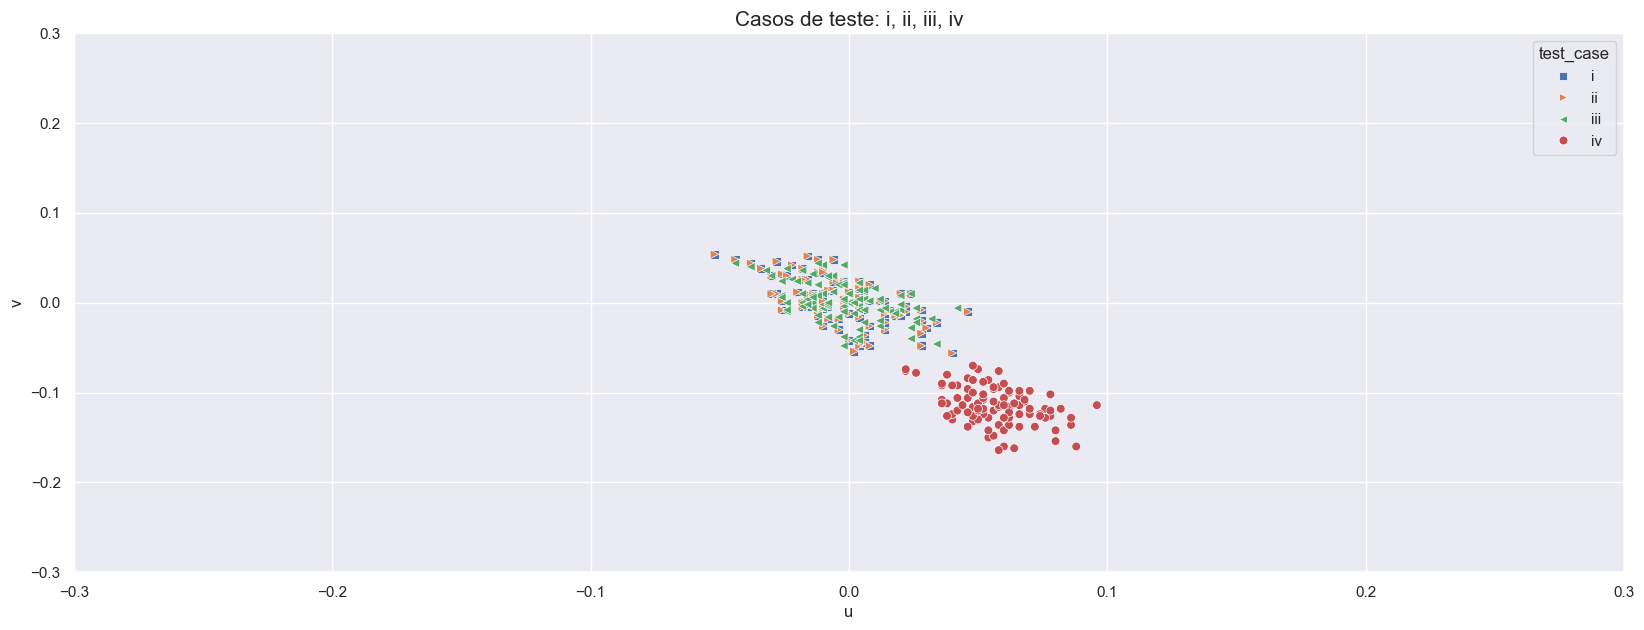

In [3]:
##########################################################
# ESPECIFICAÇÃO PERFEITA: CASOS DE TESTE i, ii, iii e iv #
##########################################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['i','ii','iii','iv']
)

,test_case,u_mean,v_mean,u_std,v_std
0,v,0.04152,-0.13310,0.017257,0.024724
1,vi,0.04152,-0.13310,0.017257,0.024724
2,vii,0.03166,-0.11332,0.015738,0.020969
3,viii,0.08916,-0.23340,0.014074,0.022139


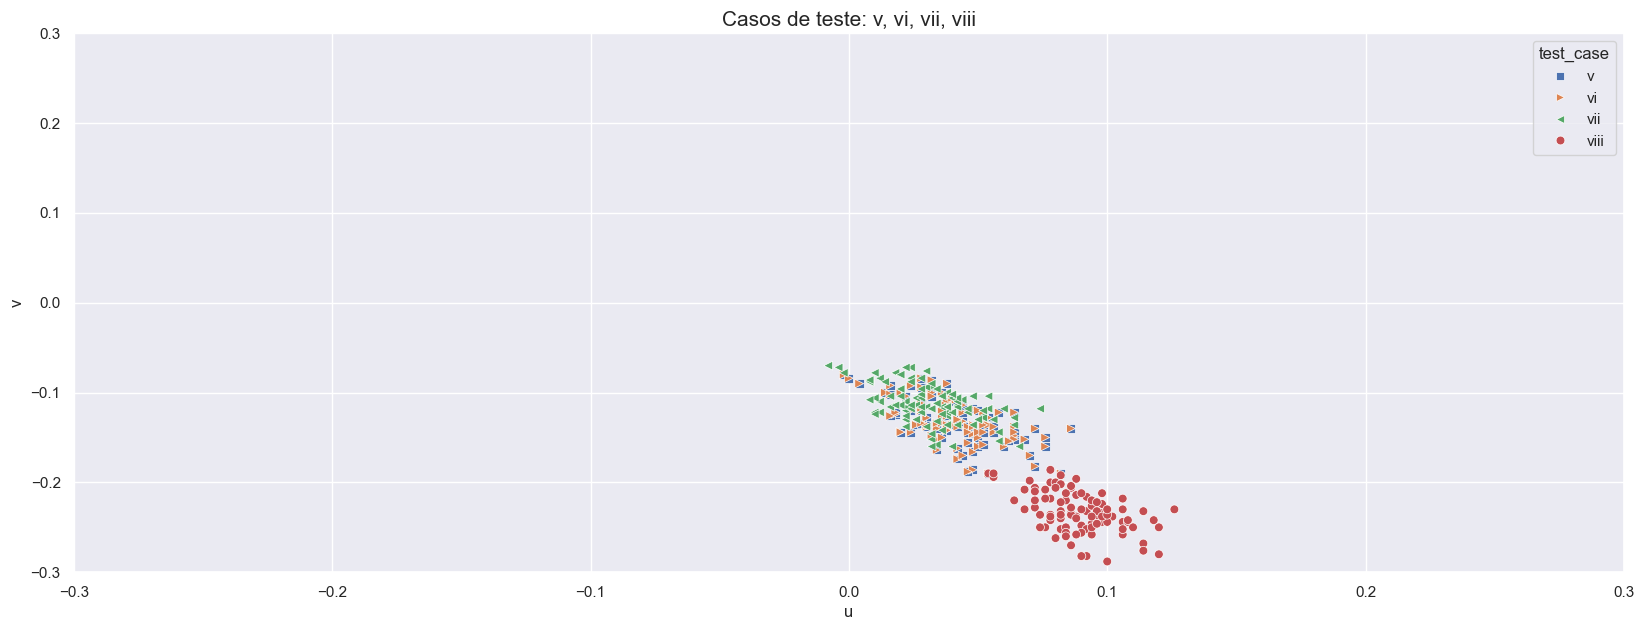

In [4]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['v','vi','vii','viii']
)

,test_case,u_mean,v_mean,u_std,v_std
0,ix,0.03758,0.298,0.010948,0.0
1,x,0.03758,0.298,0.010948,0.0
2,xi,0.03408,0.298,0.009794,0.0
3,xii,0.05810,0.298,0.010136,0.0


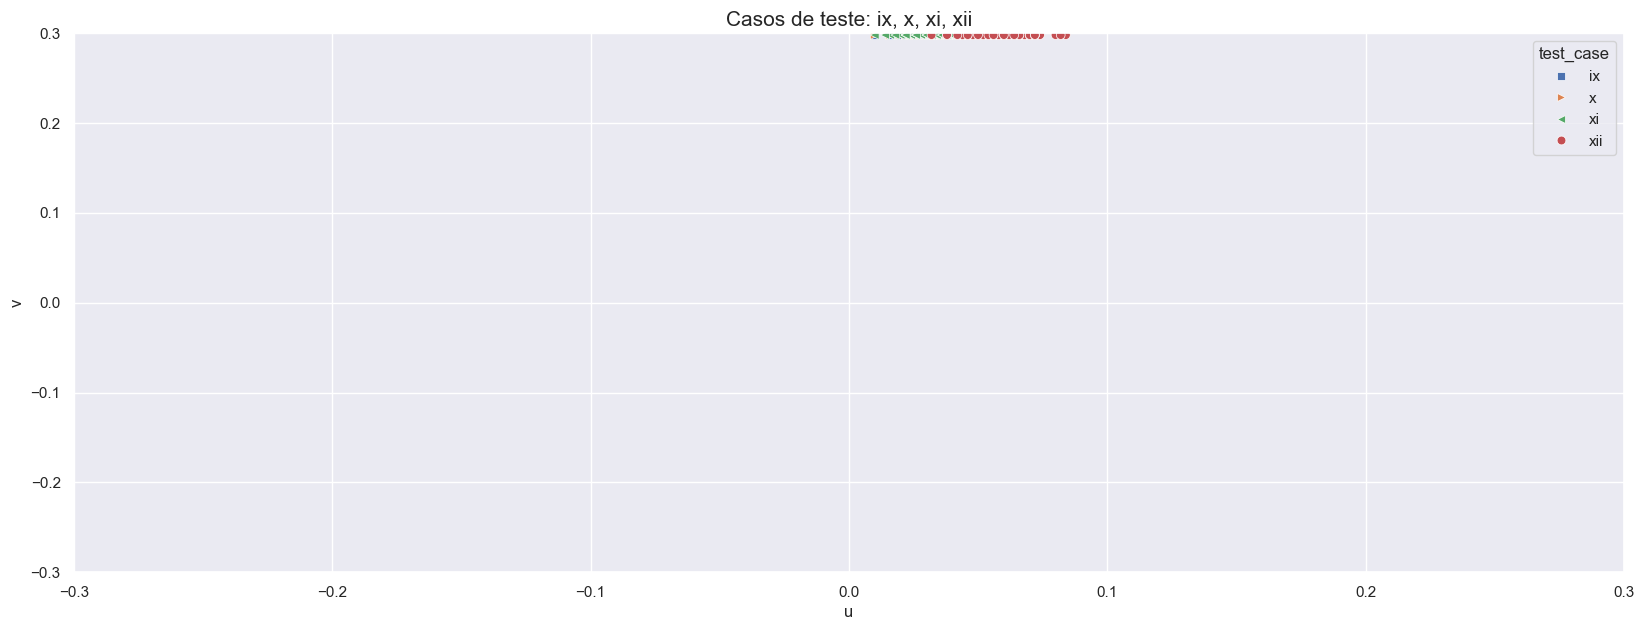

In [5]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['ix','x','xi','xii']
)

### Mesma prior

/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:1680: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


,test_case,u_mean,v_mean,u_std,v_std
0,i,-0.00248,0.0017,0.018280,0.024797
1,ix,0.03758,0.2980,0.010948,0.000000
2,v,0.04152,-0.1331,0.017257,0.024724


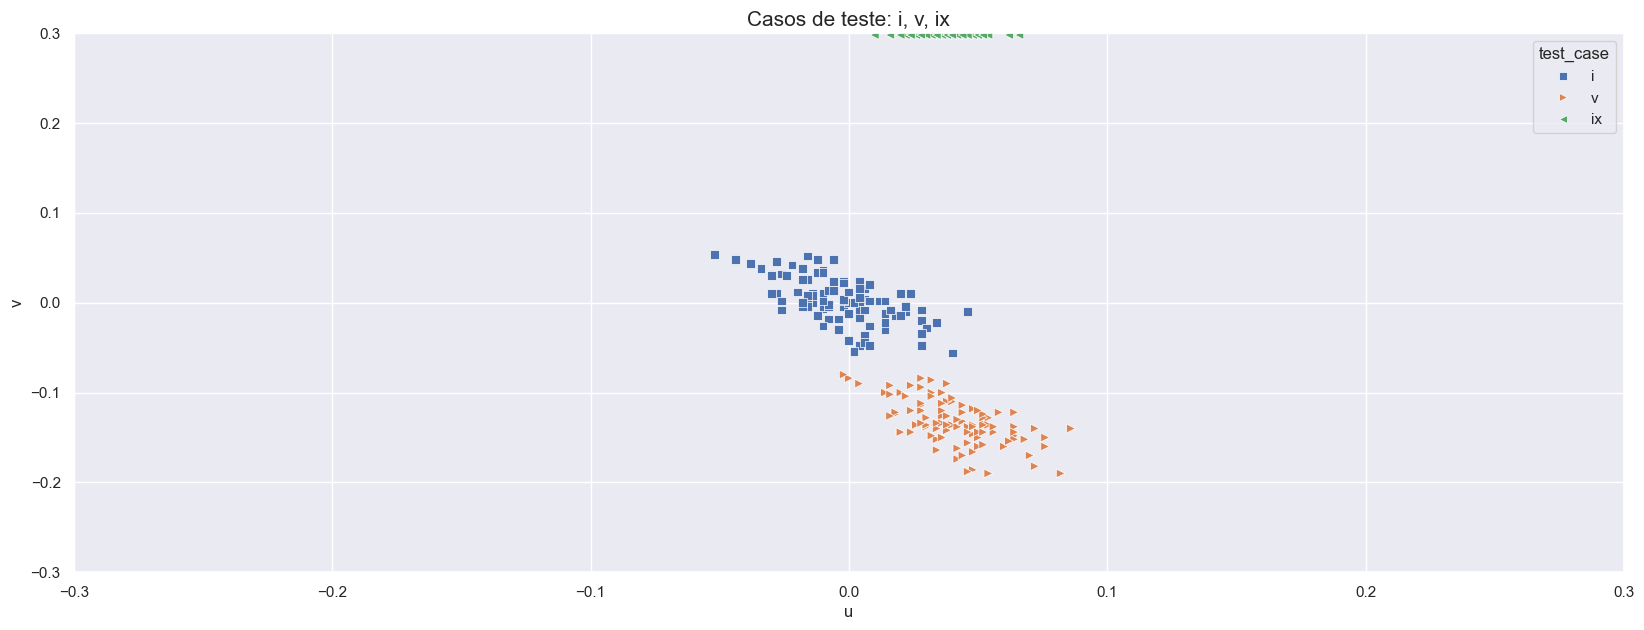

In [6]:
#############################################
# PRIOR UNIFORME: CASOS DE TESTE i, v, e ix #
#############################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['i','v','ix']
)

/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:1680: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


,test_case,u_mean,v_mean,u_std,v_std
0,ii,-0.00248,0.0017,0.018280,0.024797
1,vi,0.04152,-0.1331,0.017257,0.024724
2,x,0.03758,0.2980,0.010948,0.000000


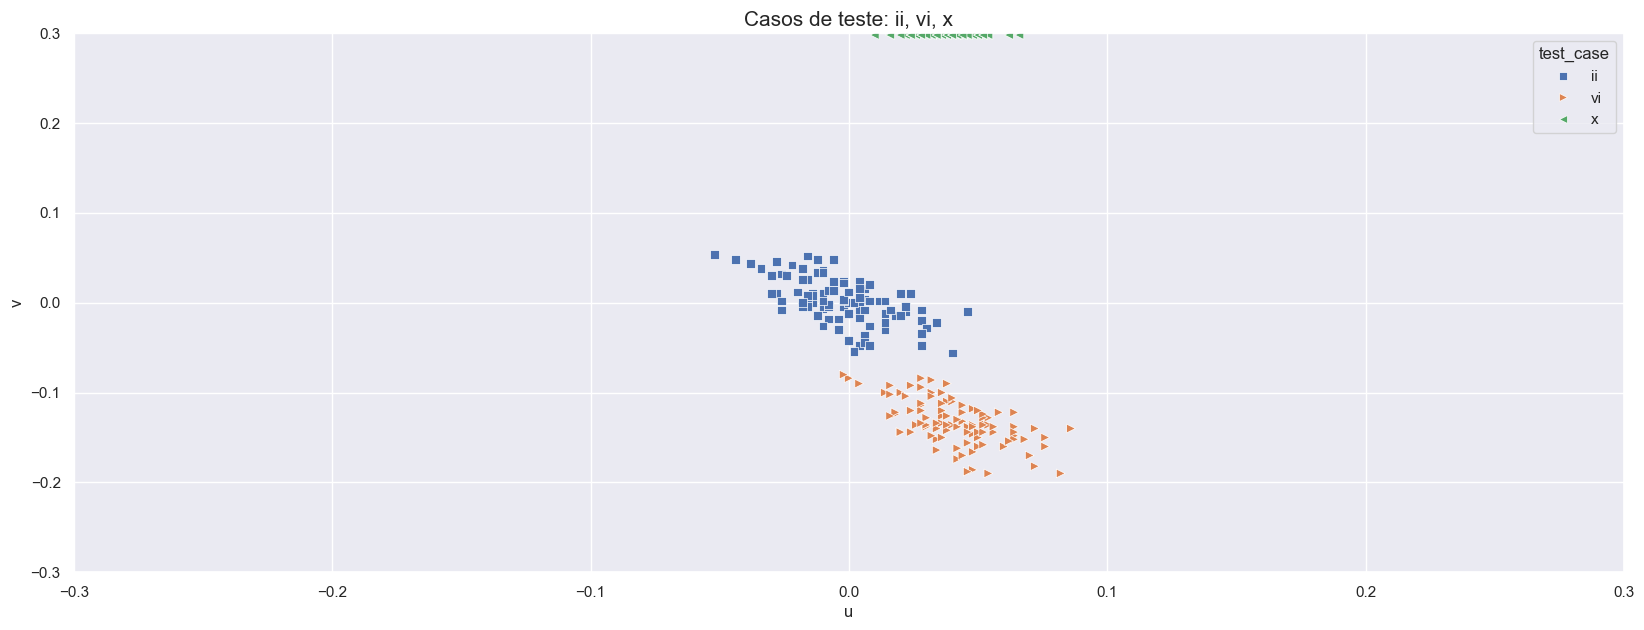

In [7]:
#################################################################
# PRIOR CORRETA E POUCO INFORMATIVA: CASOS DE TESTE ii, vi, e x #
#################################################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['ii','vi','x']
)

/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:1680: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


,test_case,u_mean,v_mean,u_std,v_std
0,iii,-0.00214,0.00126,0.016251,0.021033
1,vii,0.03166,-0.11332,0.015738,0.020969
2,xi,0.03408,0.29800,0.009794,0.000000


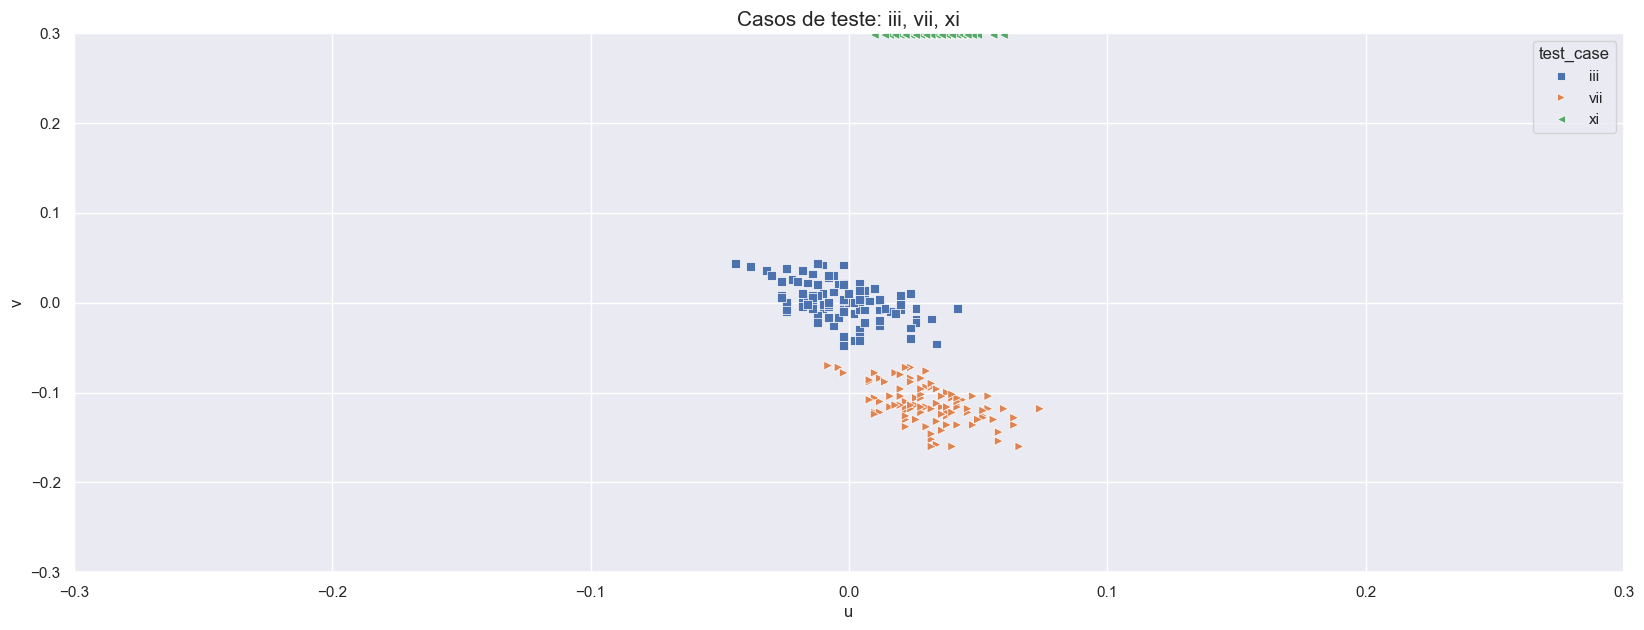

In [8]:
##############################################################
# PRIOR CORRETA E INFORMATIVA: CASOS DE TESTE iii, vii, e xi #
##############################################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['iii','vii','xi']
)

/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:1680: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


,test_case,u_mean,v_mean,u_std,v_std
0,iv,0.05684,-0.11456,0.014220,0.020687
1,viii,0.08916,-0.23340,0.014074,0.022139
2,xii,0.05810,0.29800,0.010136,0.000000


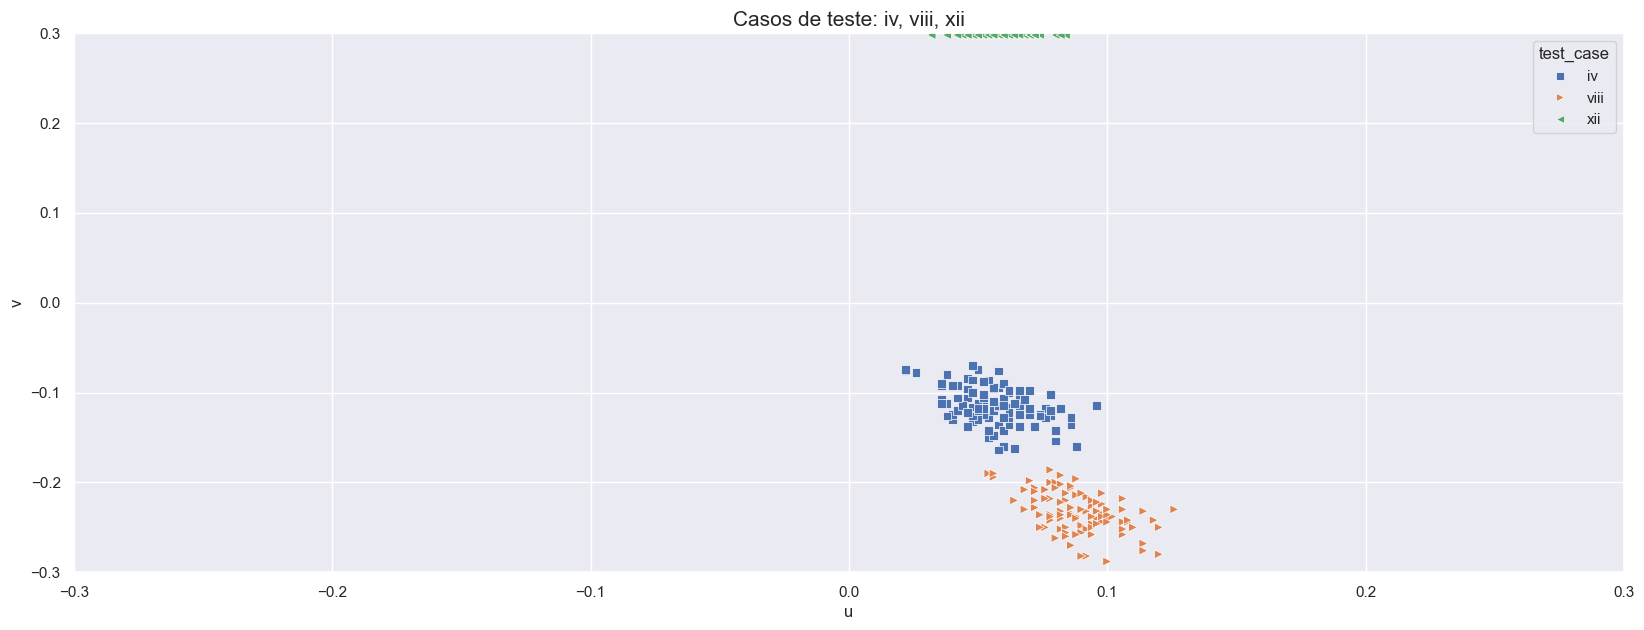

In [9]:
#################################################################
# PRIOR INCORRETA E INFORMATIVA: CASOS DE TESTE iv, viii, e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['iv','viii','xii']
)

## 2.2. Coeficientes MMSE estimados

### Mesmo modelo

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,i,0.491791,-1.009606,0.501647,0.982424,0.047944,0.089179,0.044995,0.086515
1,ii,0.494842,-1.007001,0.499937,0.989557,0.044979,0.083010,0.043111,0.080261
2,iii,0.501093,-1.000845,0.497631,1.001513,0.025972,0.037306,0.024214,0.034919
3,iv,0.692541,0.055533,-0.030543,1.325872,0.018673,0.213434,0.112244,0.032725


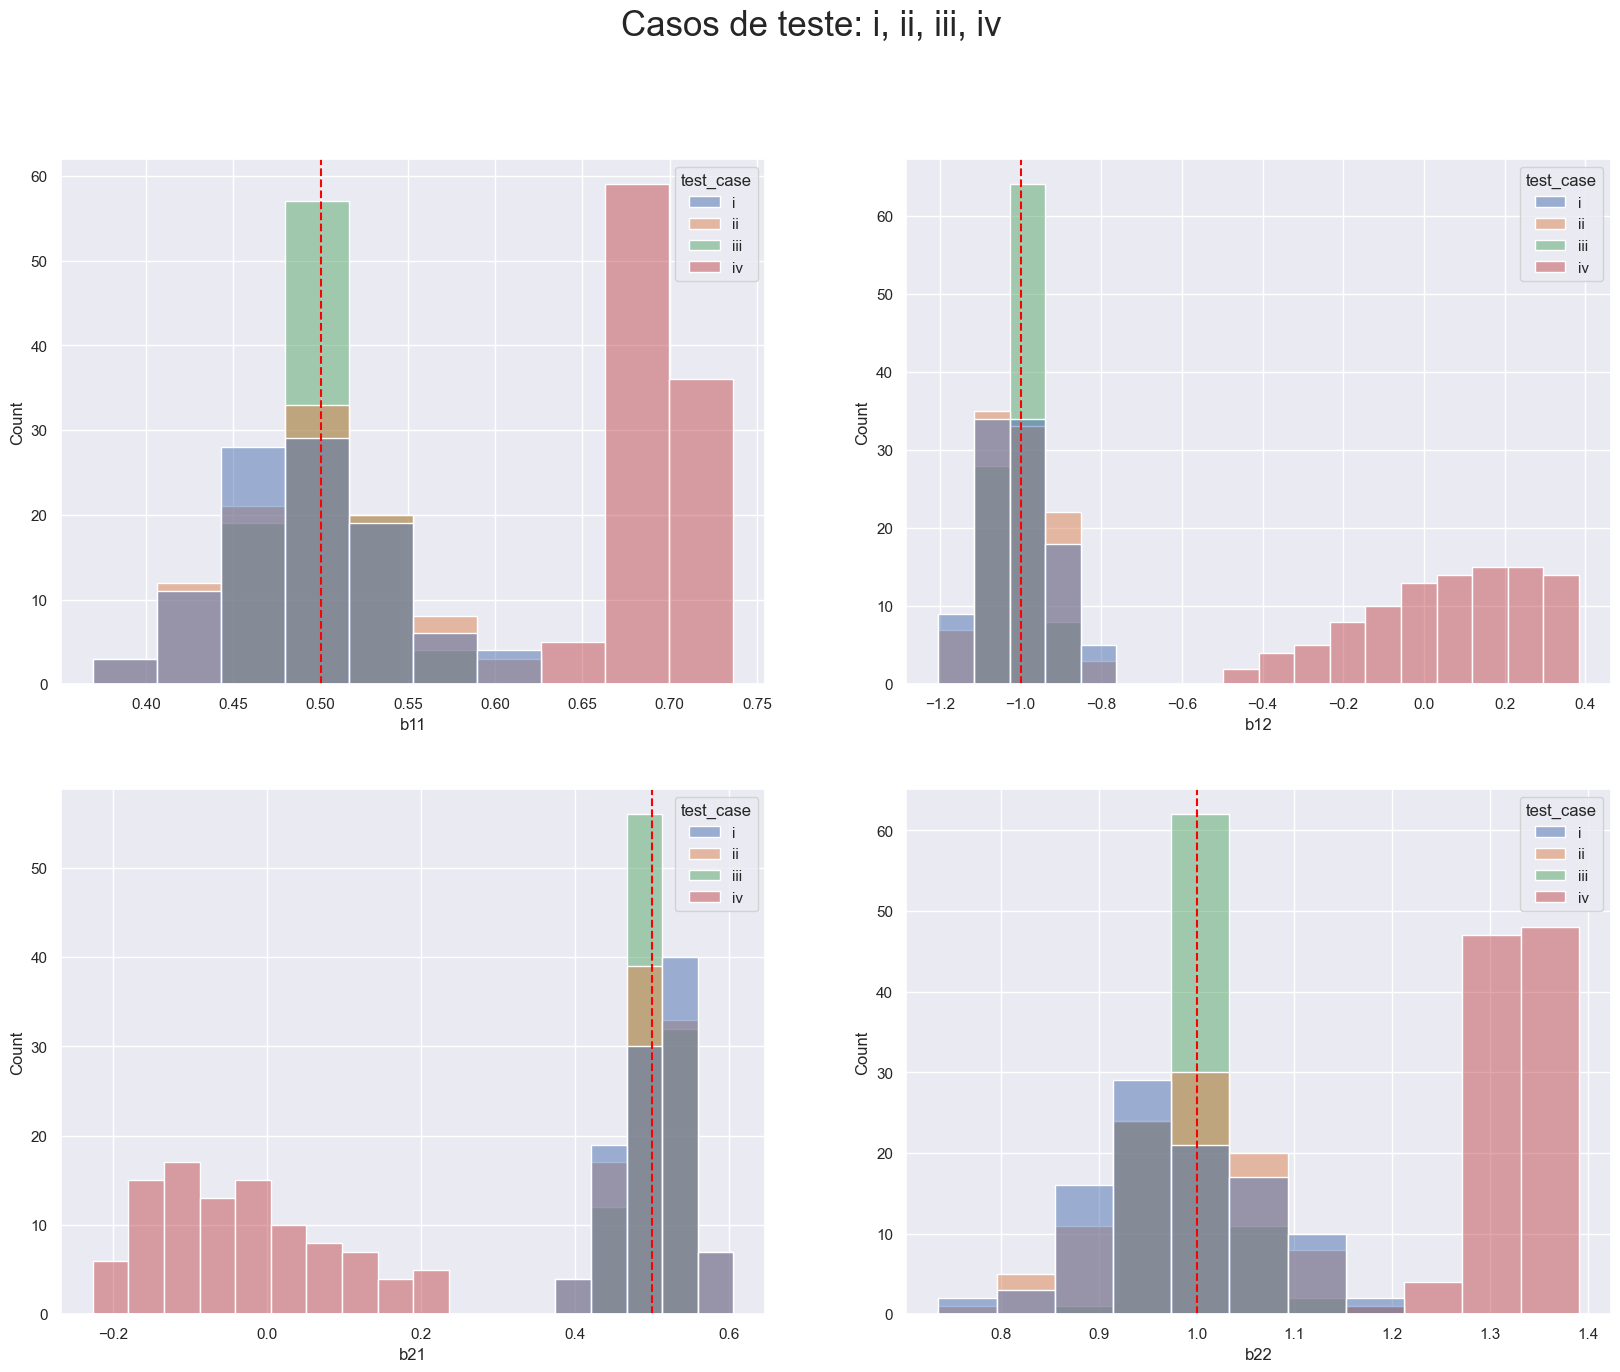

In [10]:
##########################################################
# ESPECIFICAÇÃO PERFEITA: CASOS DE TESTE i, ii, iii e iv #
##########################################################

EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['i','ii','iii','iv'],
    B_true=parser.execution_config['general']['B']
)

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,v,0.449613,-0.913936,0.452445,0.900180,0.040039,0.071928,0.037805,0.070150
1,vi,0.443435,-0.927466,0.458704,0.887277,0.042608,0.075685,0.037759,0.076931
2,vii,0.454345,-0.921060,0.454403,0.915060,0.025356,0.037481,0.023300,0.035235
3,viii,0.625980,0.026069,-0.014981,1.215810,0.018009,0.249521,0.127920,0.034648


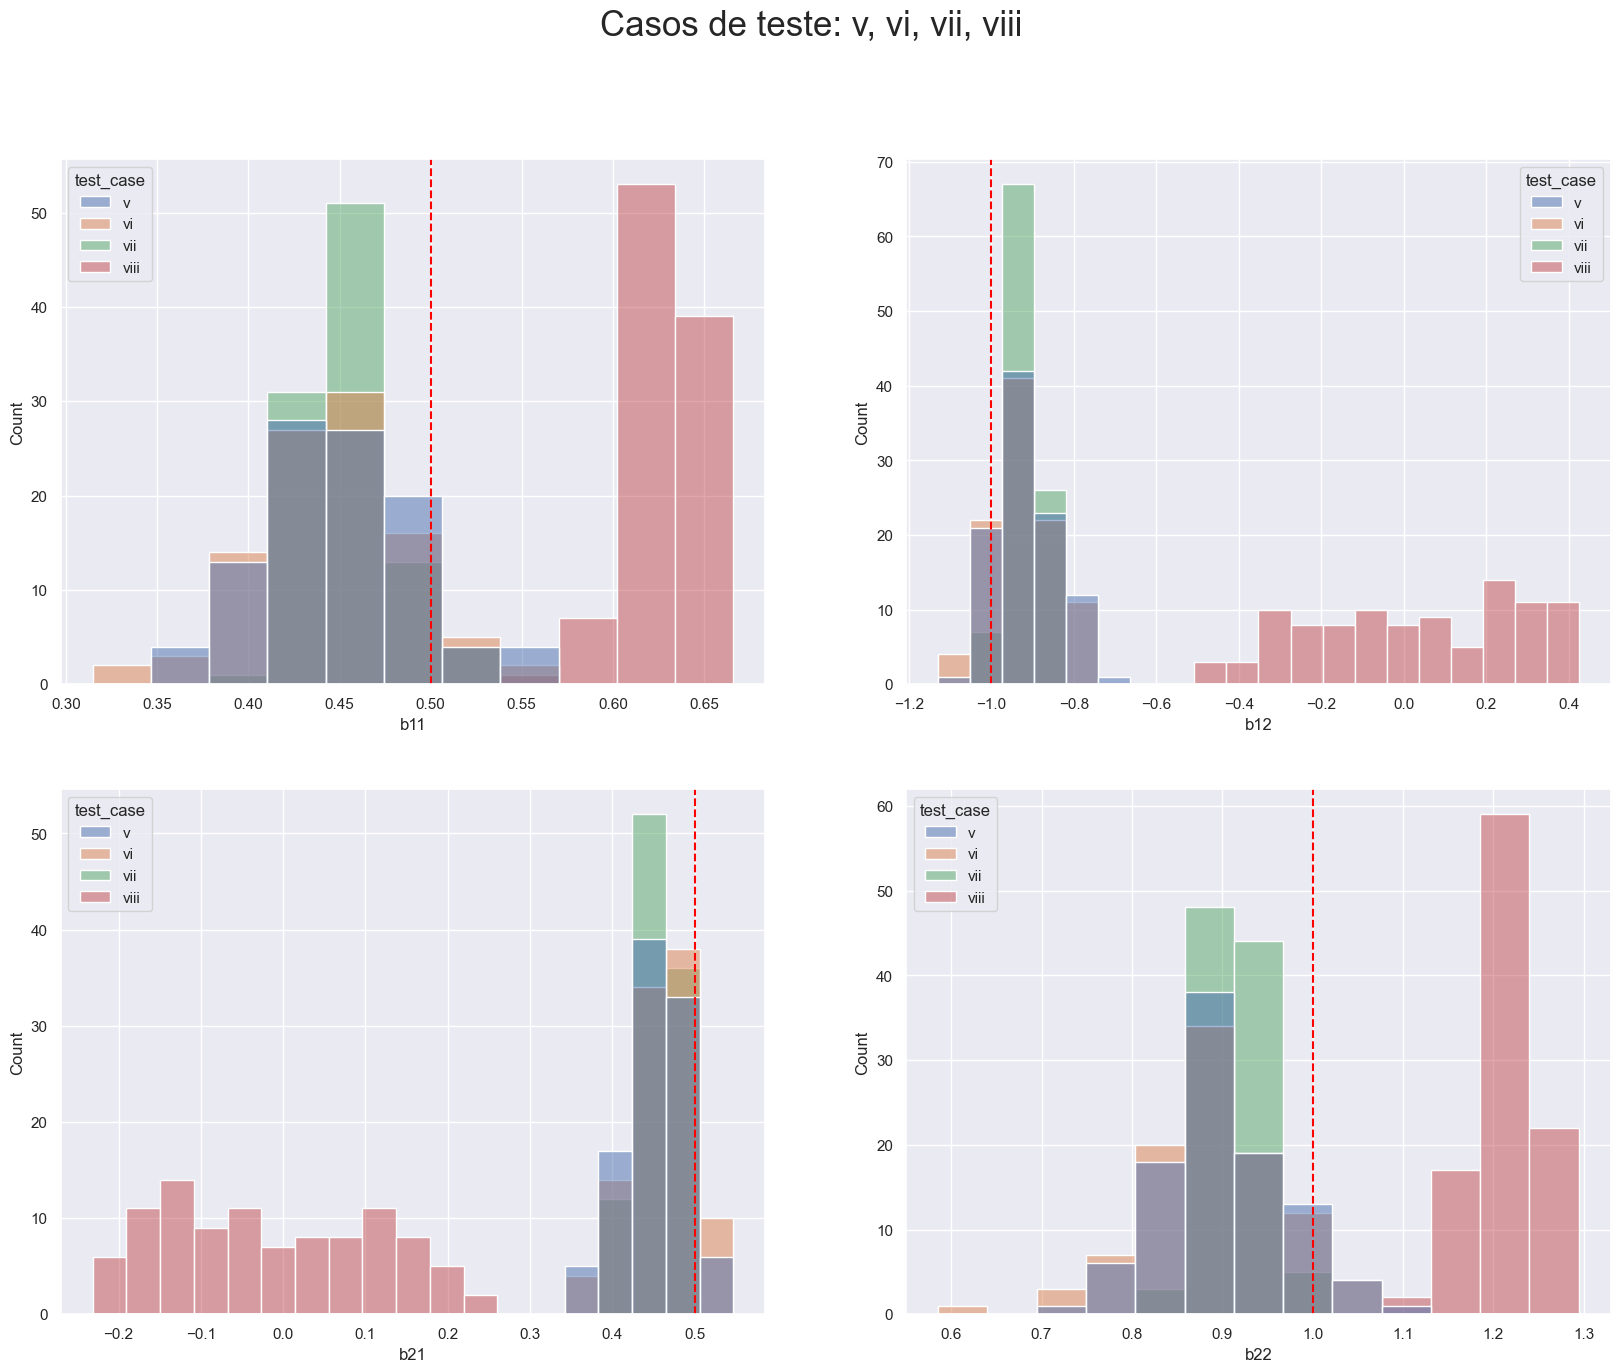

In [11]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['v','vi','vii','viii'],
    B_true=parser.execution_config['general']['B']
)

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,ix,1.384078,-0.366108,0.176340,2.772724,0.333839,0.855569,0.417404,0.658295
1,x,1.337239,-0.510572,0.244922,2.680914,0.395611,0.968308,0.476256,0.779883
2,xi,0.966618,-1.750728,0.965744,1.743563,0.040945,0.049984,0.038670,0.048761
3,xii,1.430995,-0.009797,0.001316,2.346835,0.024841,0.043796,0.024673,0.027180


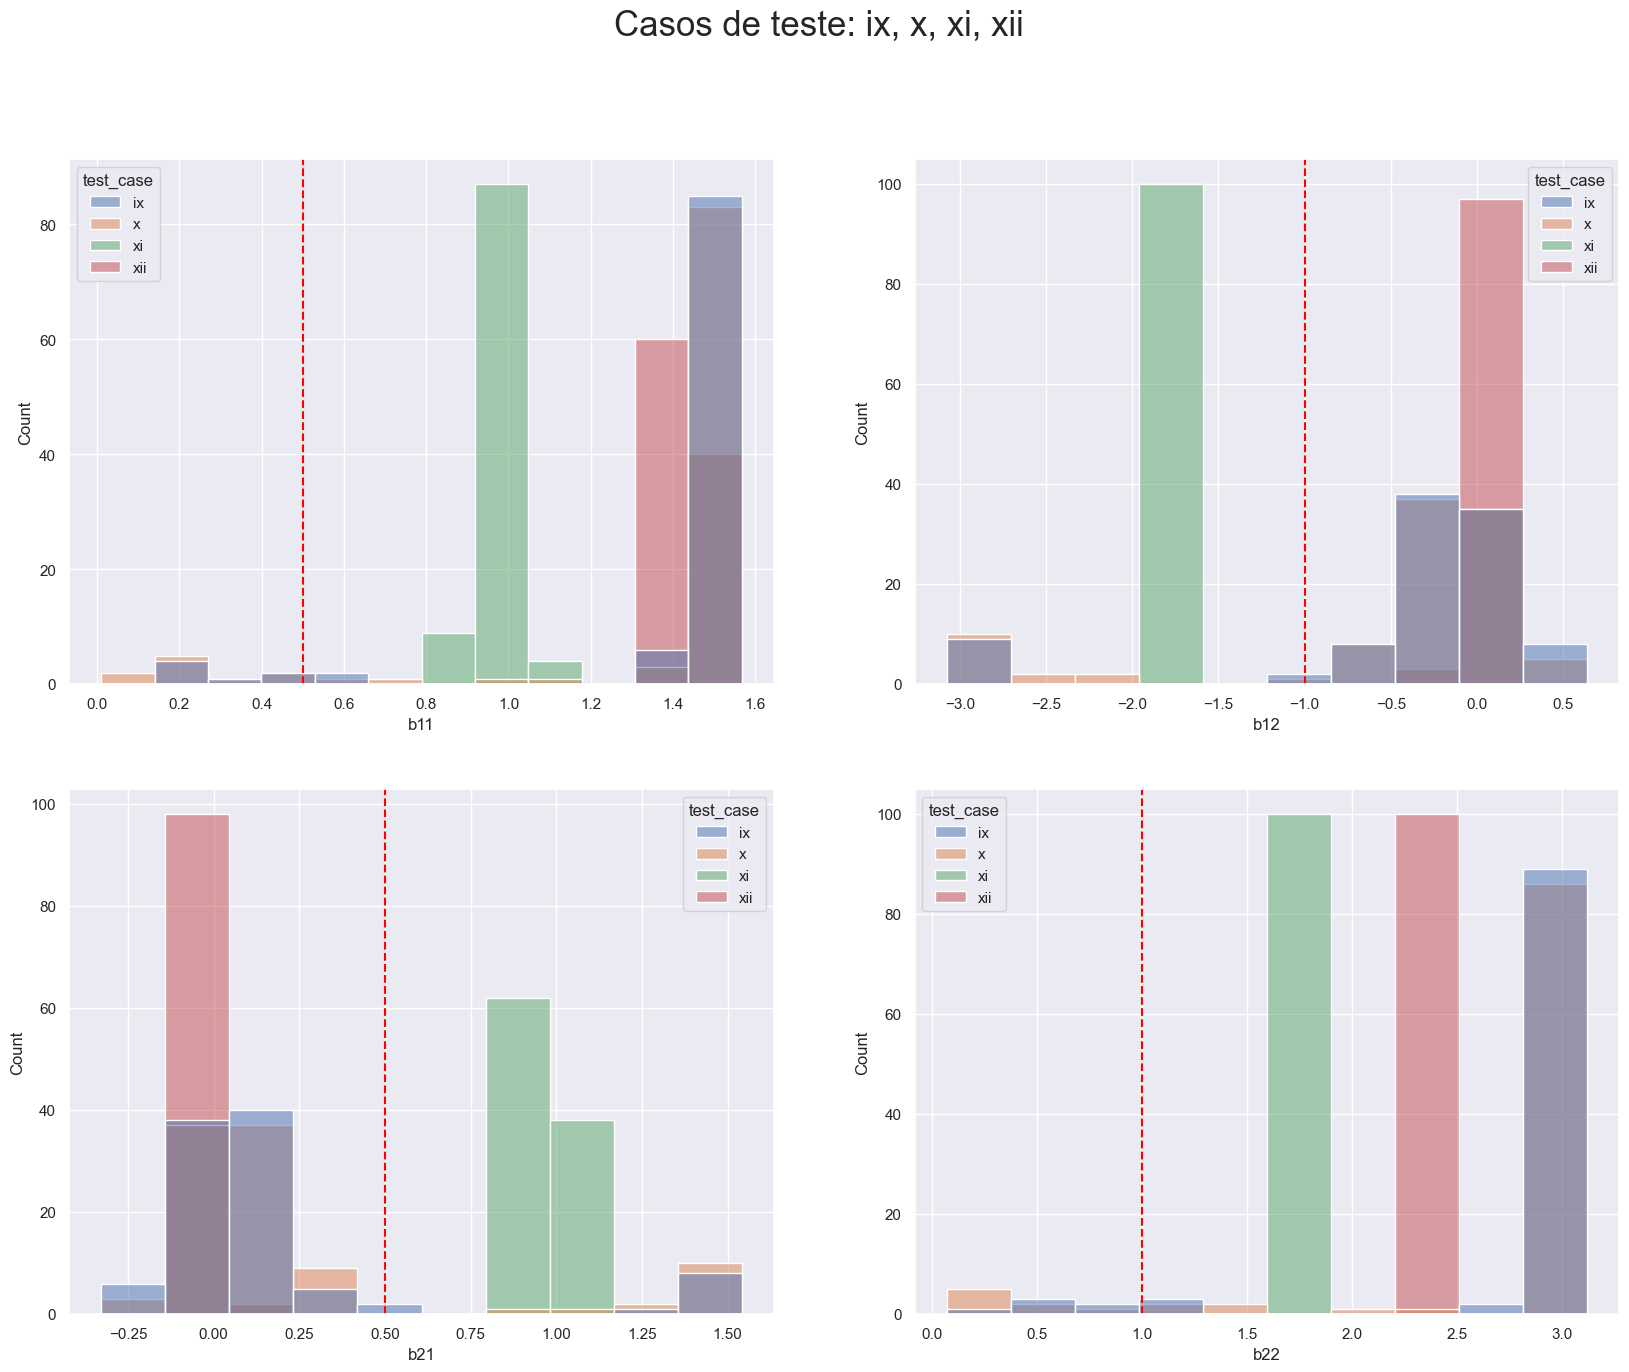

In [12]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['ix','x','xi','xii'],
    B_true=parser.execution_config['general']['B']
)

### Mesma prior

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,i,0.491791,-1.009606,0.501647,0.982424,0.047944,0.089179,0.044995,0.086515
1,ix,1.384078,-0.366108,0.176340,2.772724,0.333839,0.855569,0.417404,0.658295
2,v,0.449613,-0.913936,0.452445,0.900180,0.040039,0.071928,0.037805,0.070150


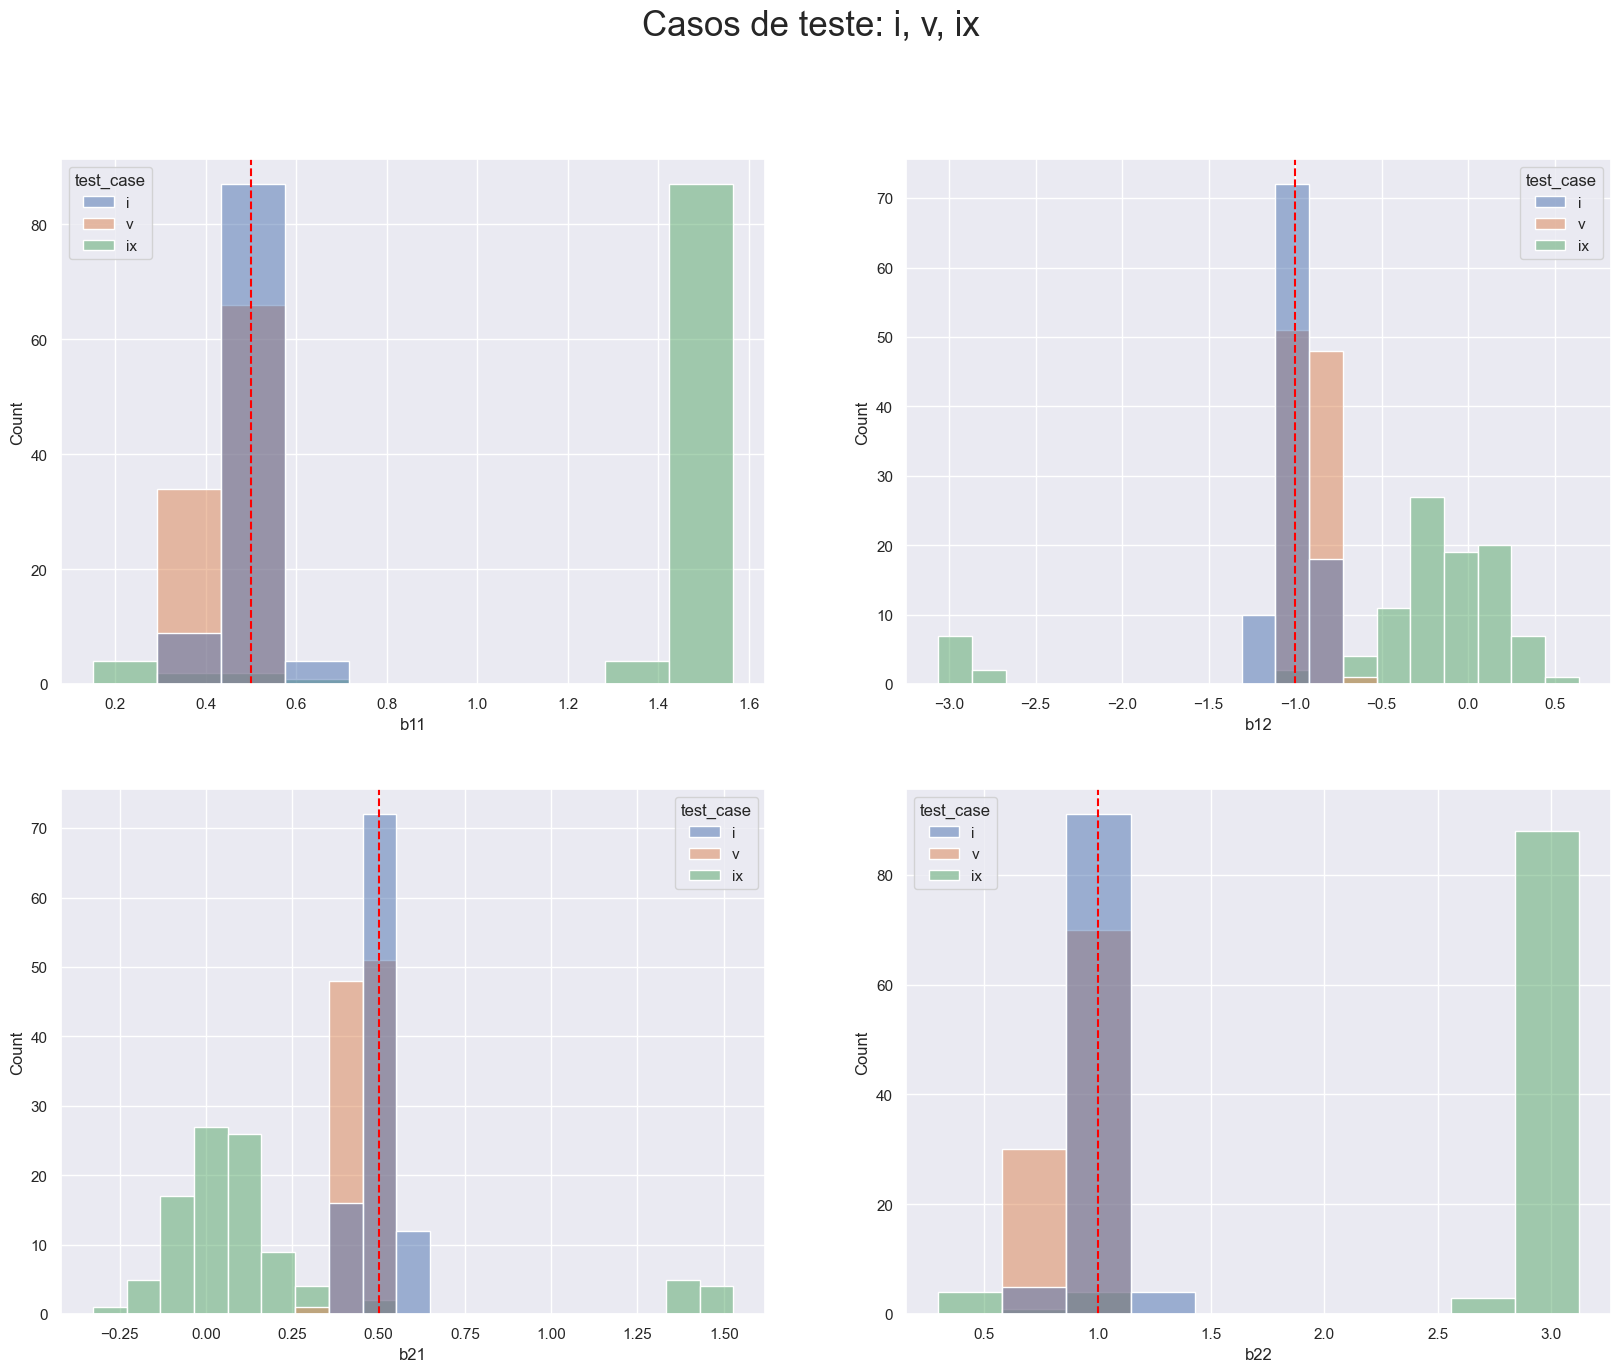

In [13]:
#############################################
# PRIOR UNIFORME: CASOS DE TESTE i, v, e ix #
#############################################

EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['i','v','ix'],
    B_true=parser.execution_config['general']['B']
)

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,ii,0.494842,-1.007001,0.499937,0.989557,0.044979,0.083010,0.043111,0.080261
1,vi,0.443435,-0.927466,0.458704,0.887277,0.042608,0.075685,0.037759,0.076931
2,x,1.337239,-0.510572,0.244922,2.680914,0.395611,0.968308,0.476256,0.779883


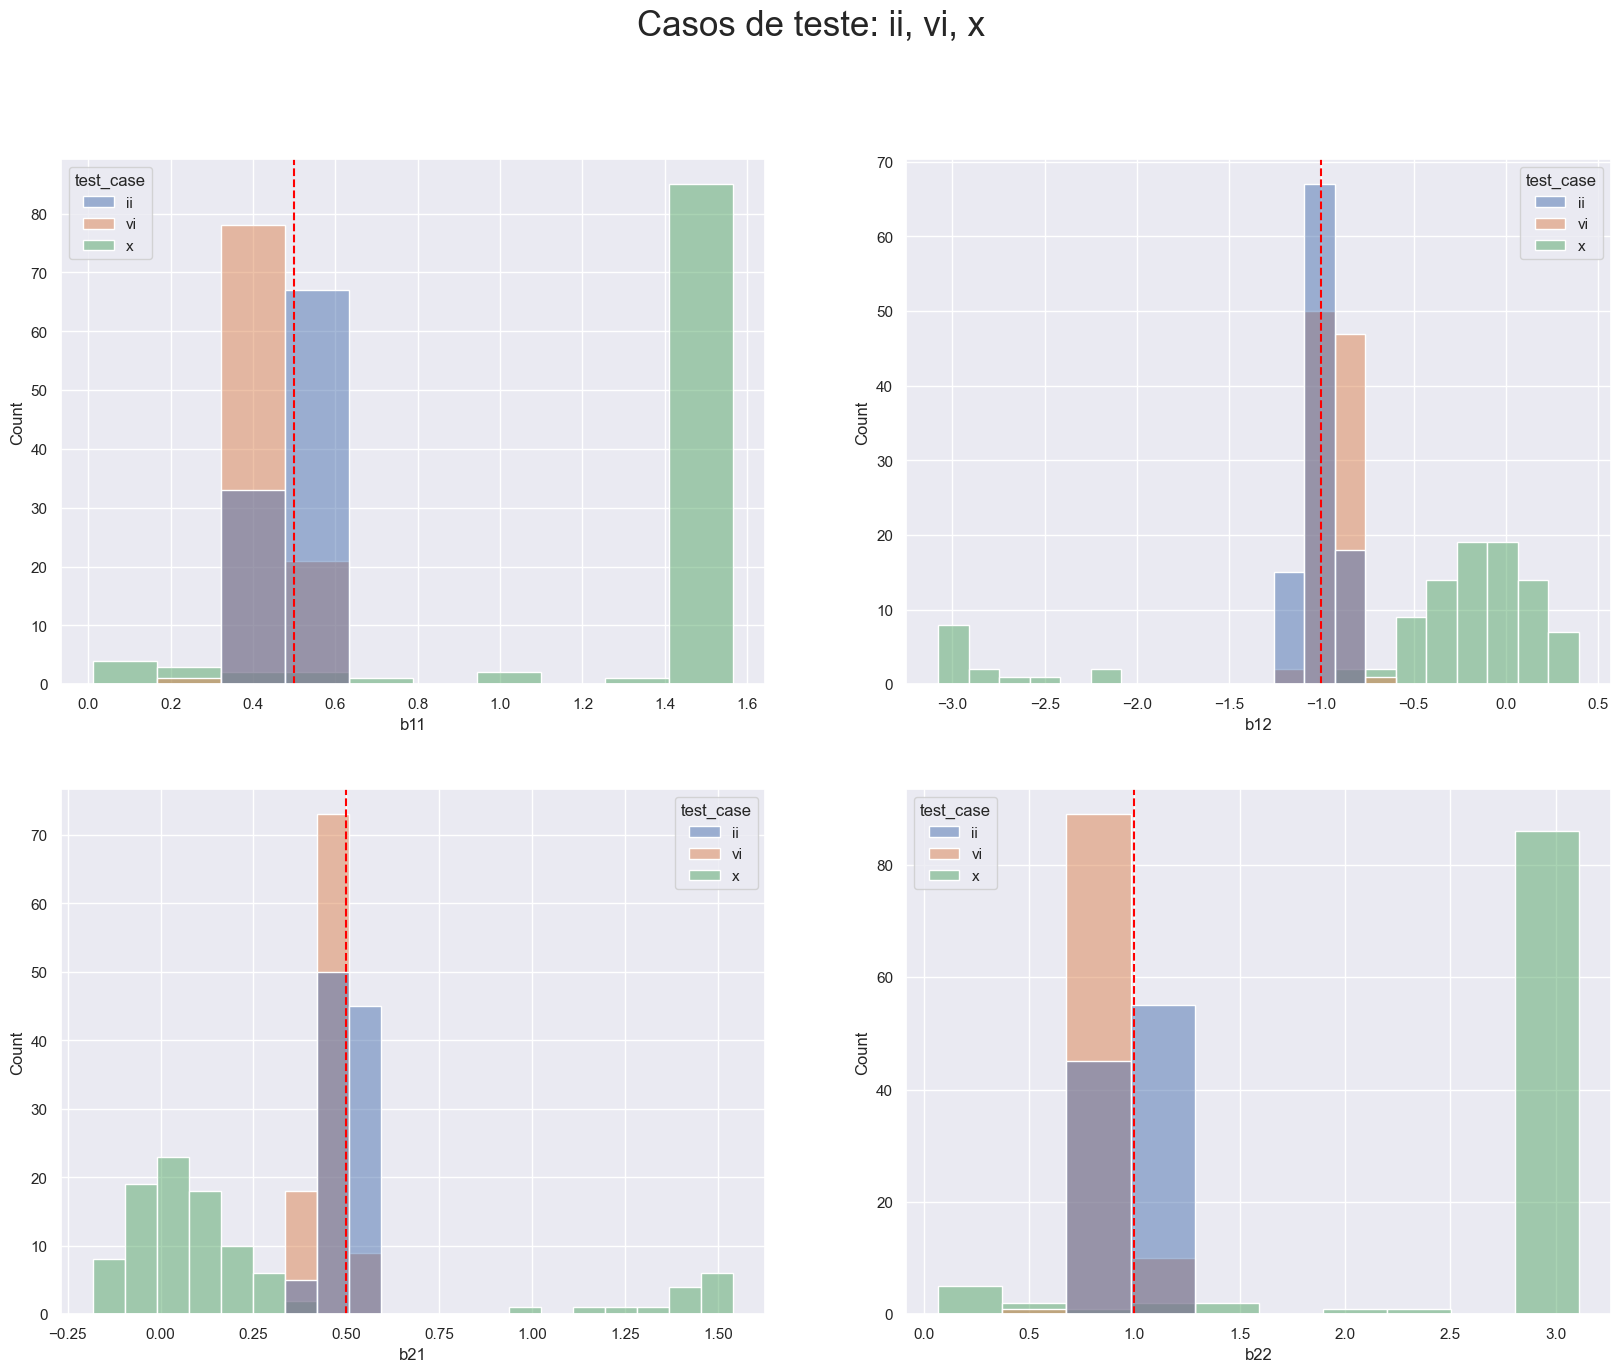

In [14]:
#################################################################
# PRIOR CORRETA E POUCO INFORMATIVA: CASOS DE TESTE ii, vi, e x #
#################################################################
EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['ii','vi','x'],
    B_true=parser.execution_config['general']['B']
)

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,iii,0.501093,-1.000845,0.497631,1.001513,0.025972,0.037306,0.024214,0.034919
1,vii,0.454345,-0.921060,0.454403,0.915060,0.025356,0.037481,0.023300,0.035235
2,xi,0.966618,-1.750728,0.965744,1.743563,0.040945,0.049984,0.038670,0.048761


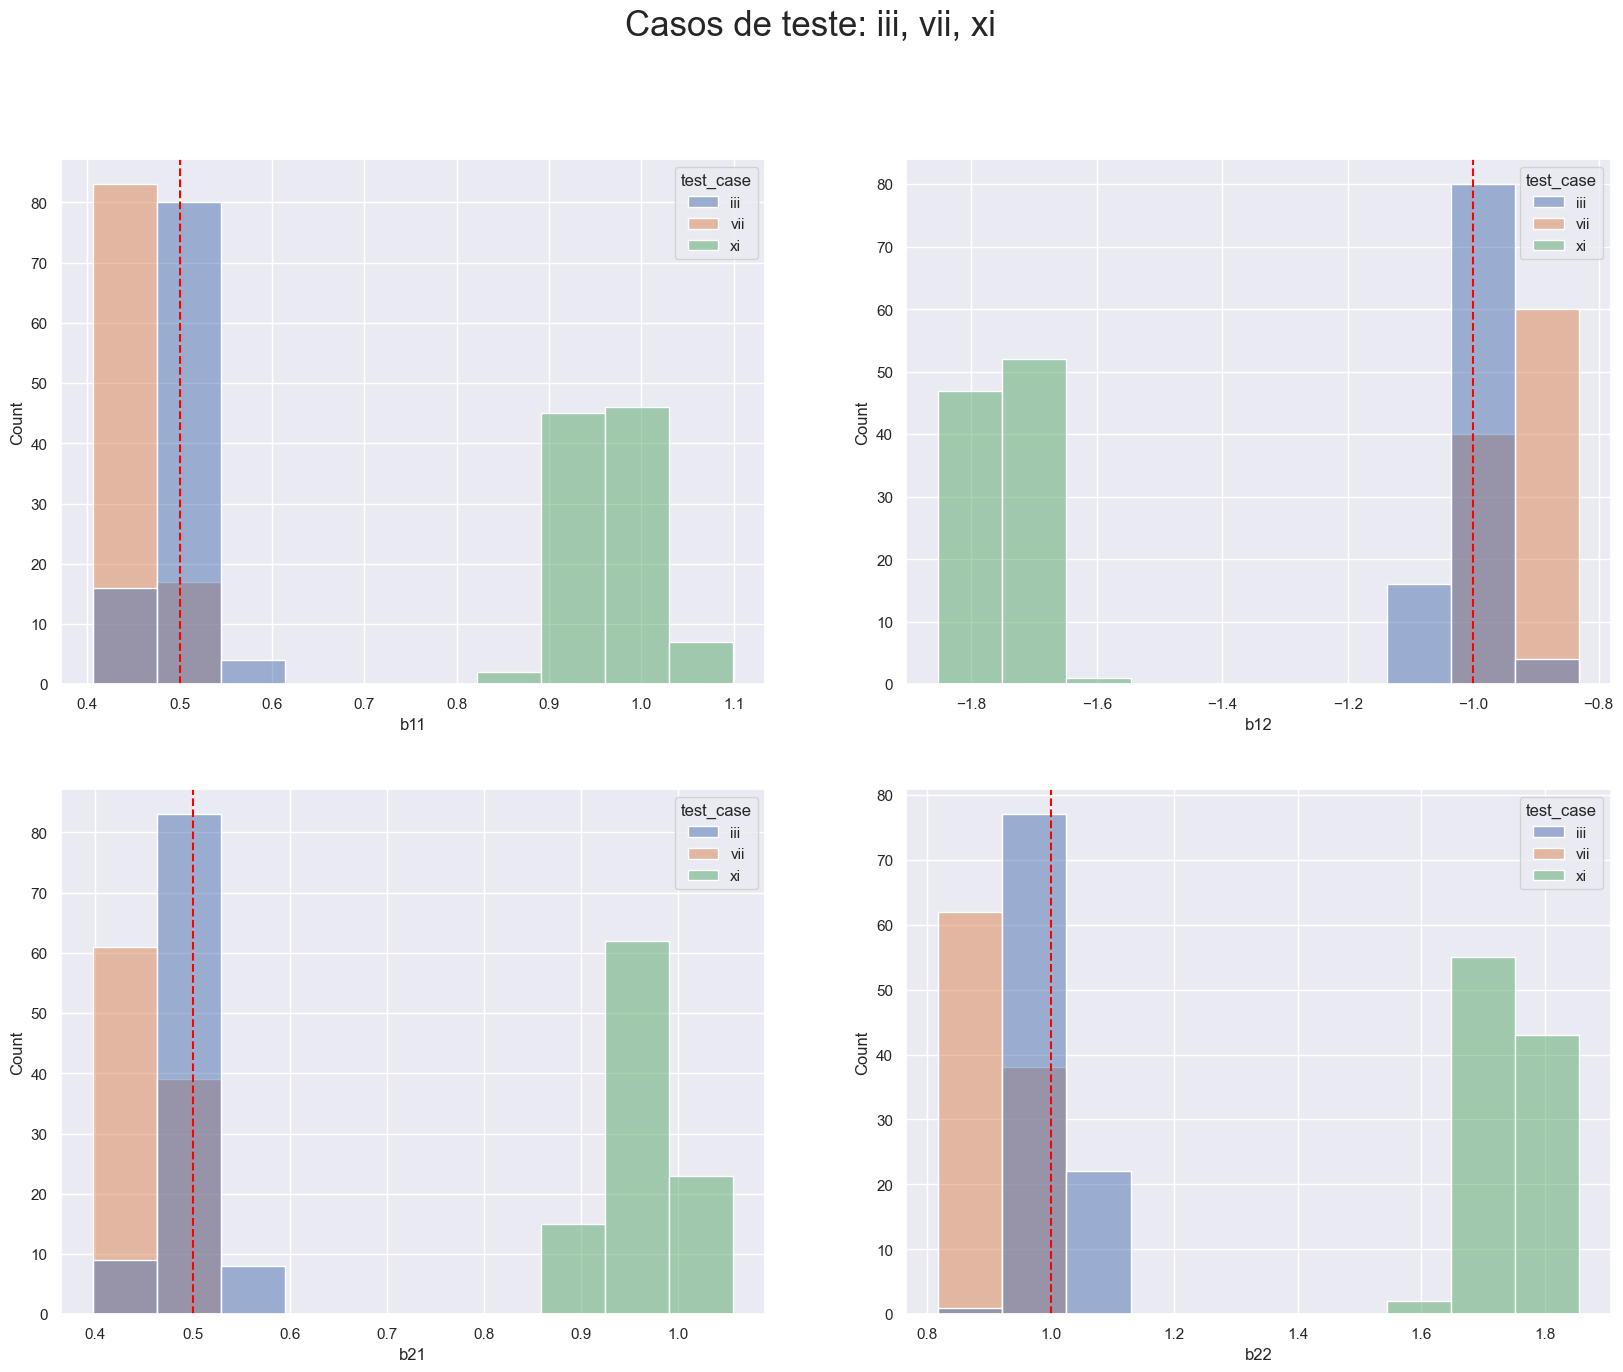

In [15]:
##############################################################
# PRIOR CORRETA E INFORMATIVA: CASOS DE TESTE iii, vii, e xi #
##############################################################
EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['iii','vii','xi'],
    B_true=parser.execution_config['general']['B']
)

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,iv,0.692541,0.055533,-0.030543,1.325872,0.018673,0.213434,0.112244,0.032725
1,viii,0.625980,0.026069,-0.014981,1.215810,0.018009,0.249521,0.127920,0.034648
2,xii,1.430995,-0.009797,0.001316,2.346835,0.024841,0.043796,0.024673,0.027180


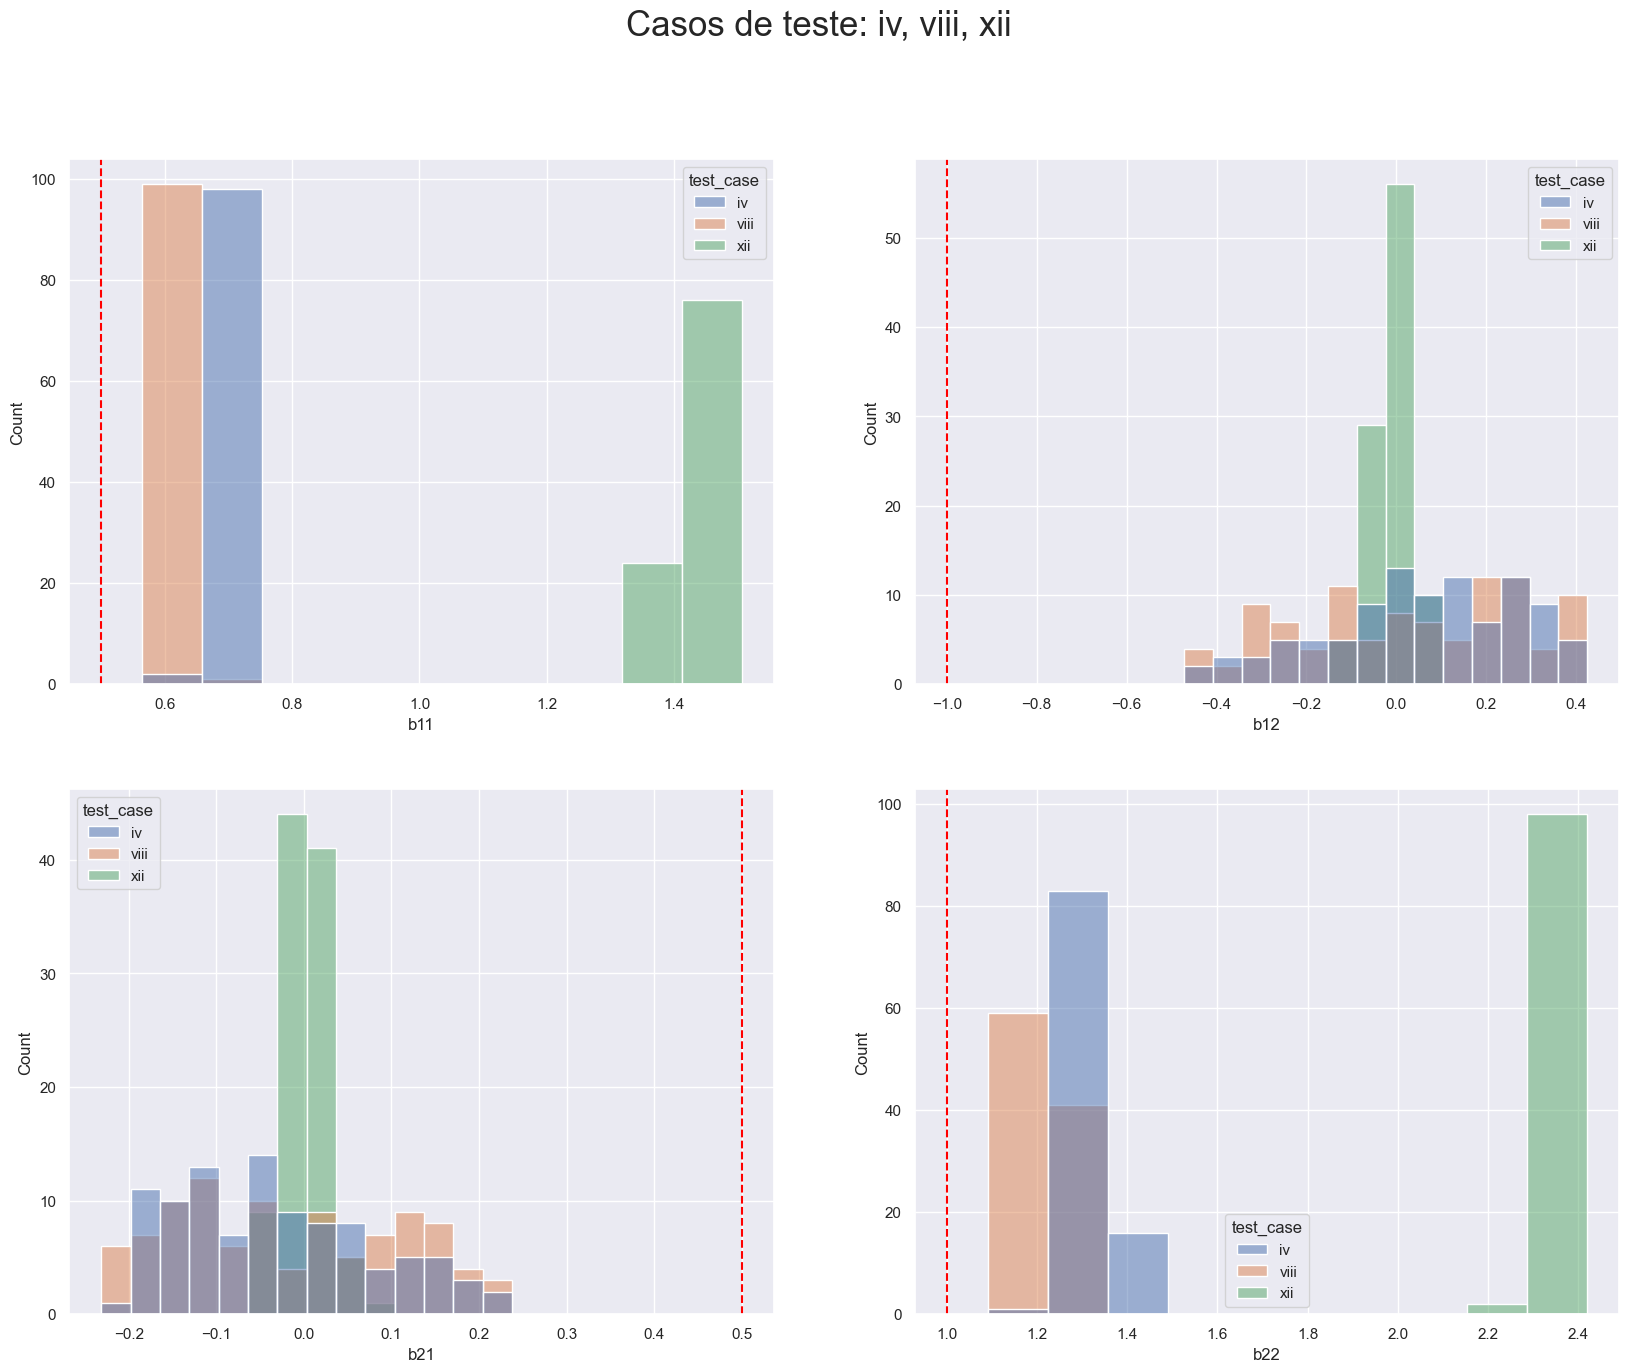

In [16]:
#################################################################
# PRIOR INCORRETA E INFORMATIVA: CASOS DE TESTE iv, viii, e xii #
#################################################################
EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['iv','viii','xii'],
    B_true=parser.execution_config['general']['B']
)

## 2.3. Erros MMSE

### Mesmo modelo

,test_case,errors_mean,errors_min,errors_max,errors_std
0,i,0.077180,0.008501,0.227559,0.045584
1,ii,0.071106,0.009157,0.227639,0.043048
2,iii,0.035579,0.002515,0.083405,0.016556
3,iv,0.786455,0.425711,1.004651,0.144375


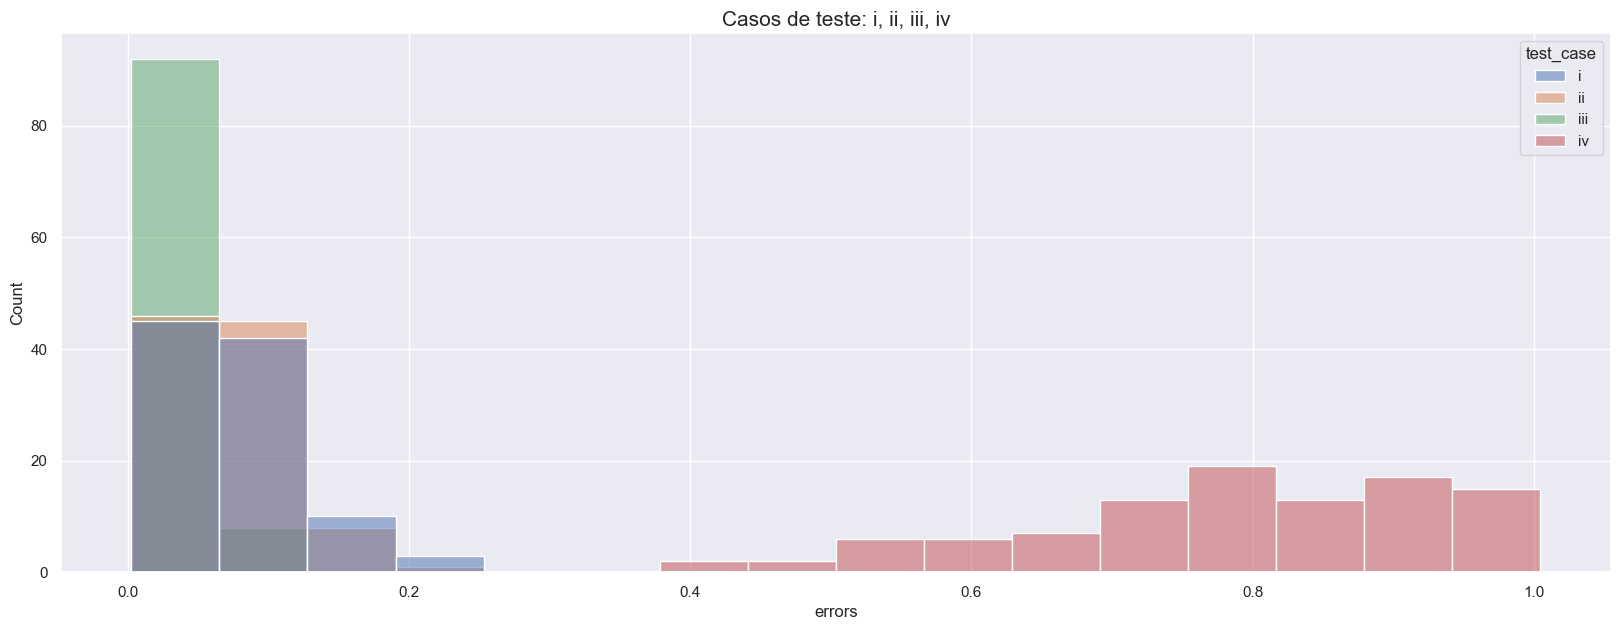

In [17]:
##########################################################
# ESPECIFICAÇÃO PERFEITA: CASOS DE TESTE i, ii, iii e iv #
##########################################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['i','ii','iii','iv']
)

,test_case,errors_mean,errors_min,errors_max,errors_std
0,v,0.115498,0.064937,0.216387,0.027099
1,vi,0.117618,0.061897,0.299905,0.034969
2,vii,0.091200,0.052400,0.136153,0.015697
3,viii,0.744462,0.382223,1.019005,0.173212


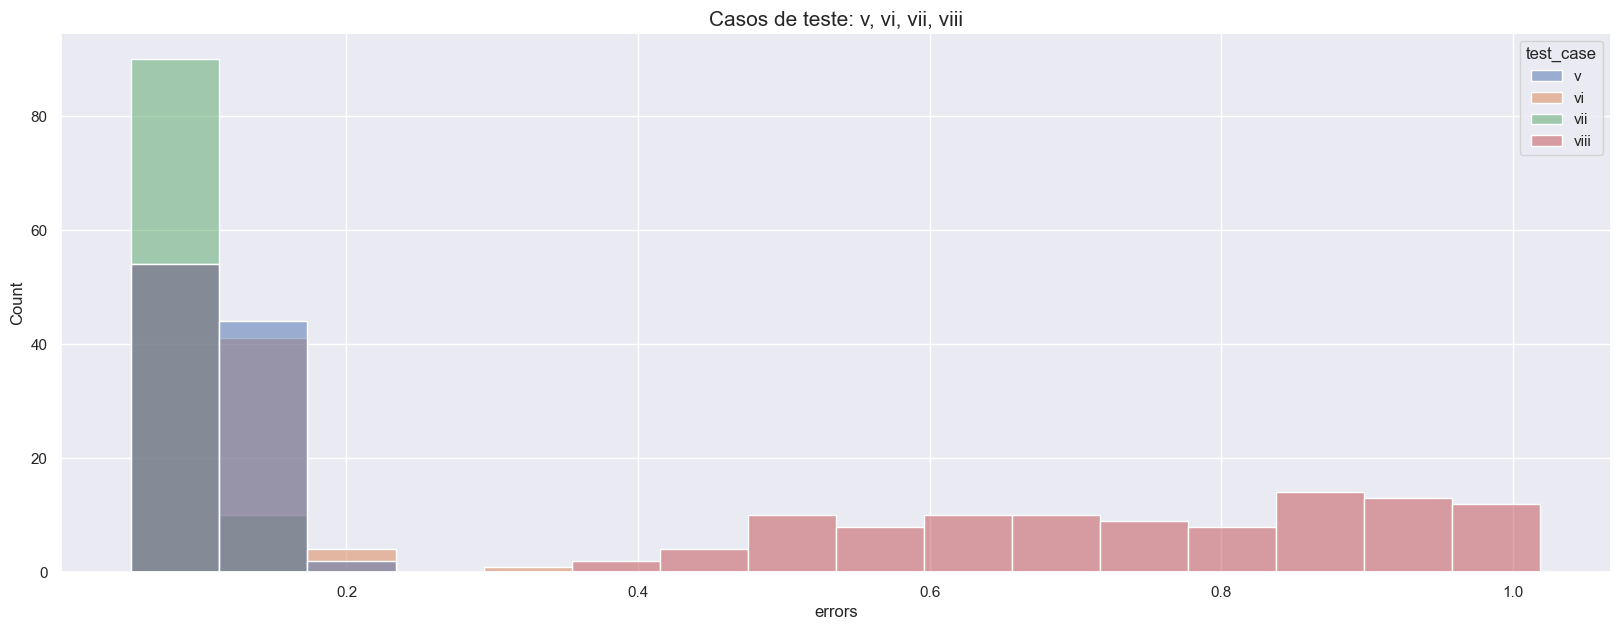

In [18]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['v','vi','vii','viii']
)

,test_case,errors_mean,errors_min,errors_max,errors_std
0,ix,1.528380,1.227921,1.780754,0.105157
1,x,1.510637,1.070285,1.744122,0.120363
2,xi,0.789522,0.747466,0.840210,0.017221
3,xii,1.251020,1.196930,1.300215,0.021271


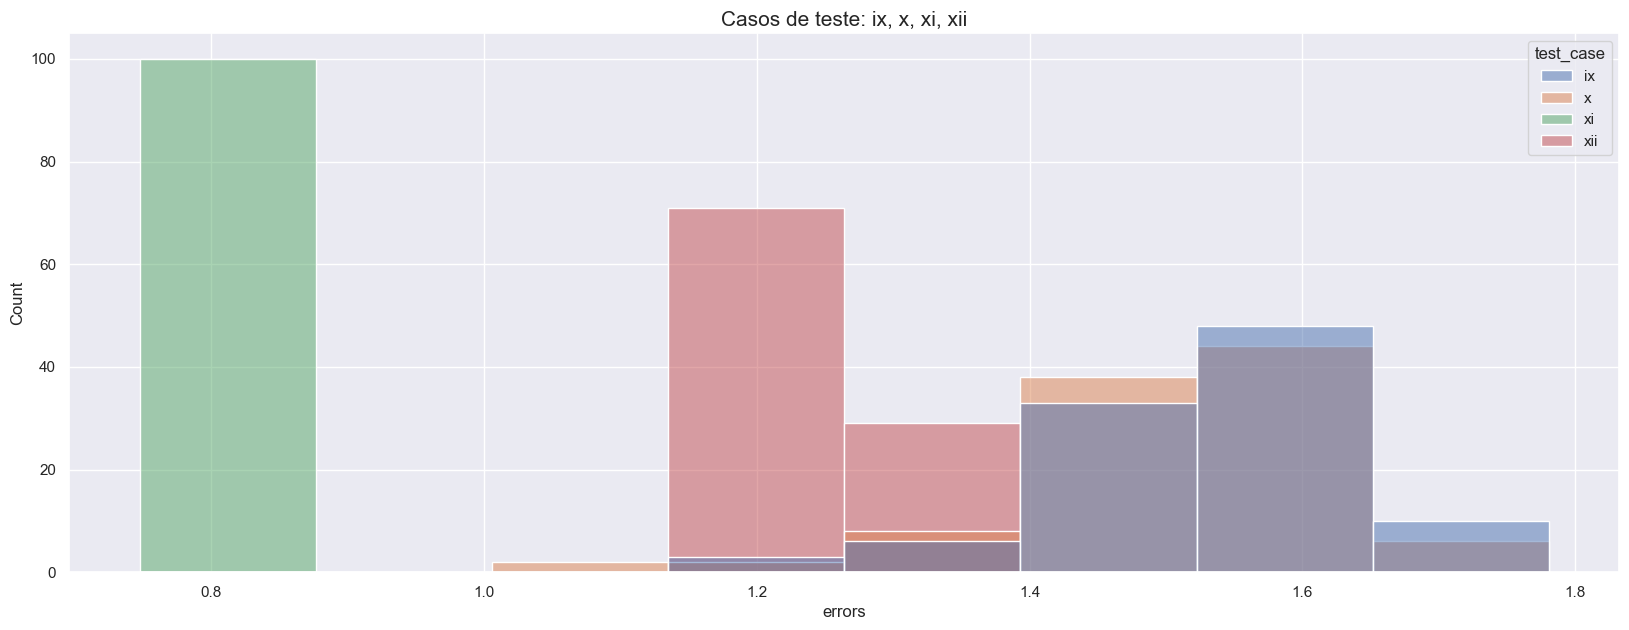

In [19]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['ix','x','xi','xii']
)

### Mesma prior

,test_case,errors_mean,errors_min,errors_max,errors_std
0,i,0.077180,0.008501,0.227559,0.045584
1,ix,1.528380,1.227921,1.780754,0.105157
2,v,0.115498,0.064937,0.216387,0.027099


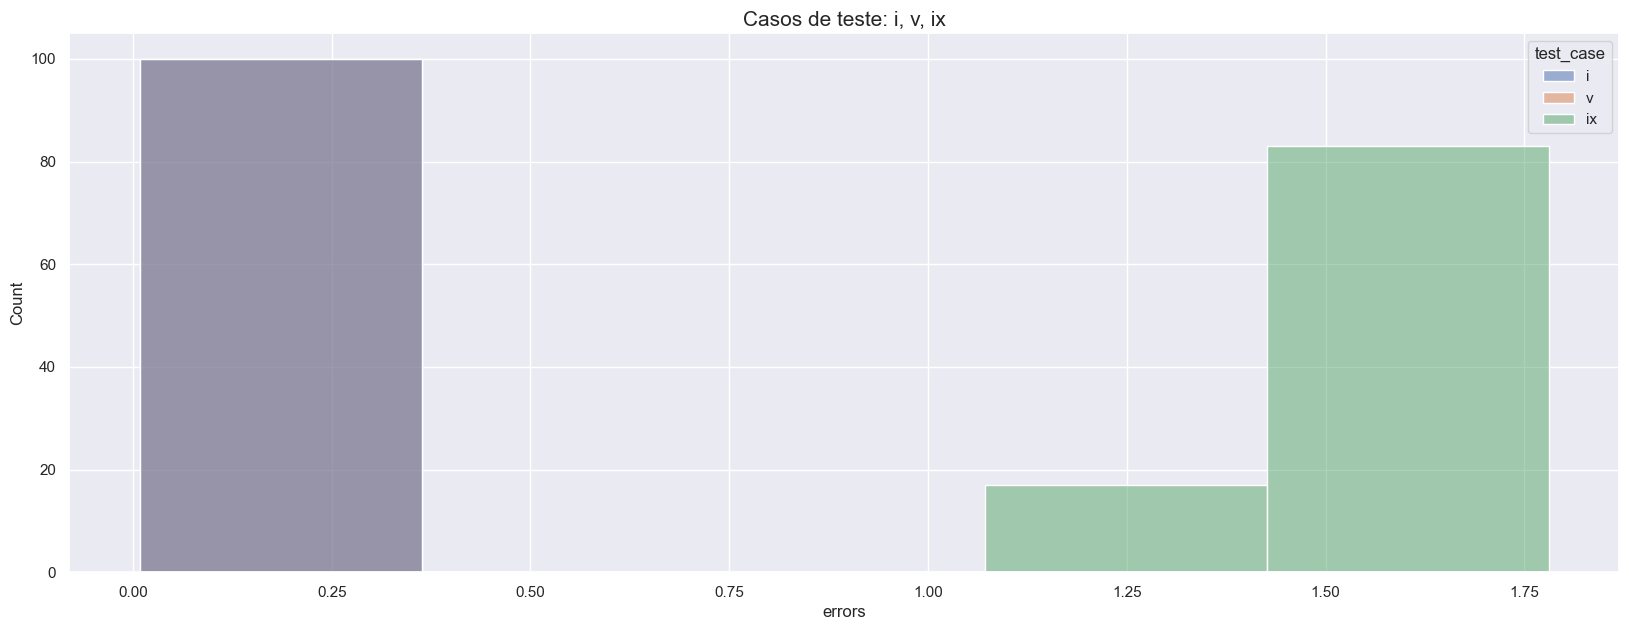

In [20]:
#############################################
# PRIOR UNIFORME: CASOS DE TESTE i, v, e ix #
#############################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['i','v','ix']
)

,test_case,errors_mean,errors_min,errors_max,errors_std
0,ii,0.071106,0.009157,0.227639,0.043048
1,vi,0.117618,0.061897,0.299905,0.034969
2,x,1.510637,1.070285,1.744122,0.120363


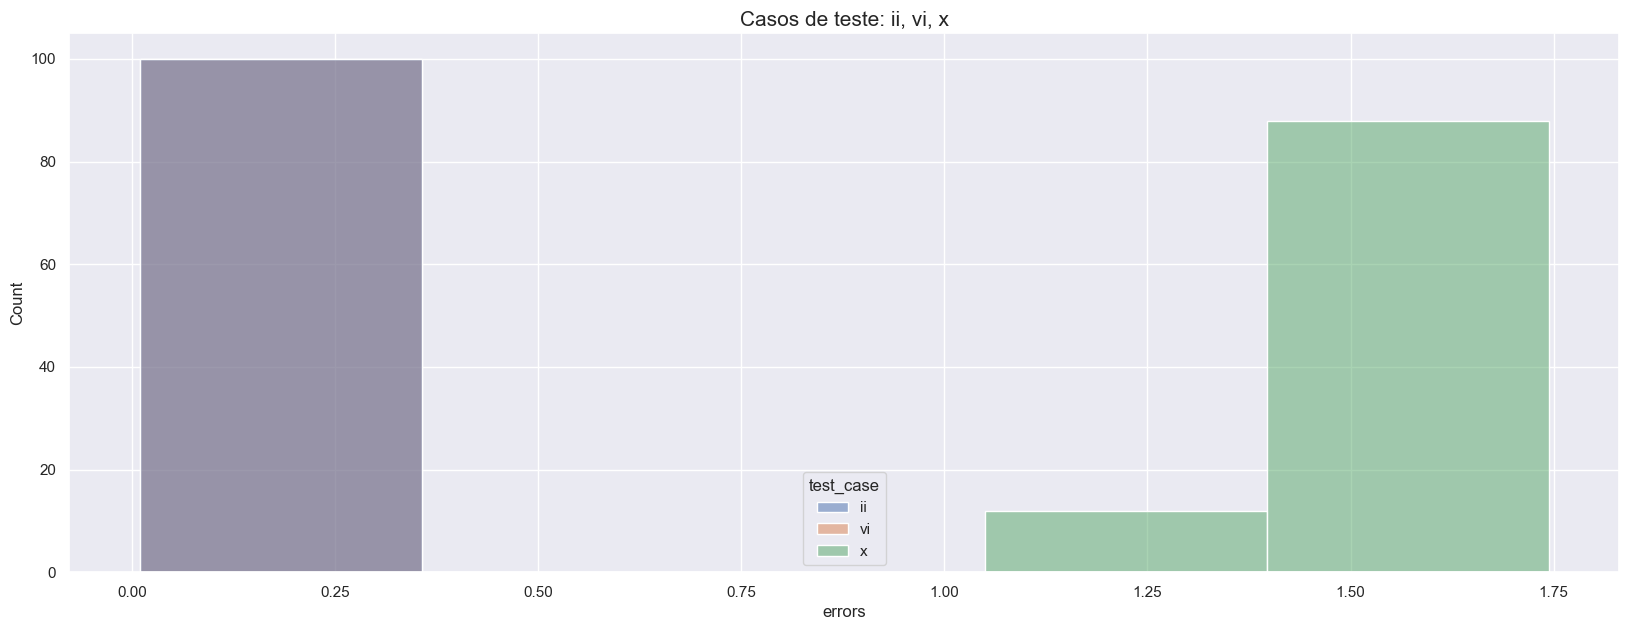

In [21]:
#################################################################
# PRIOR CORRETA E POUCO INFORMATIVA: CASOS DE TESTE ii, vi, e x #
#################################################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['ii','vi','x']
)

,test_case,errors_mean,errors_min,errors_max,errors_std
0,iii,0.035579,0.002515,0.083405,0.016556
1,vii,0.091200,0.052400,0.136153,0.015697
2,xi,0.789522,0.747466,0.840210,0.017221


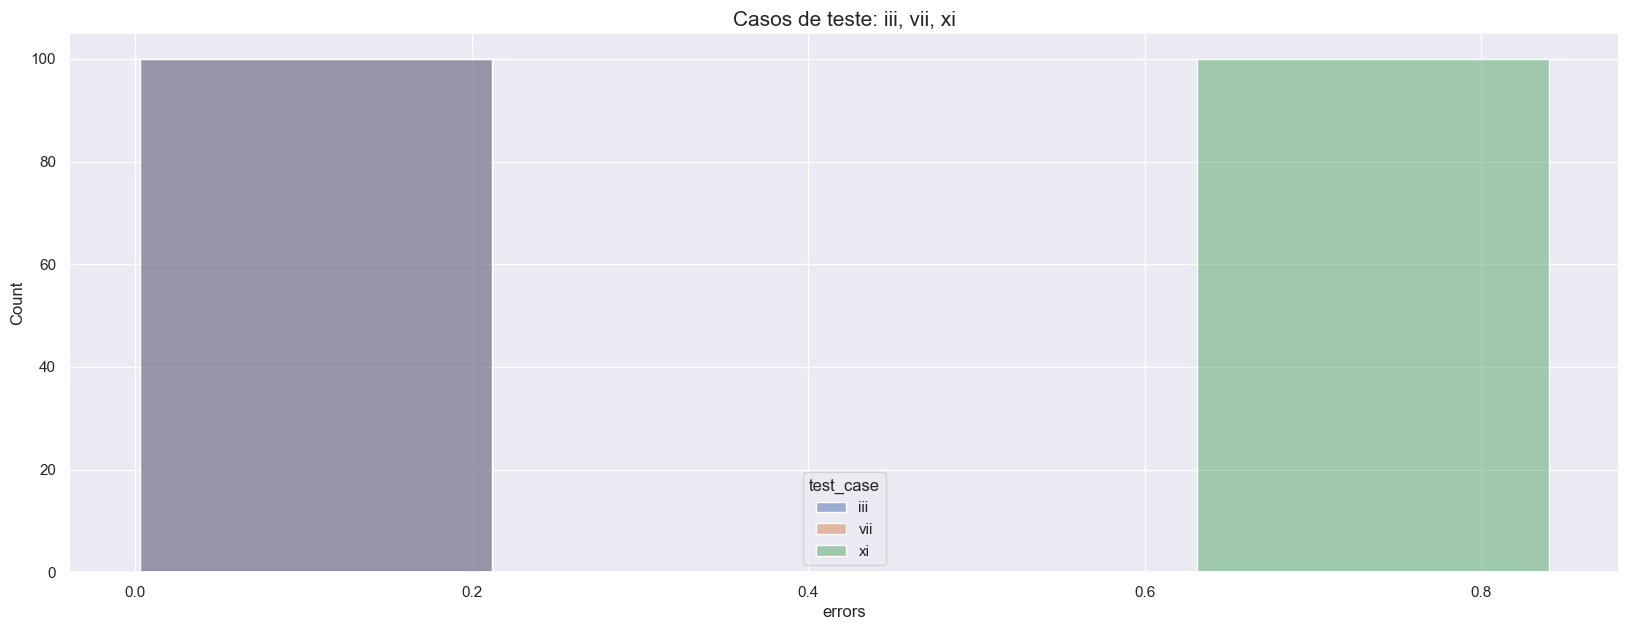

In [22]:
##############################################################
# PRIOR CORRETA E INFORMATIVA: CASOS DE TESTE iii, vii, e xi #
##############################################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['iii','vii','xi']
)

,test_case,errors_mean,errors_min,errors_max,errors_std
0,iv,0.786455,0.425711,1.004651,0.144375
1,viii,0.744462,0.382223,1.019005,0.173212
2,xii,1.251020,1.196930,1.300215,0.021271


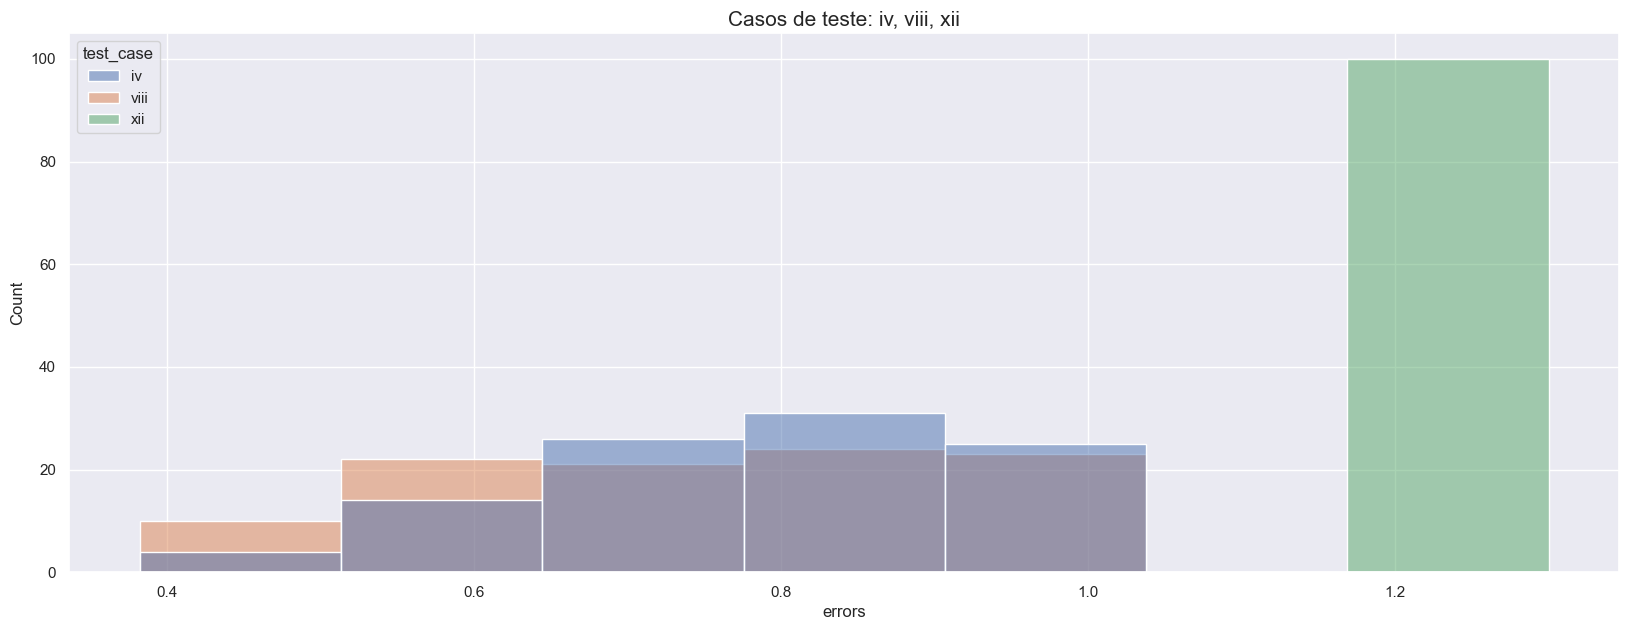

In [23]:
#################################################################
# PRIOR INCORRETA E INFORMATIVA: CASOS DE TESTE iv, viii, e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['iv','viii','xii']
)

## 2.4. Determinantes

### Mesmo modelo

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,i,0.798301,0.901879,1.057568,1.253239
1,ii,0.808117,0.910573,1.063565,1.231668
2,iii,0.807737,0.905905,1.062758,1.232823
3,iv,0.757355,0.898269,1.015763,1.168745


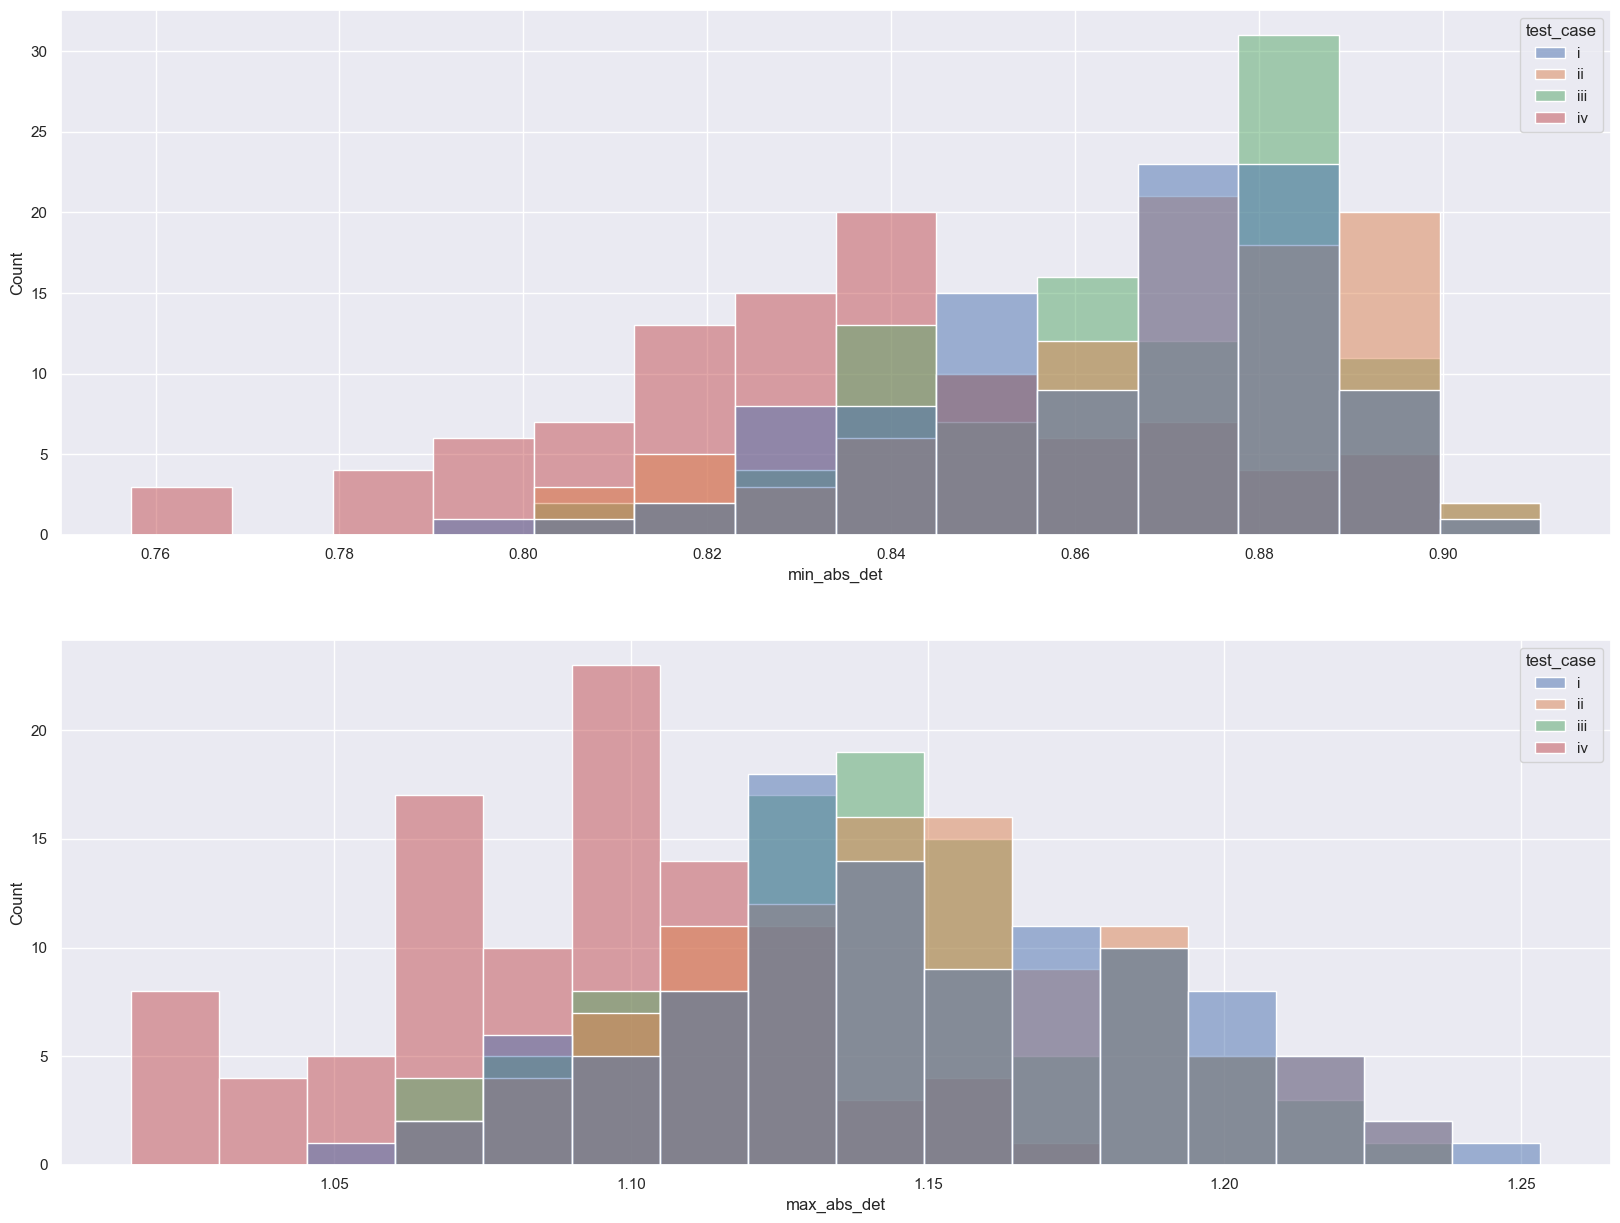

In [24]:
##########################################################
# ESPECIFICAÇÃO PERFEITA: CASOS DE TESTE i, ii, iii e iv #
##########################################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['i','ii','iii','iv']
)

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,v,0.655656,0.773363,0.894888,1.034283
1,vi,0.658727,0.789431,0.899632,1.020757
2,vii,0.662286,0.794729,0.893162,1.009495
3,viii,0.642192,0.746975,0.885909,0.985649


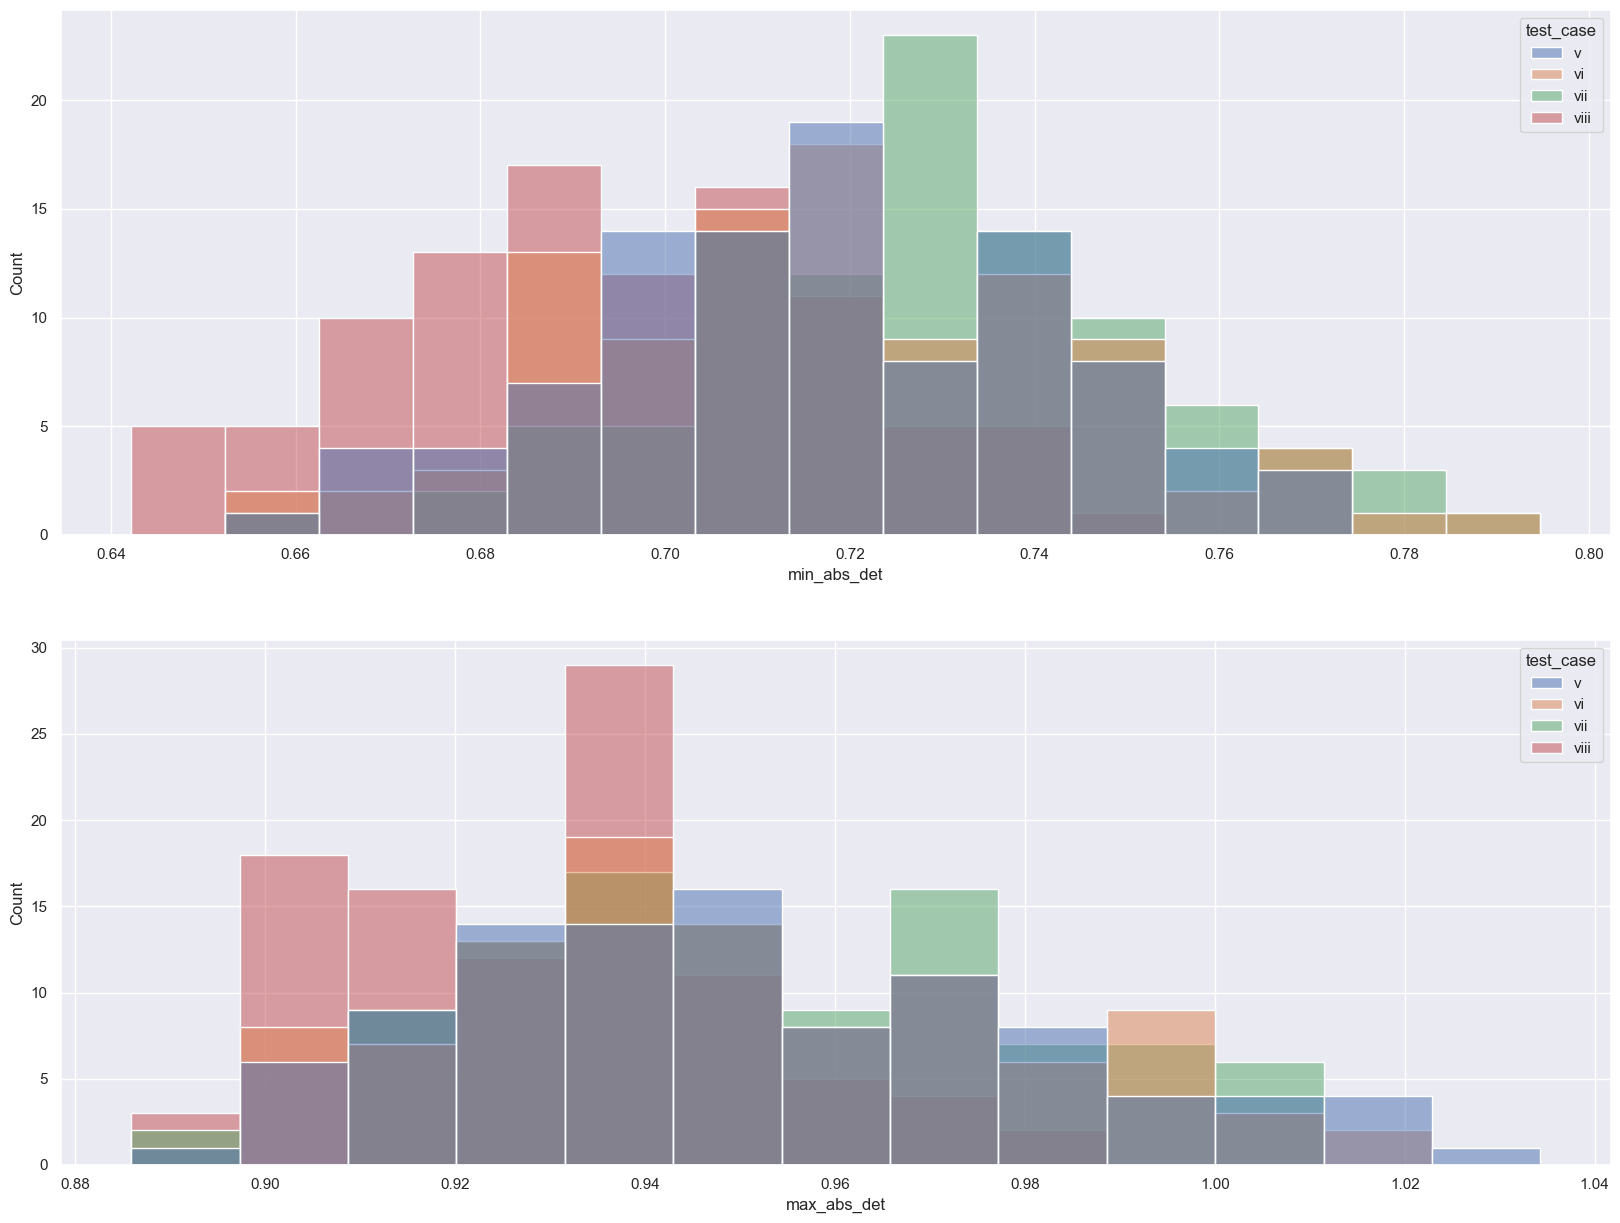

In [25]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['v','vi','vii','viii']
)

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,ix,0.895089,0.903752,4.736723,5.408037
1,x,0.898054,0.924602,4.735510,5.392251
2,xi,0.892401,0.915950,3.565755,3.998089
3,xii,0.898054,0.933701,3.599999,3.975904


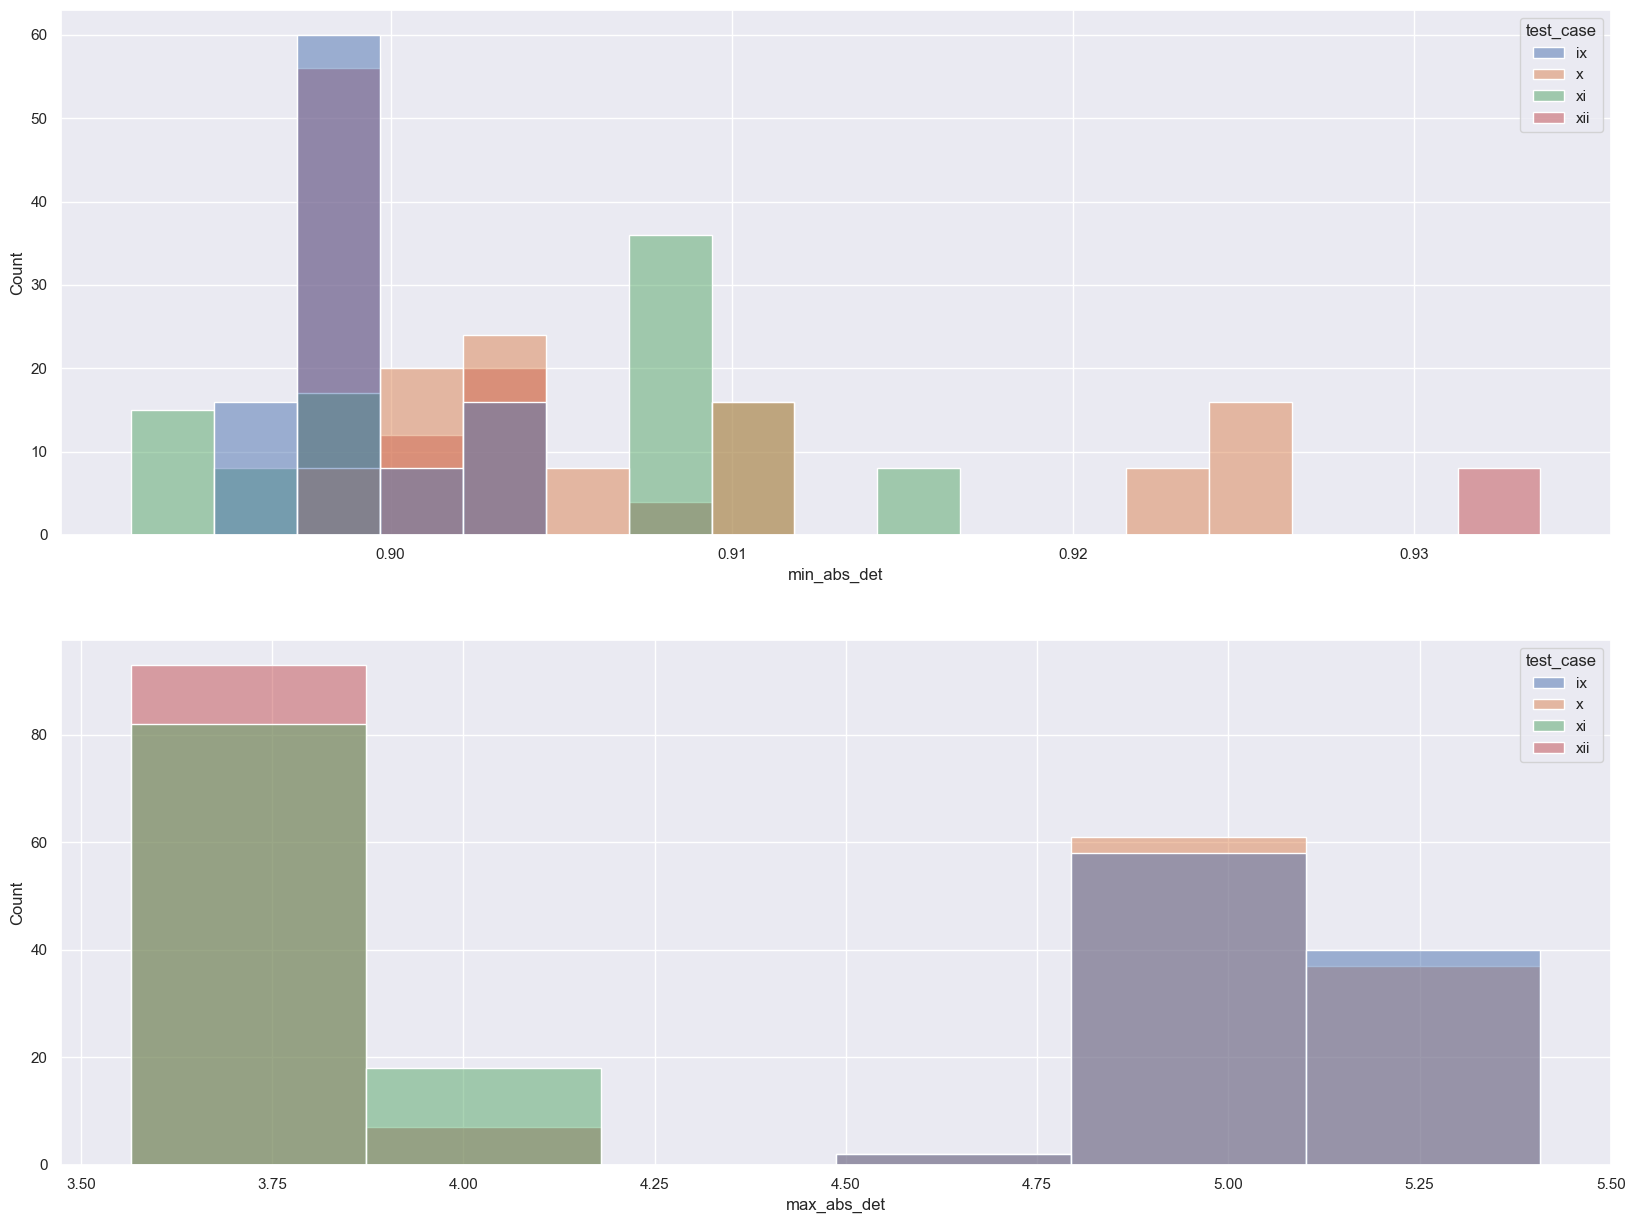

In [26]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['ix','x','xi','xii']
)

### Mesma prior

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,i,0.798301,0.901879,1.057568,1.253239
1,ix,0.895089,0.903752,4.736723,5.408037
2,v,0.655656,0.773363,0.894888,1.034283


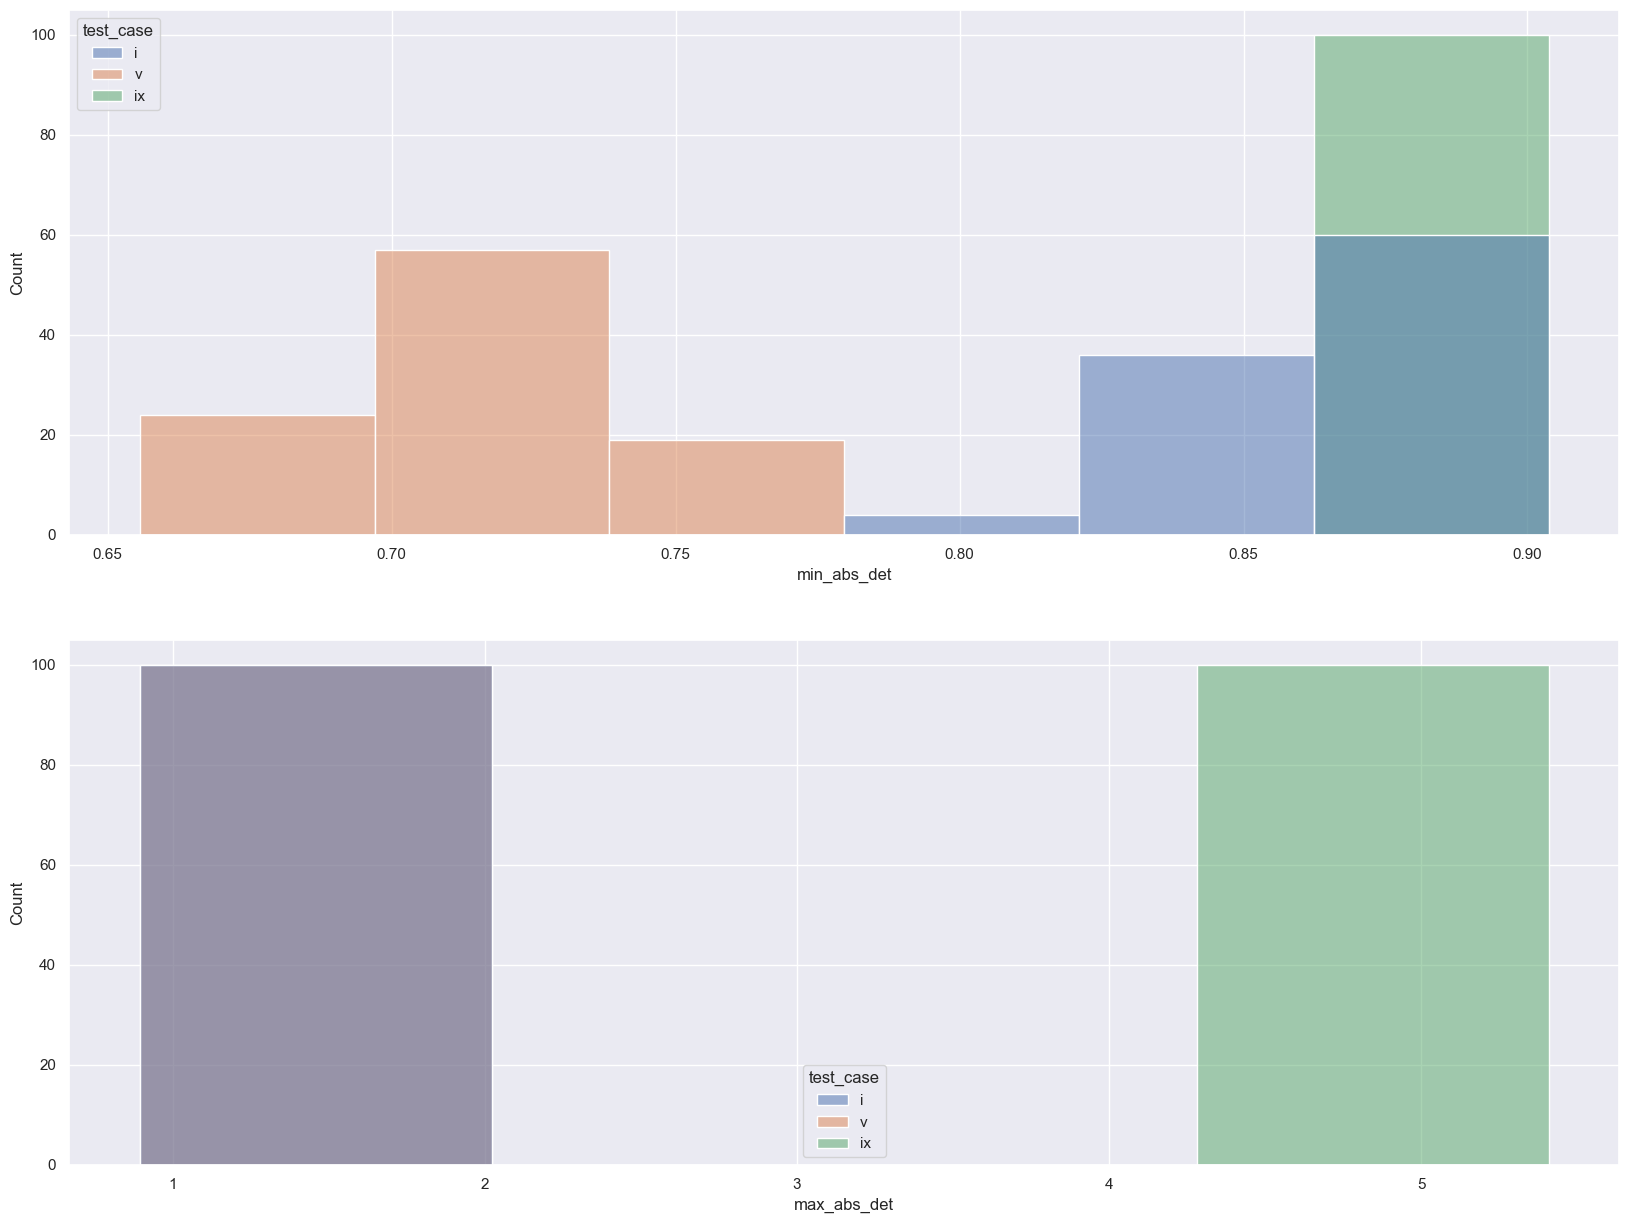

In [27]:
#############################################
# PRIOR UNIFORME: CASOS DE TESTE i, v, e ix #
#############################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['i','v','ix']
)

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,ii,0.808117,0.910573,1.063565,1.231668
1,vi,0.658727,0.789431,0.899632,1.020757
2,x,0.898054,0.924602,4.735510,5.392251


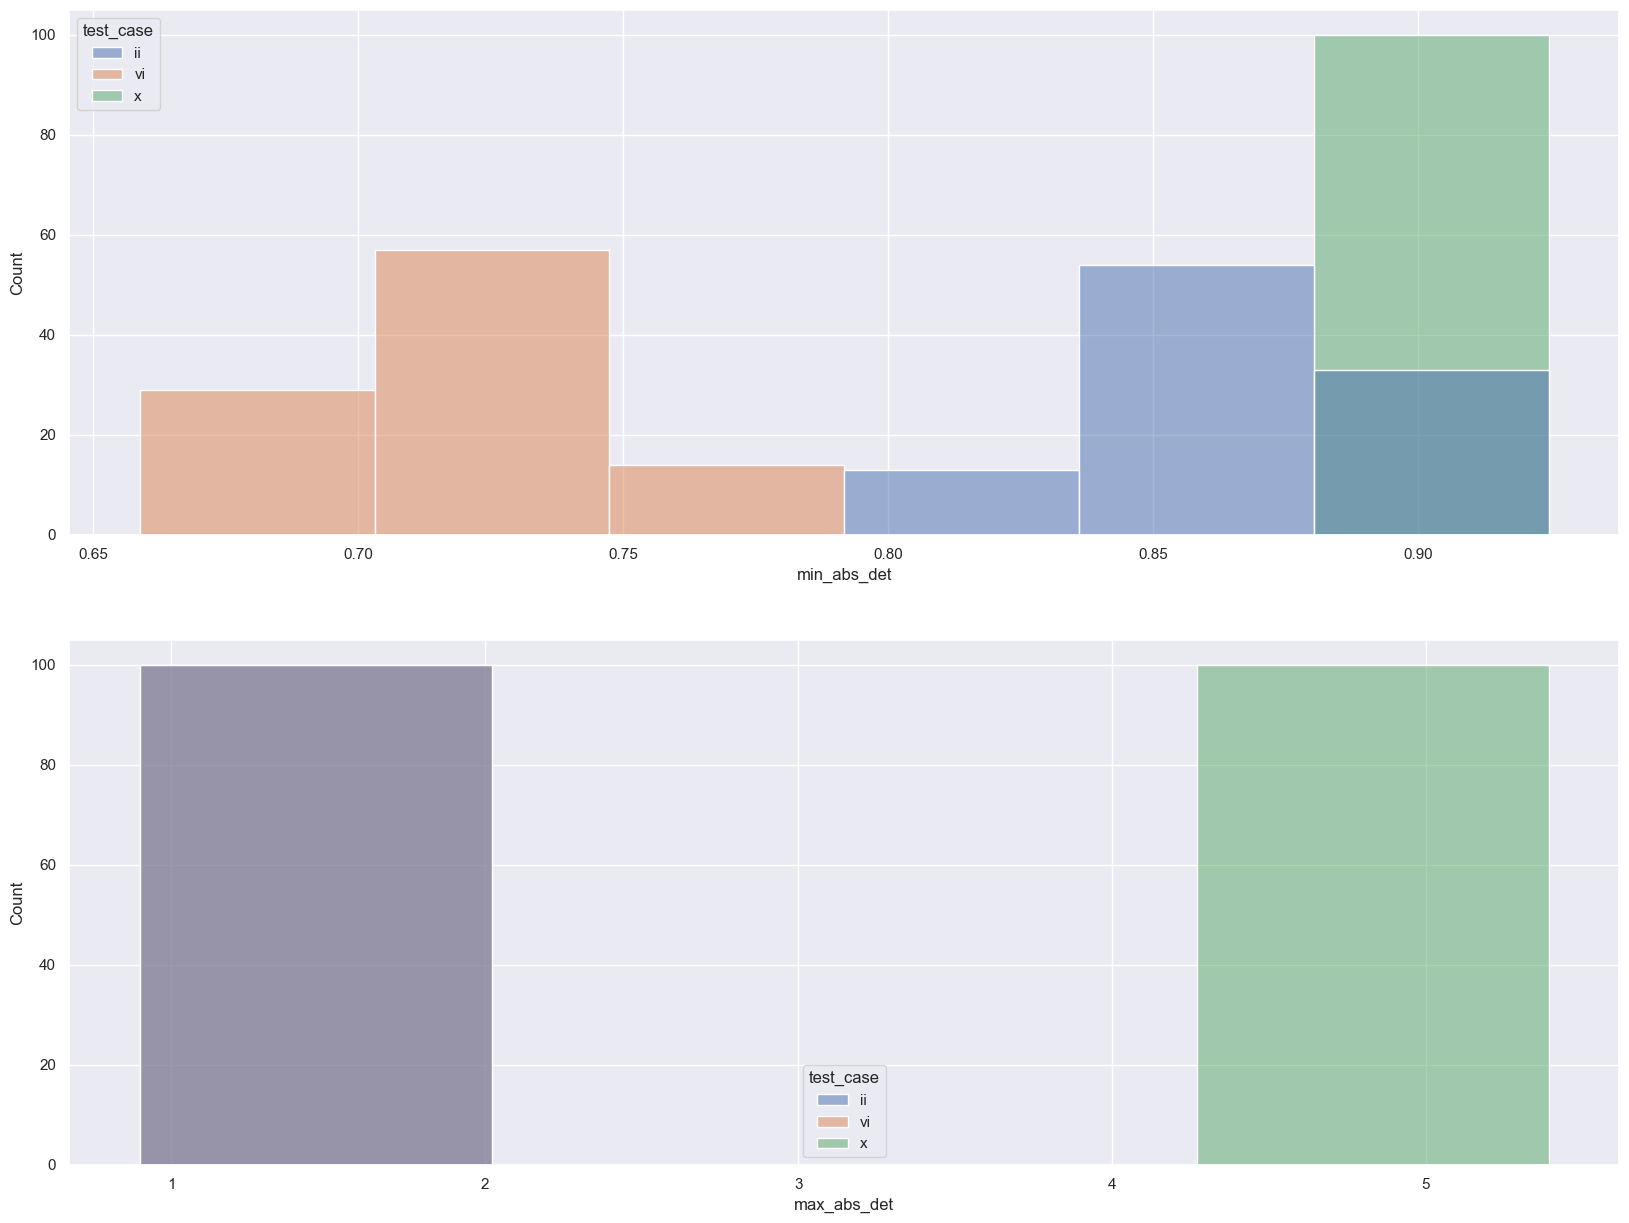

In [28]:
#################################################################
# PRIOR CORRETA E POUCO INFORMATIVA: CASOS DE TESTE ii, vi, e x #
#################################################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['ii','vi','x']
)

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,iii,0.807737,0.905905,1.062758,1.232823
1,vii,0.662286,0.794729,0.893162,1.009495
2,xi,0.892401,0.915950,3.565755,3.998089


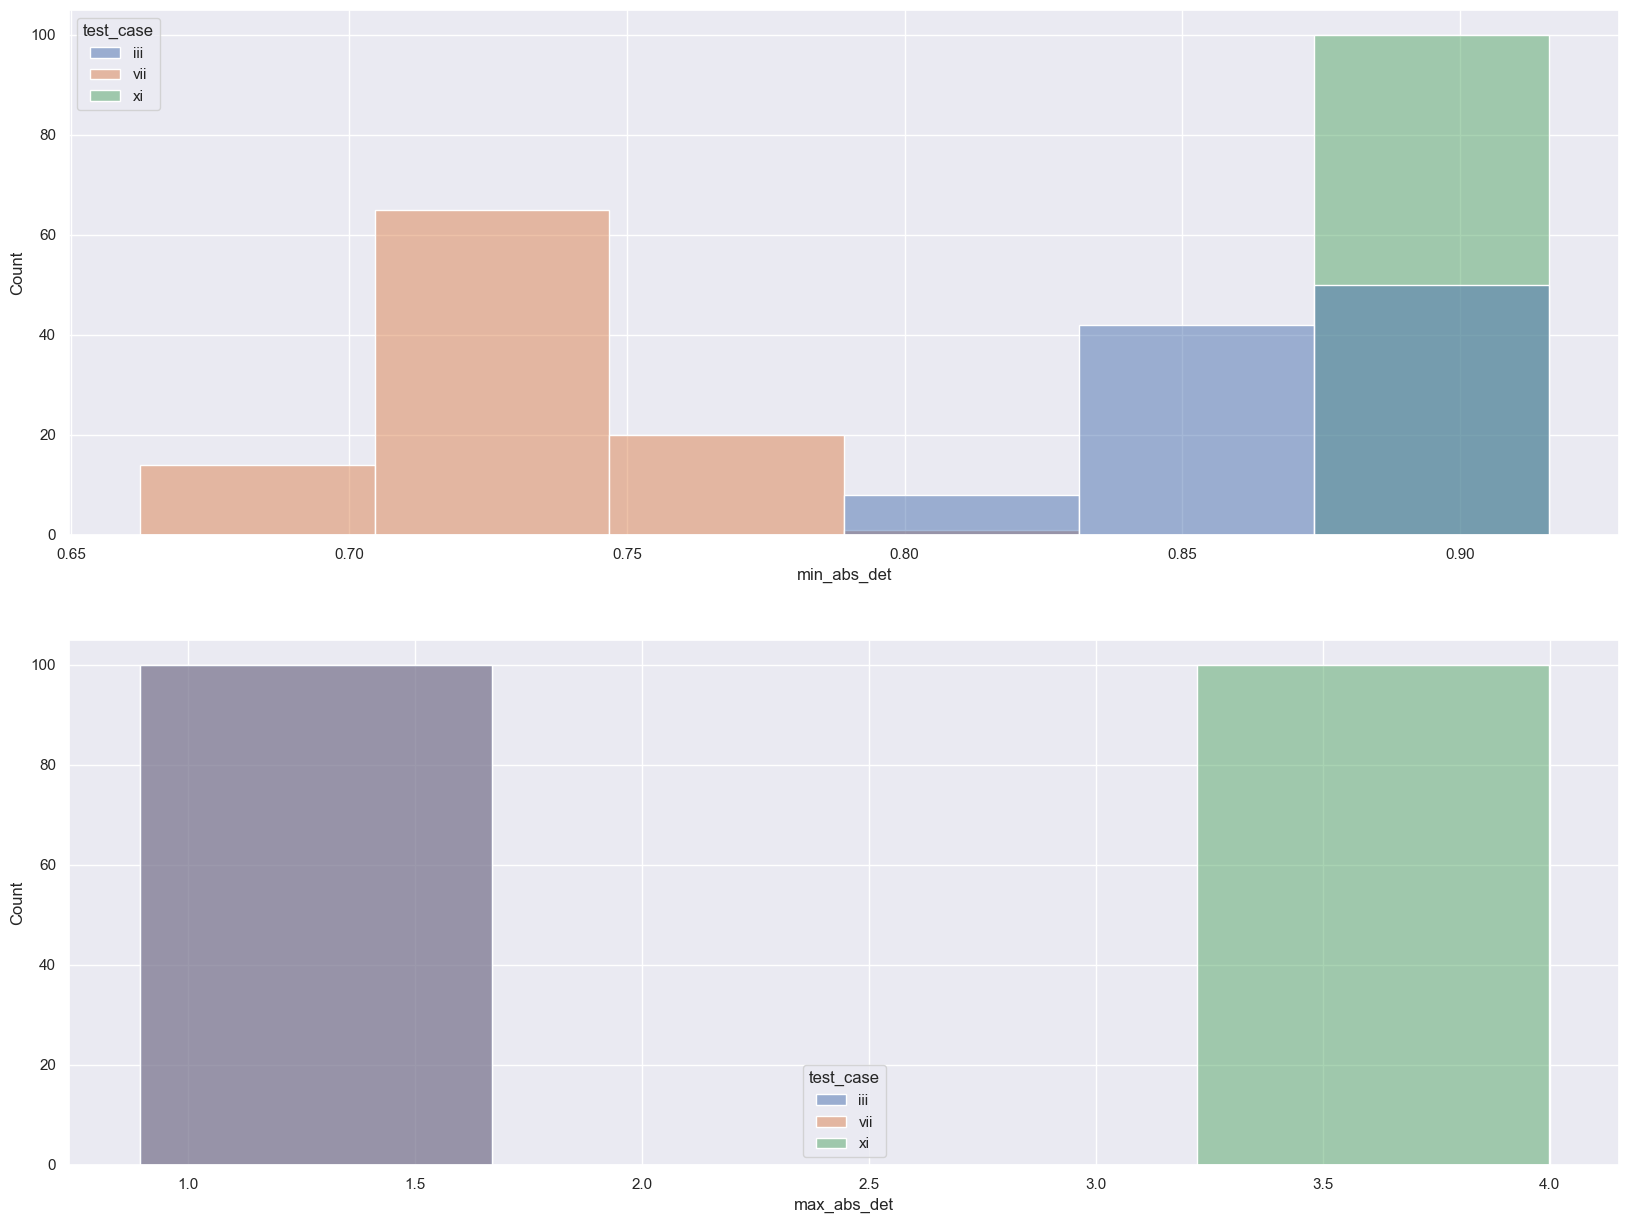

In [29]:
##############################################################
# PRIOR CORRETA E INFORMATIVA: CASOS DE TESTE iii, vii, e xi #
##############################################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['iii','vii','xi']
)

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,iv,0.757355,0.898269,1.015763,1.168745
1,viii,0.642192,0.746975,0.885909,0.985649
2,xii,0.898054,0.933701,3.599999,3.975904


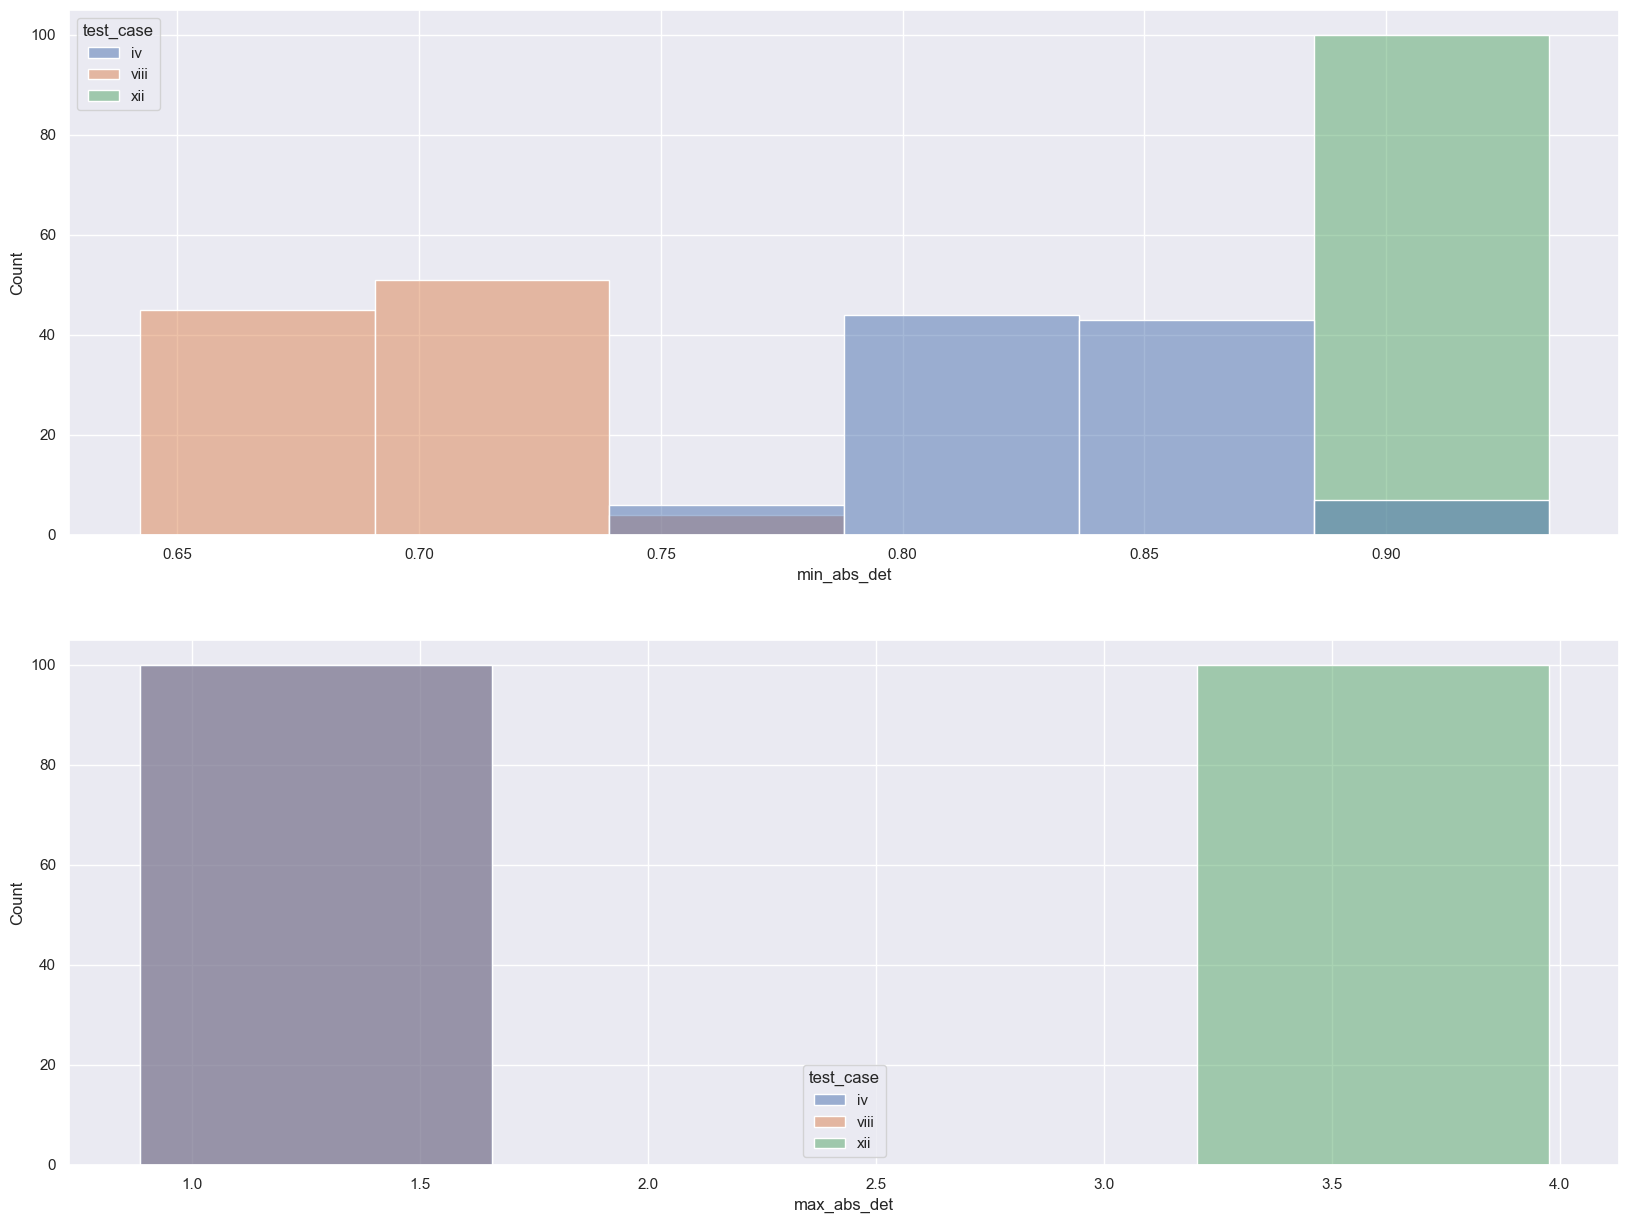

In [30]:
#################################################################
# PRIOR INCORRETA E INFORMATIVA: CASOS DE TESTE iv, viii, e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['iv','viii','xii']
)

### Todos os casos de teste - scatterplots

/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:2095: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


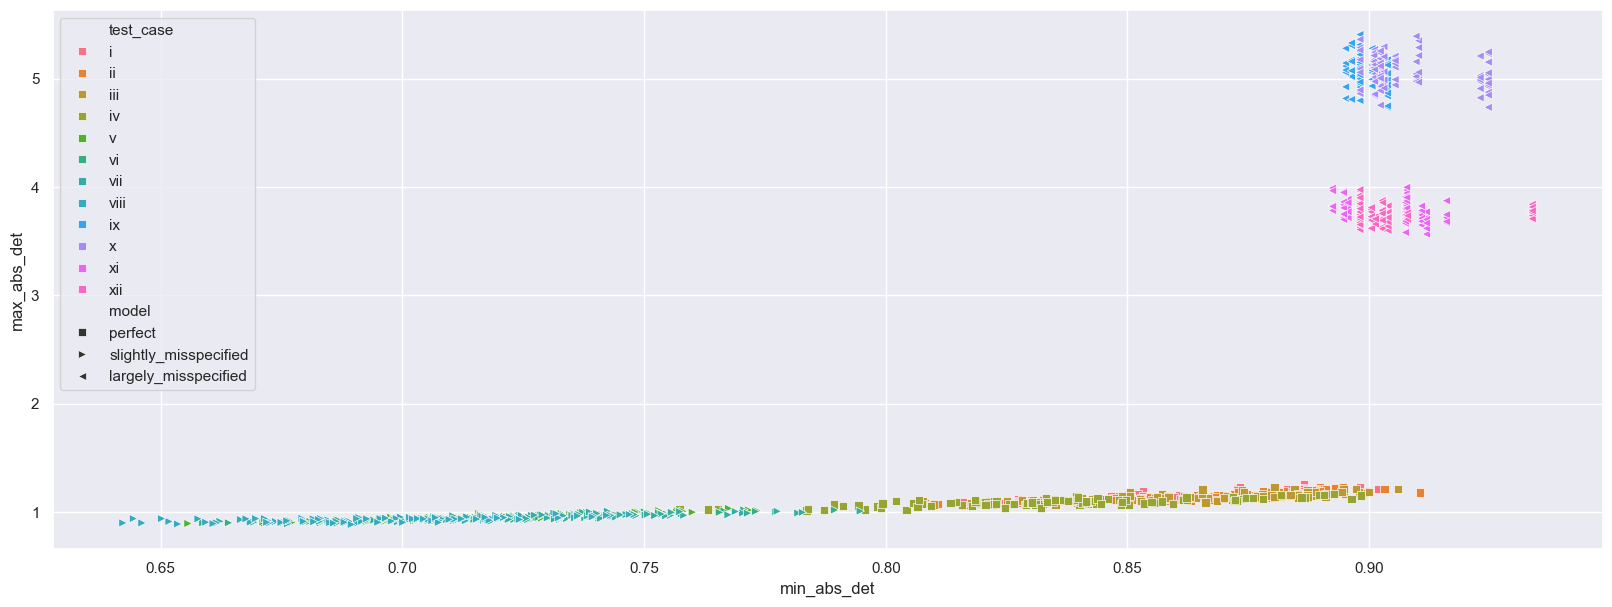

In [3]:
####################################
# MARKERS IGUAIS PARA MESMO MODELO #
####################################

EstimationGraphPlotter.plot_test_cases_determinants_scatter(
    parser,
    marker='model'
)

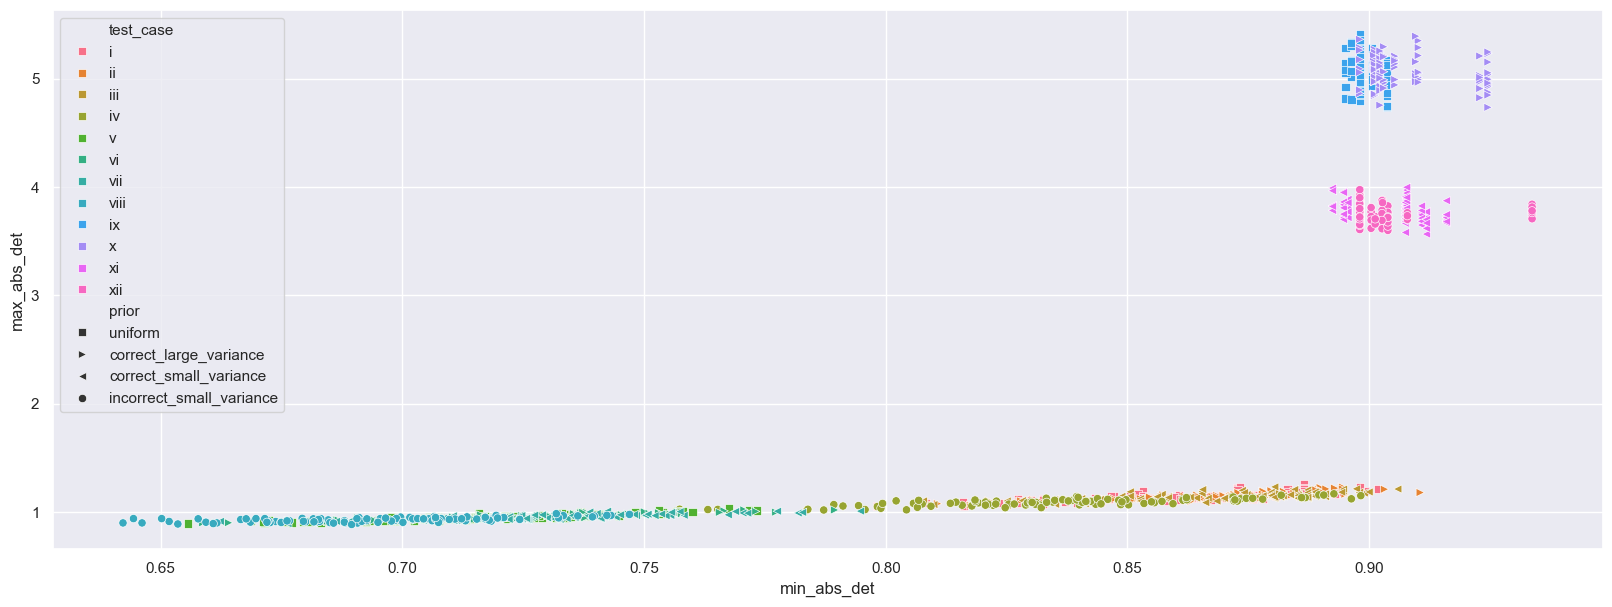

In [4]:
###################################
# MARKERS IGUAIS PARA MESMA PRIOR #
###################################

EstimationGraphPlotter.plot_test_cases_determinants_scatter(
    parser,
    marker='prior'
)

# 3. Análises - casos de teste individuais    

## i.

In [ ]:
test_case='i'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:1570: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(


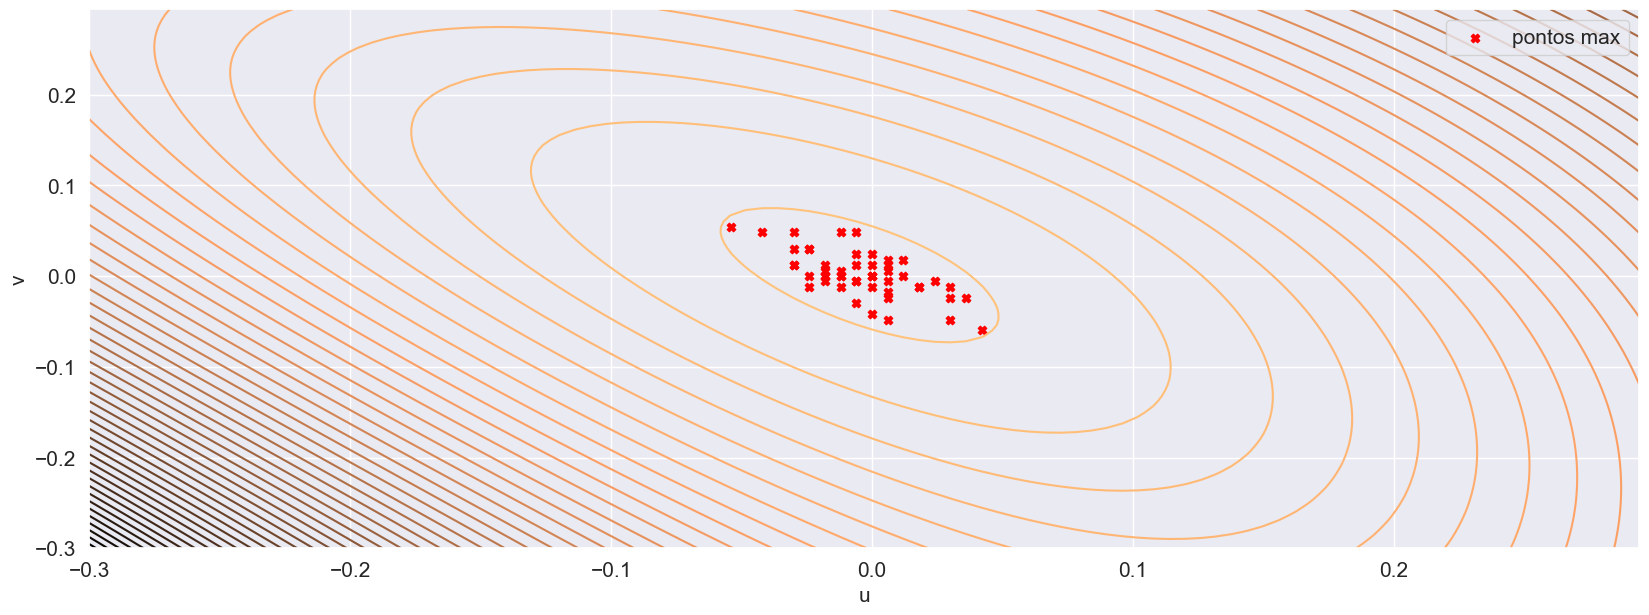

In [ ]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


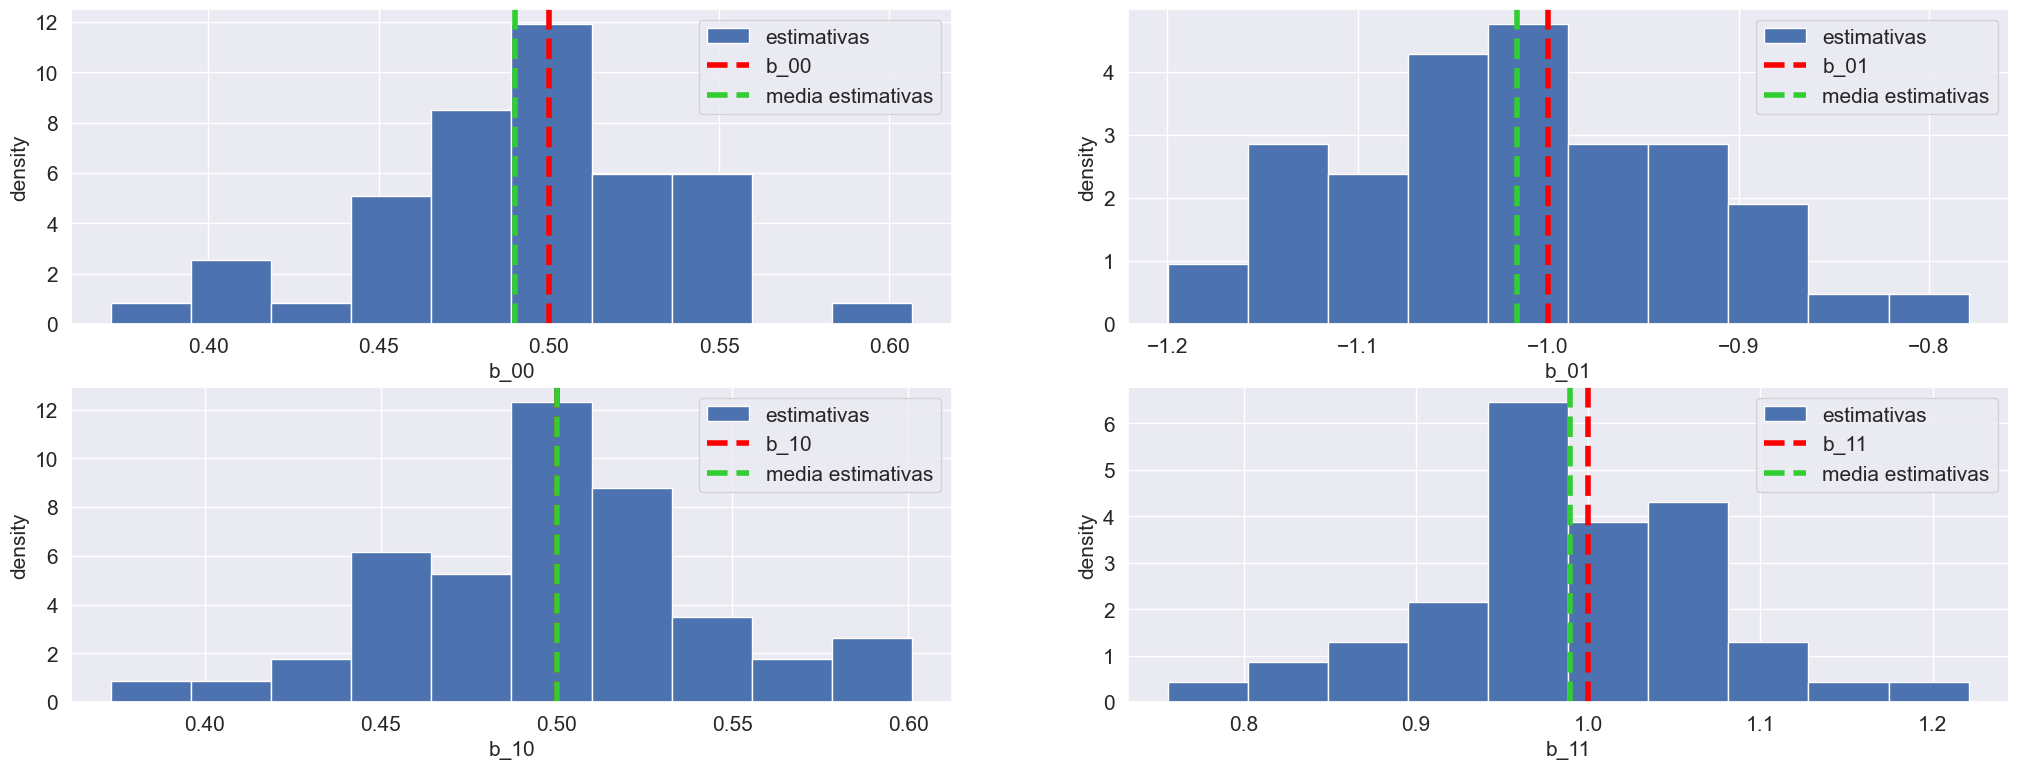

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.07
Max error: 0.22
Min error: 0.01
####################################################################################################


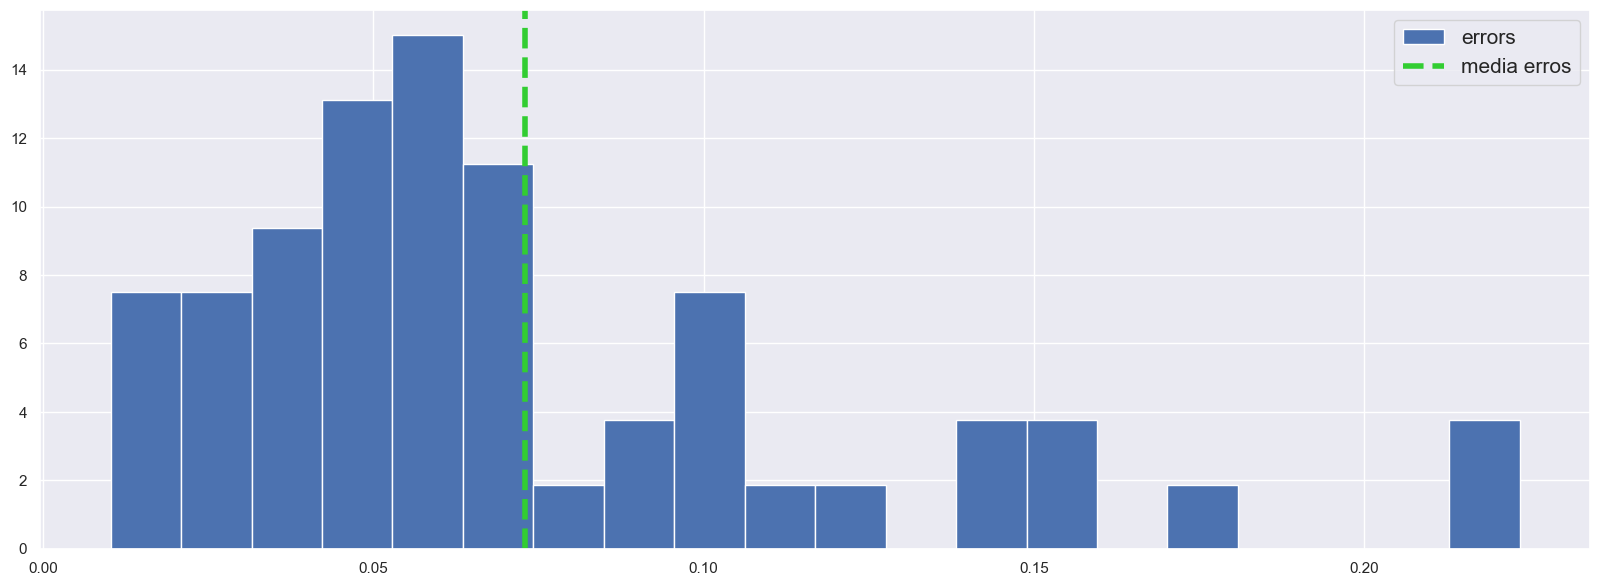

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


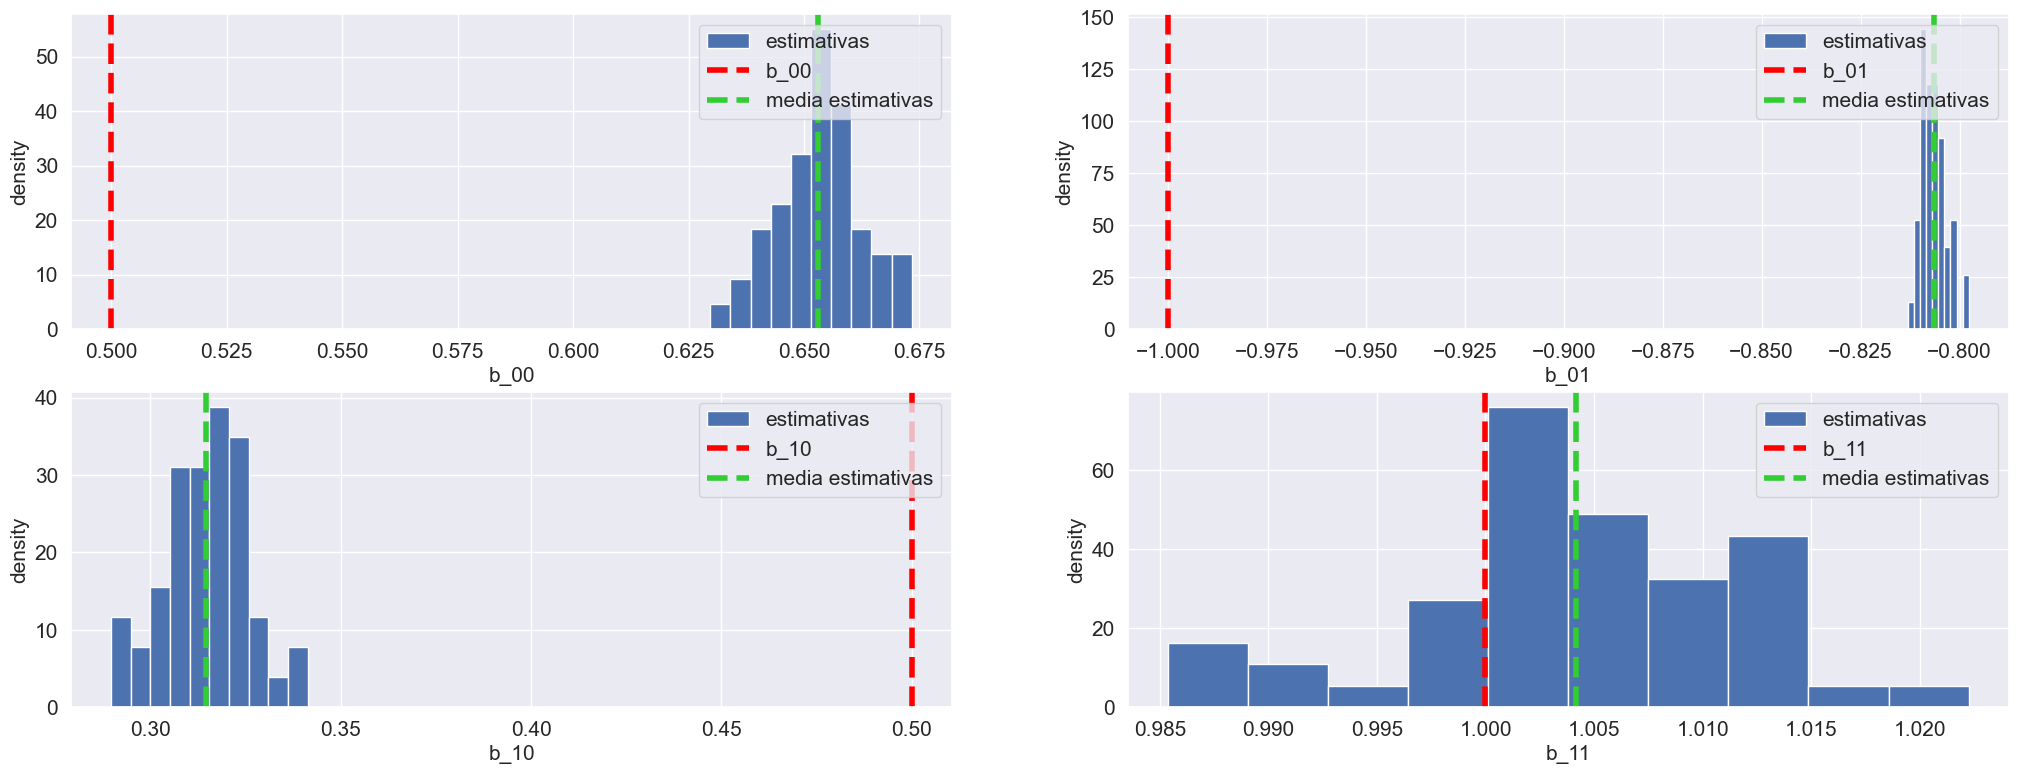

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.2
Max error: 0.21
Min error: 0.18
####################################################################################################


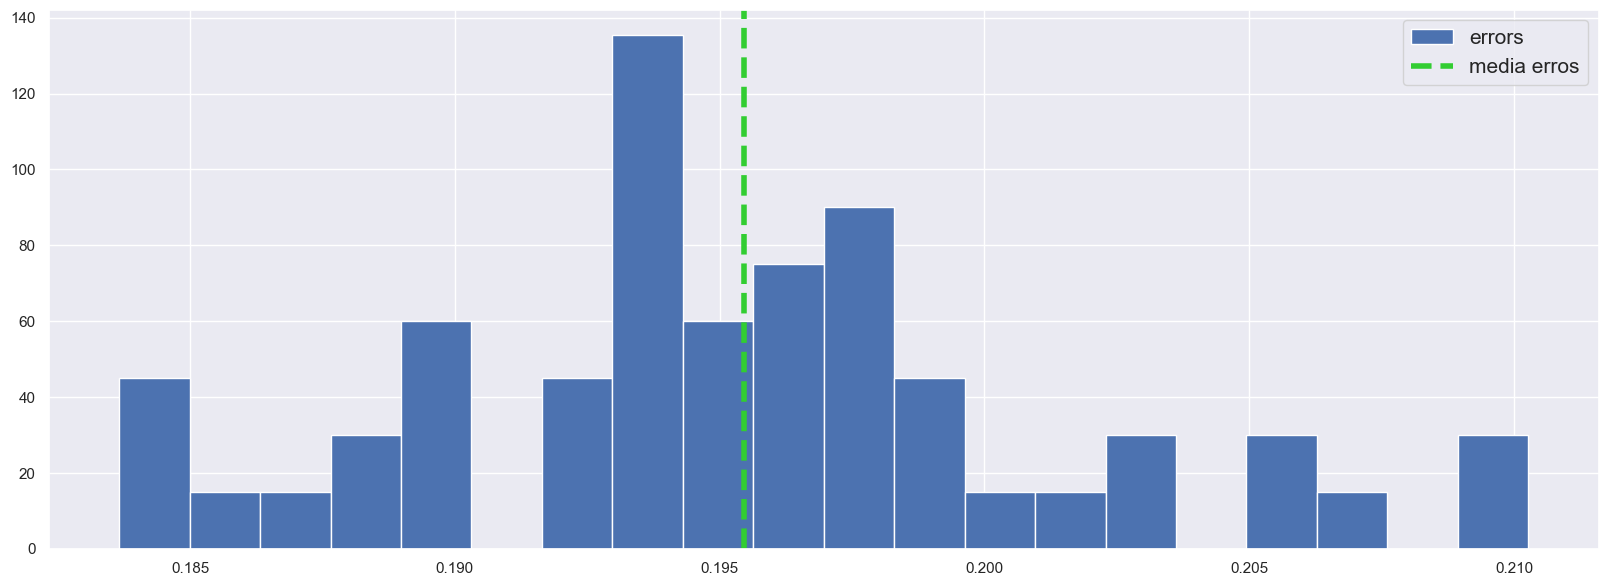

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## ii.

In [ ]:
test_case='ii'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


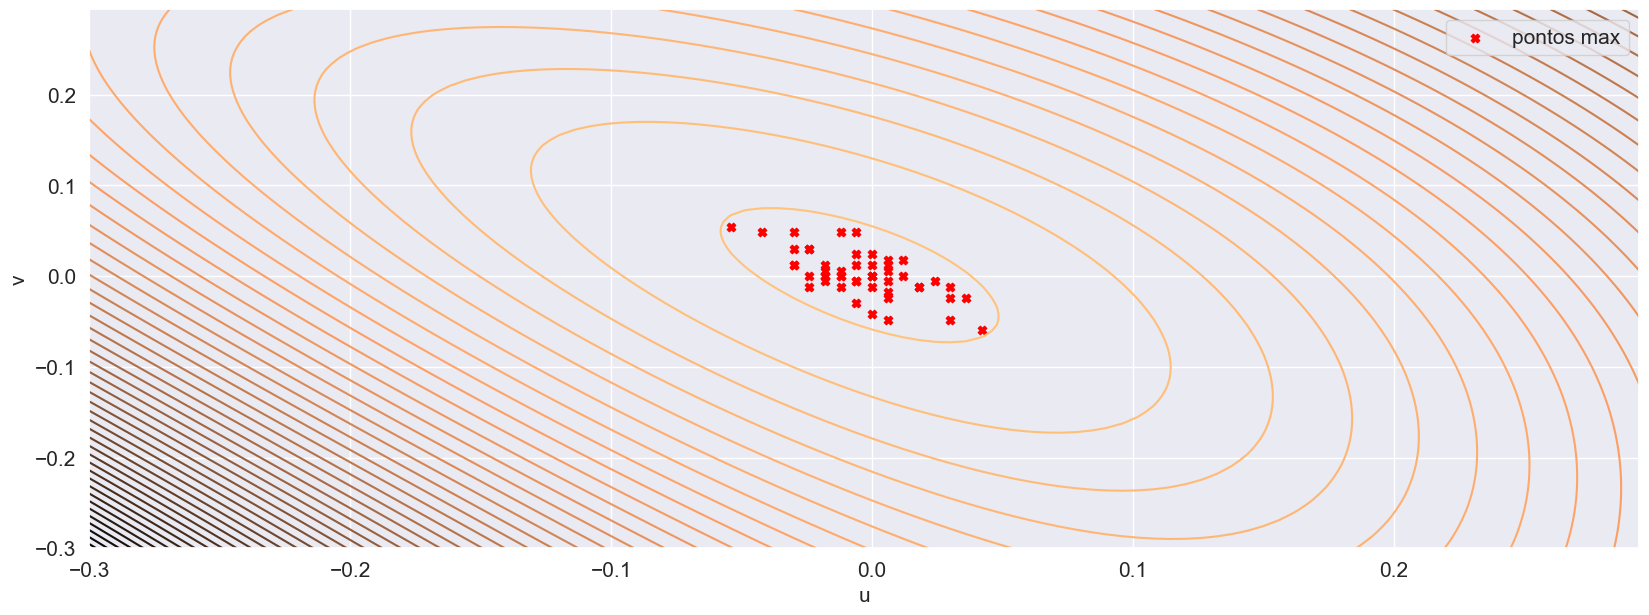

In [ ]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


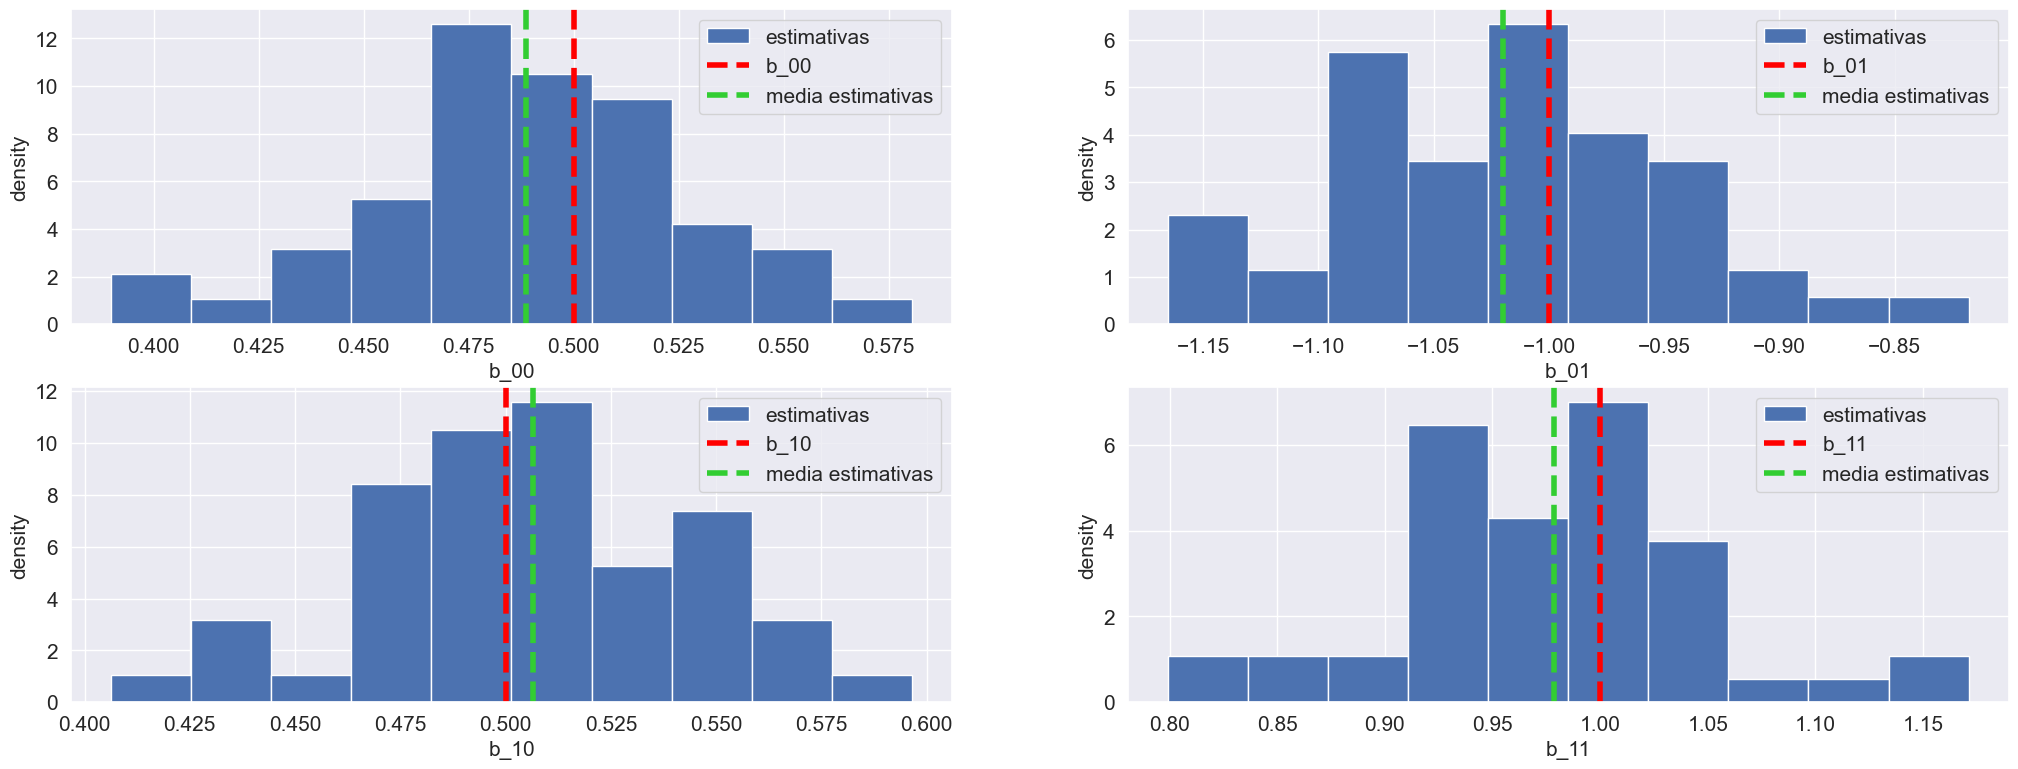

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.06
Max error: 0.19
Min error: 0.01
####################################################################################################


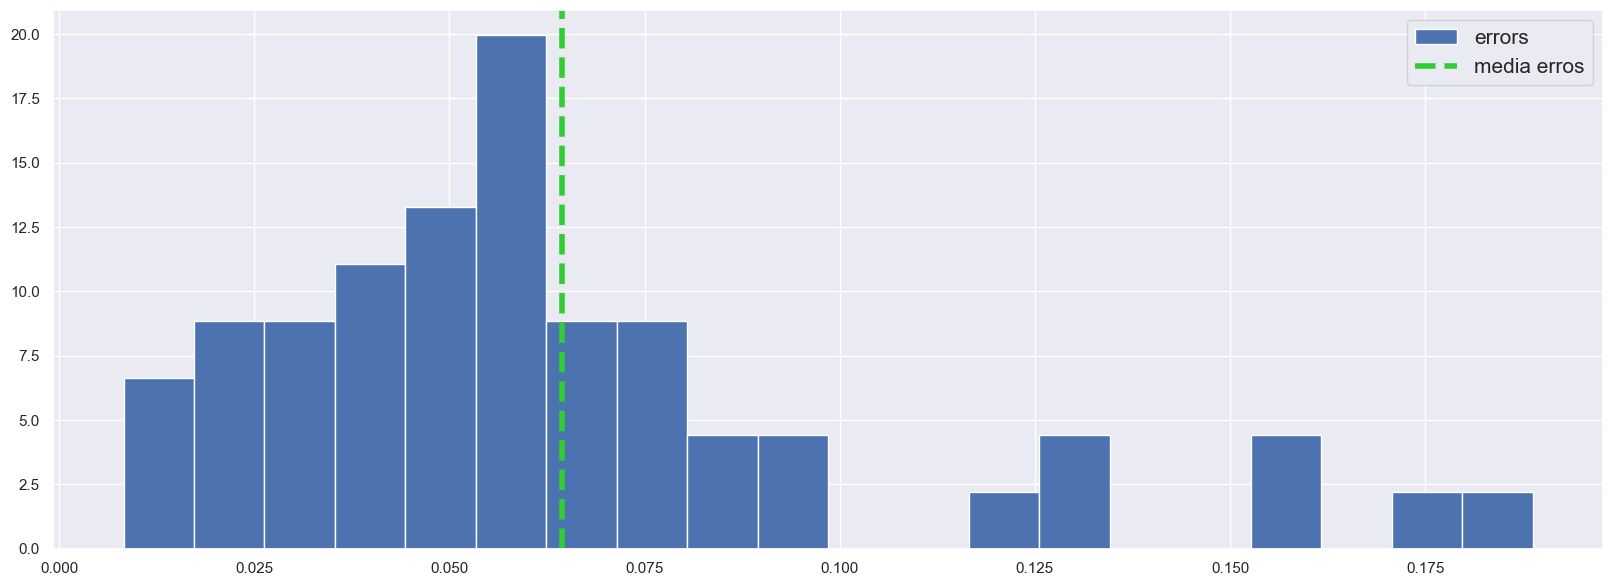

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


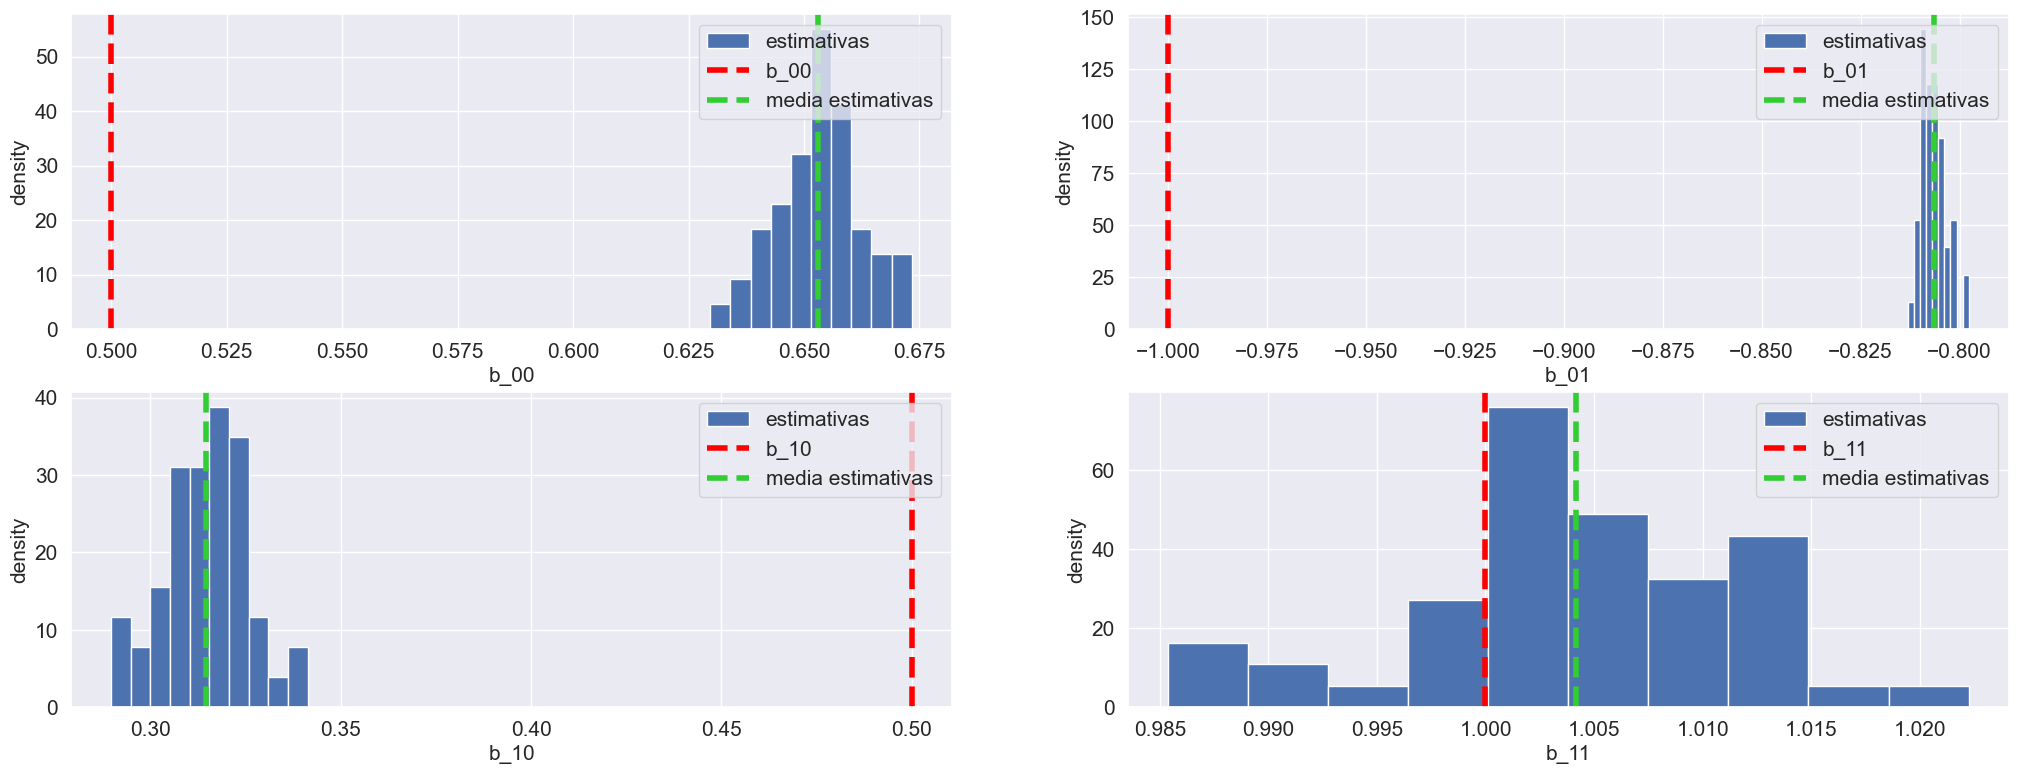

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.2
Max error: 0.21
Min error: 0.18
####################################################################################################


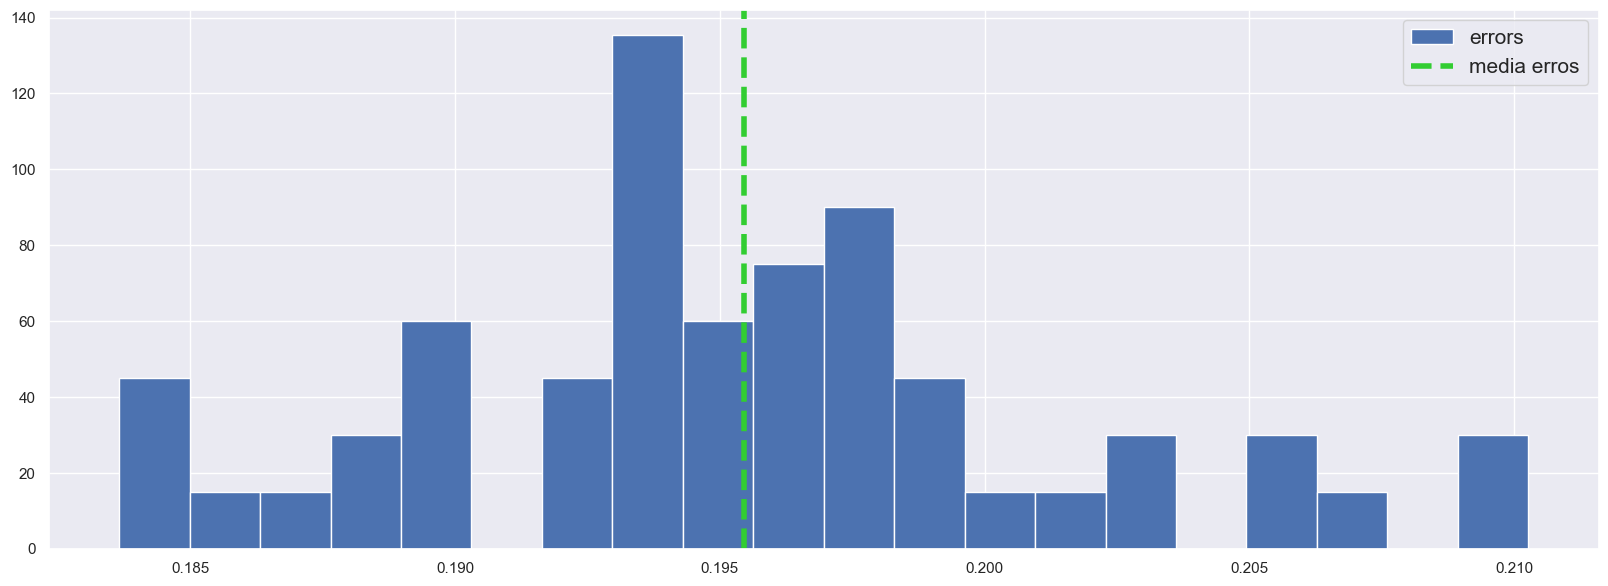

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## iii.

In [ ]:
test_case='iii'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


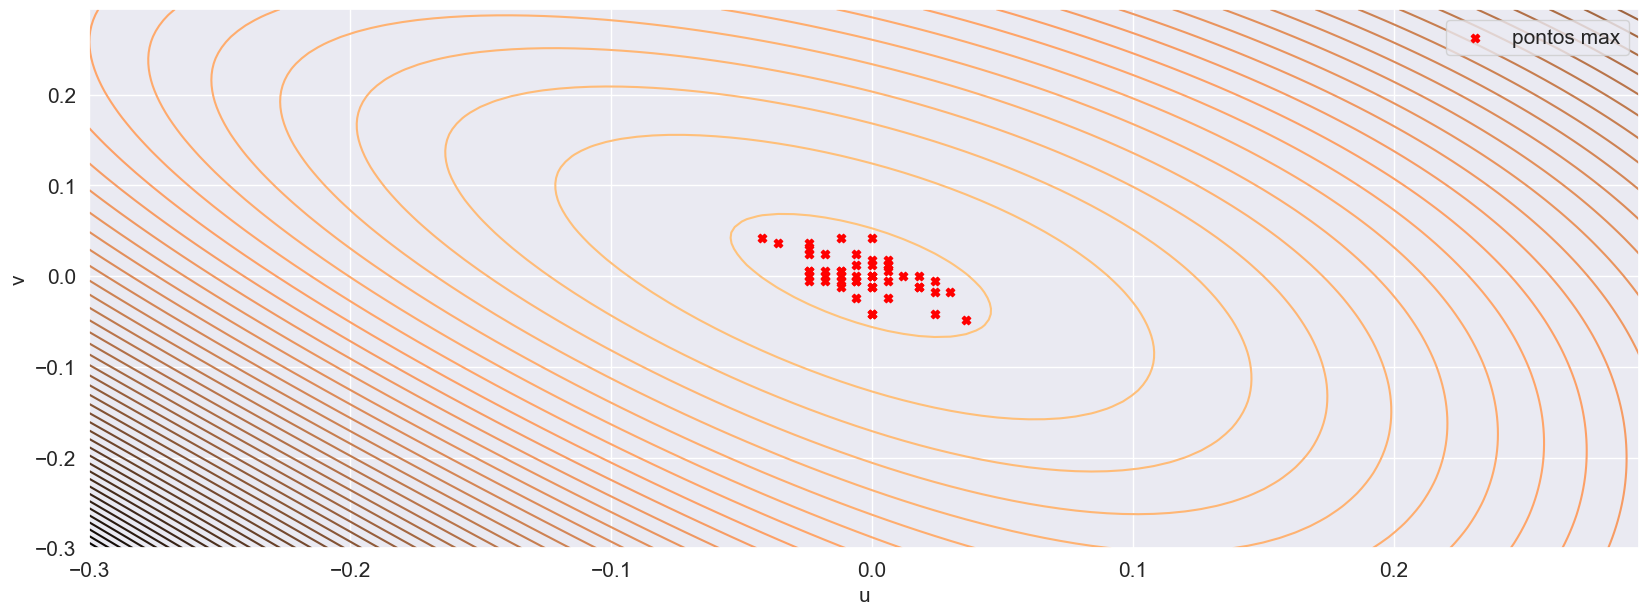

In [ ]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


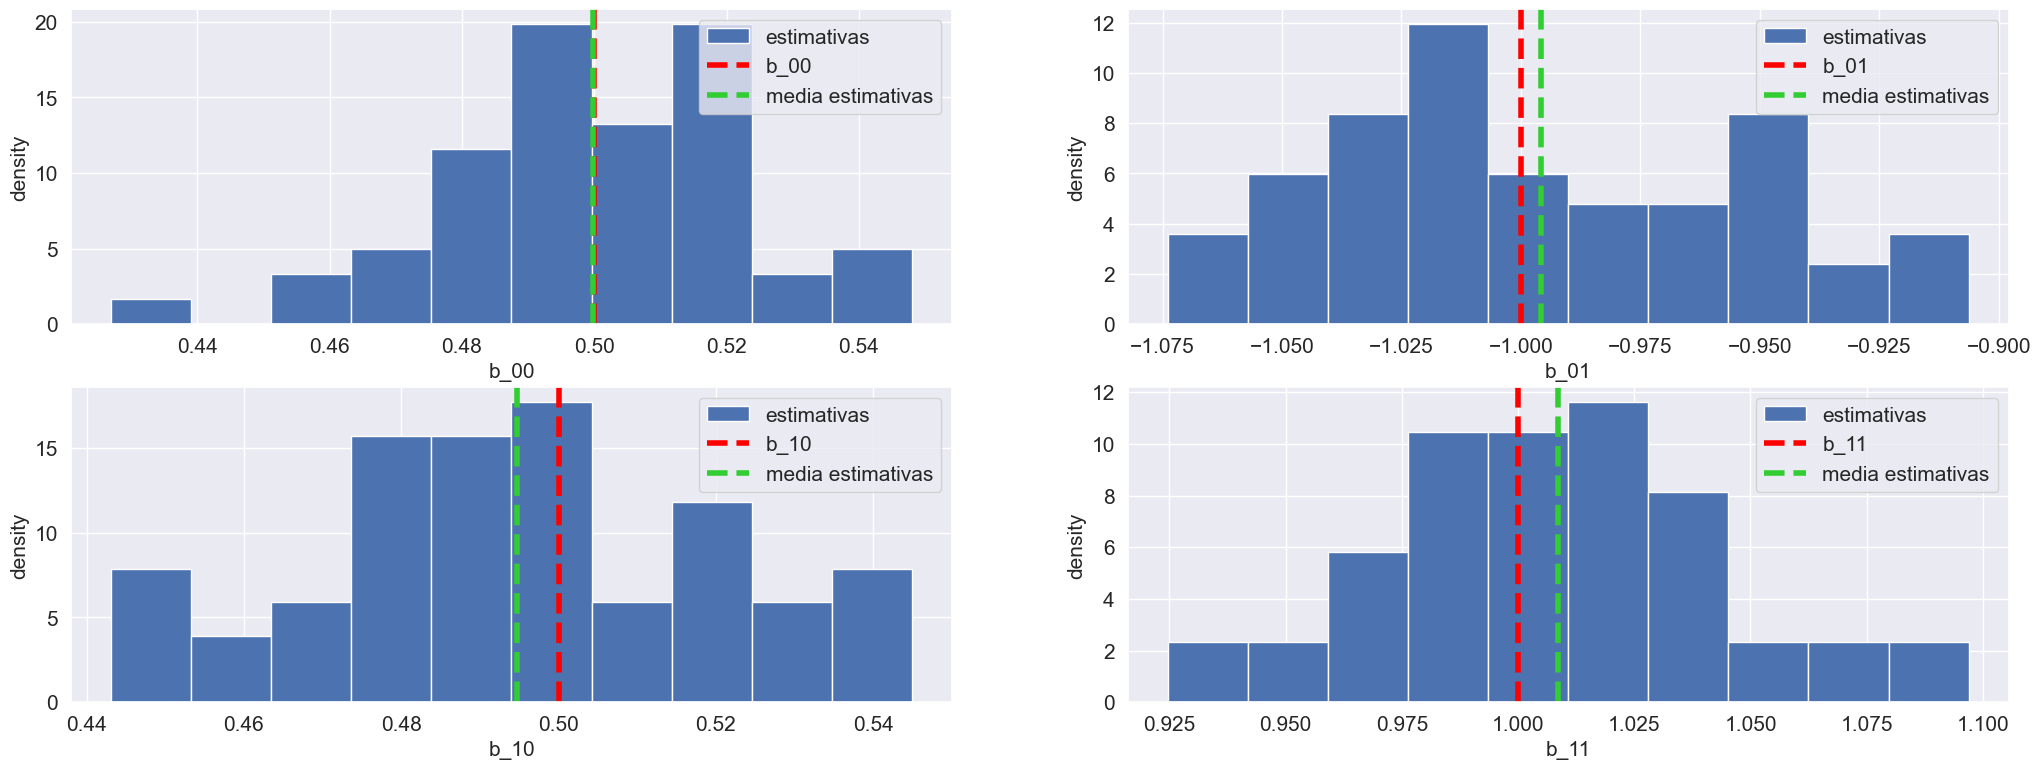

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.04
Max error: 0.09
Min error: 0.01
####################################################################################################


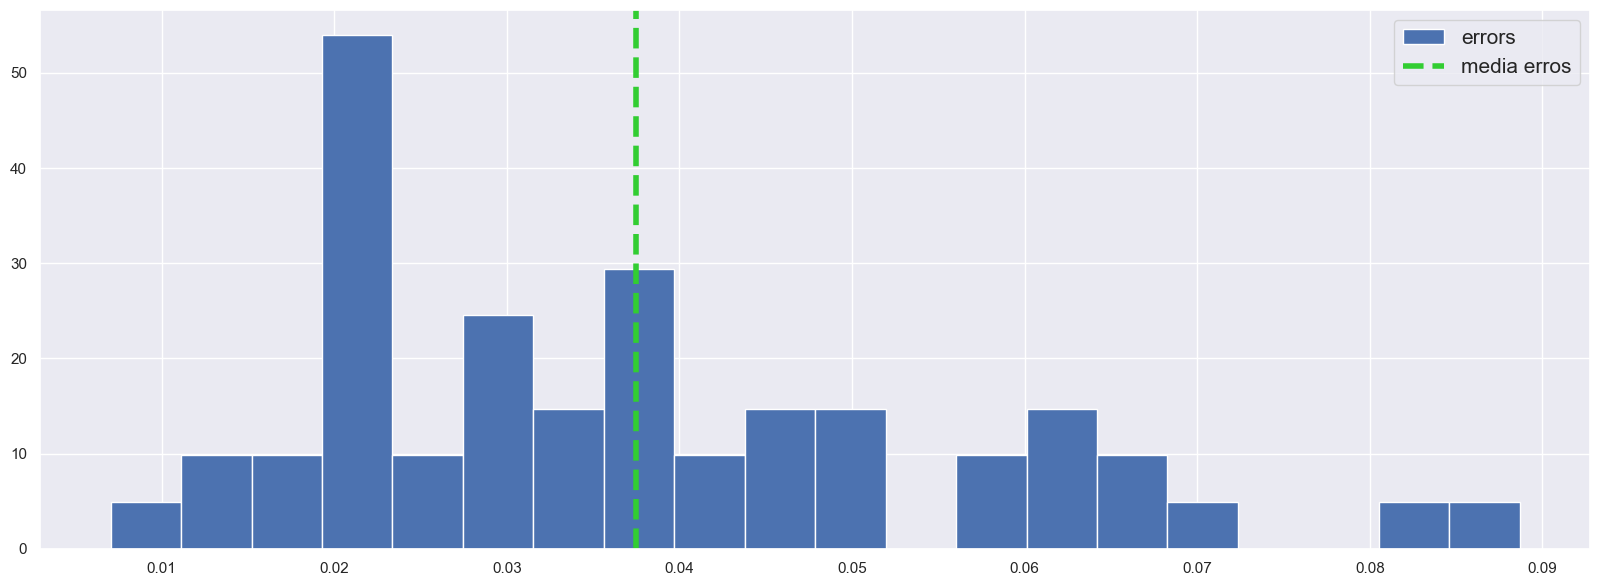

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


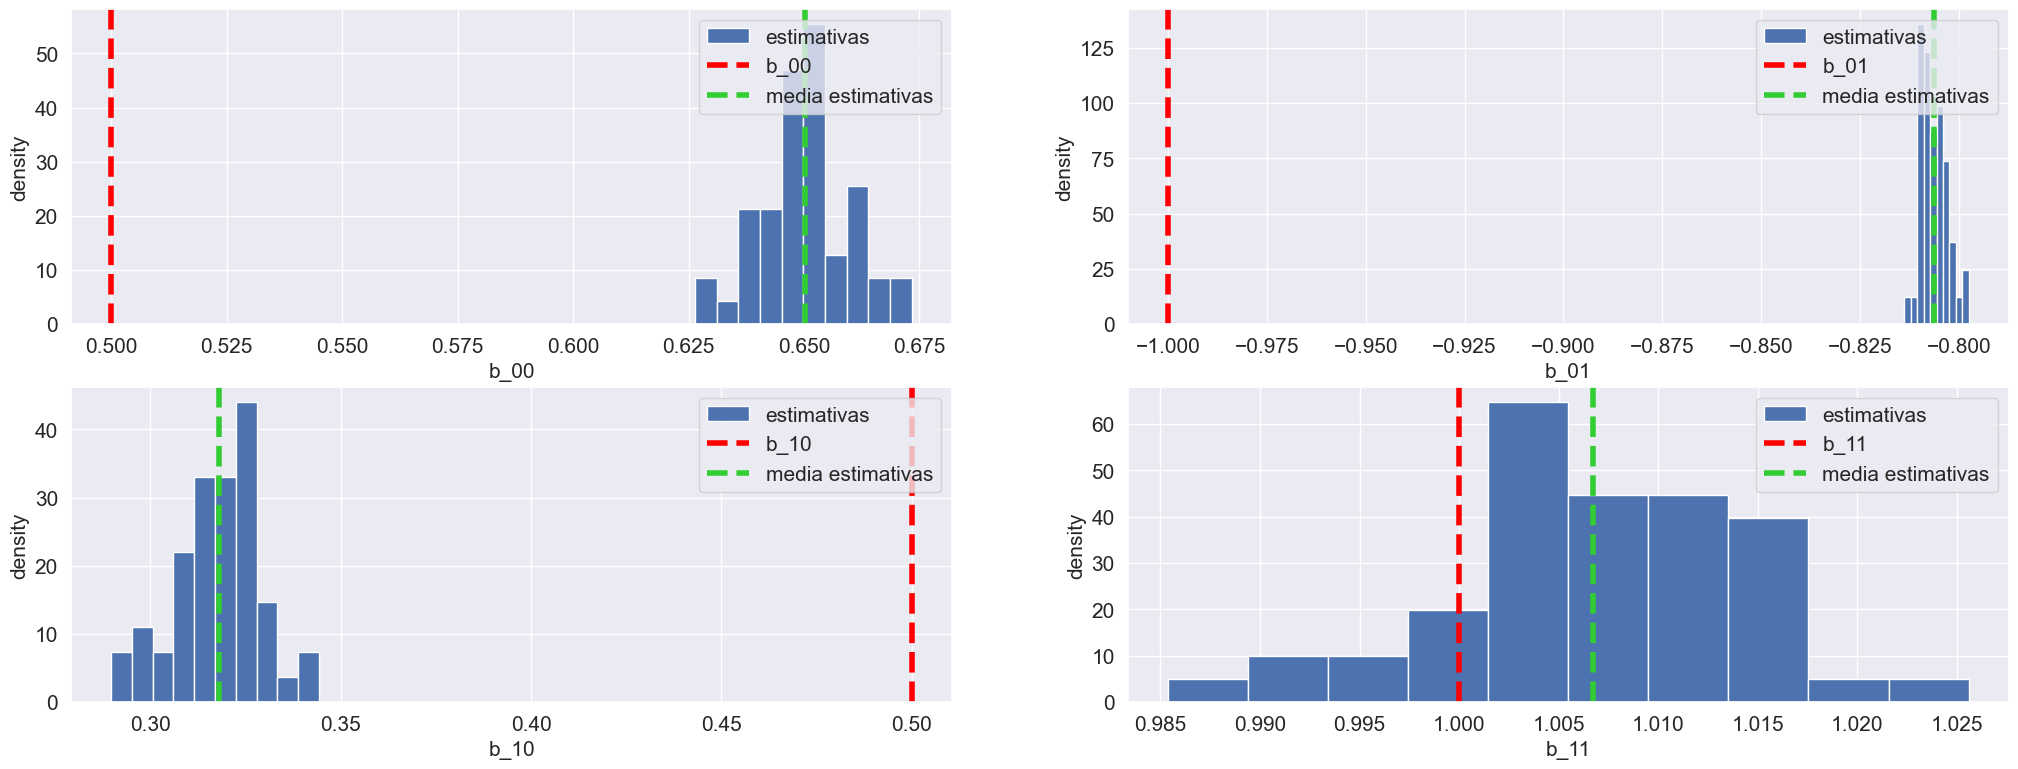

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.19
Max error: 0.21
Min error: 0.18
####################################################################################################


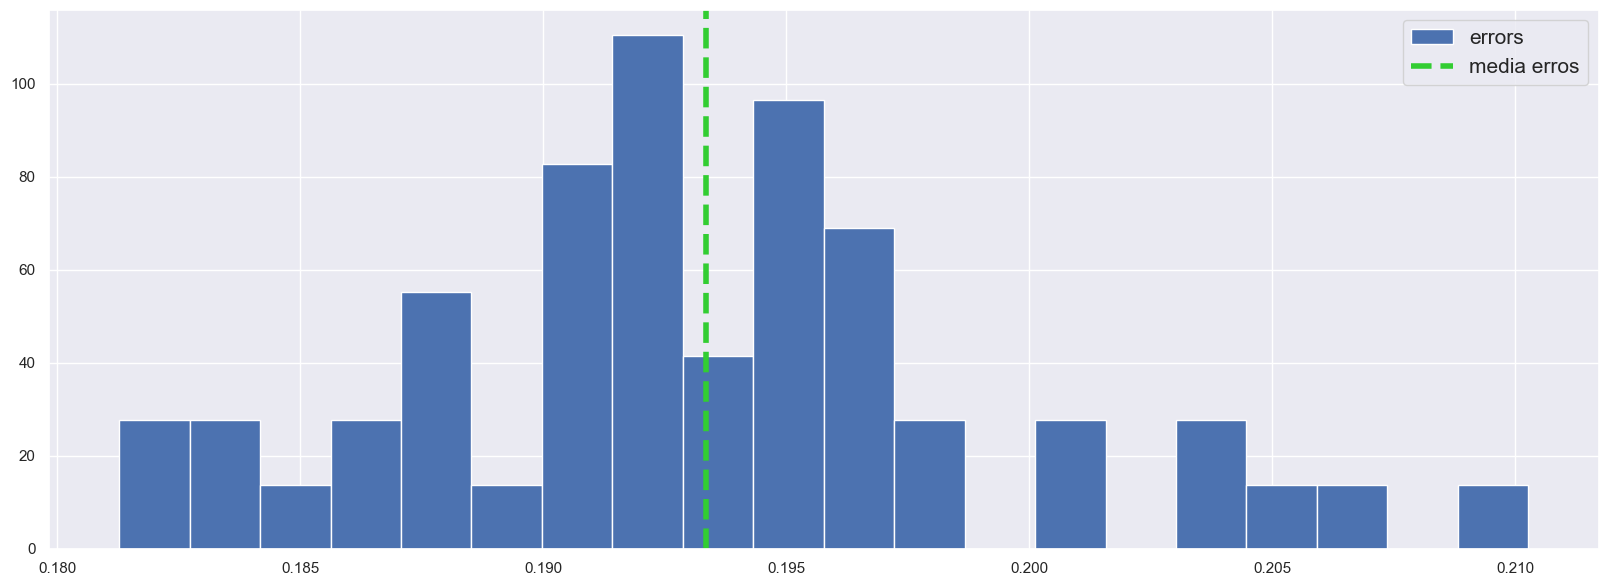

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## iv.

In [ ]:
test_case='iv'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


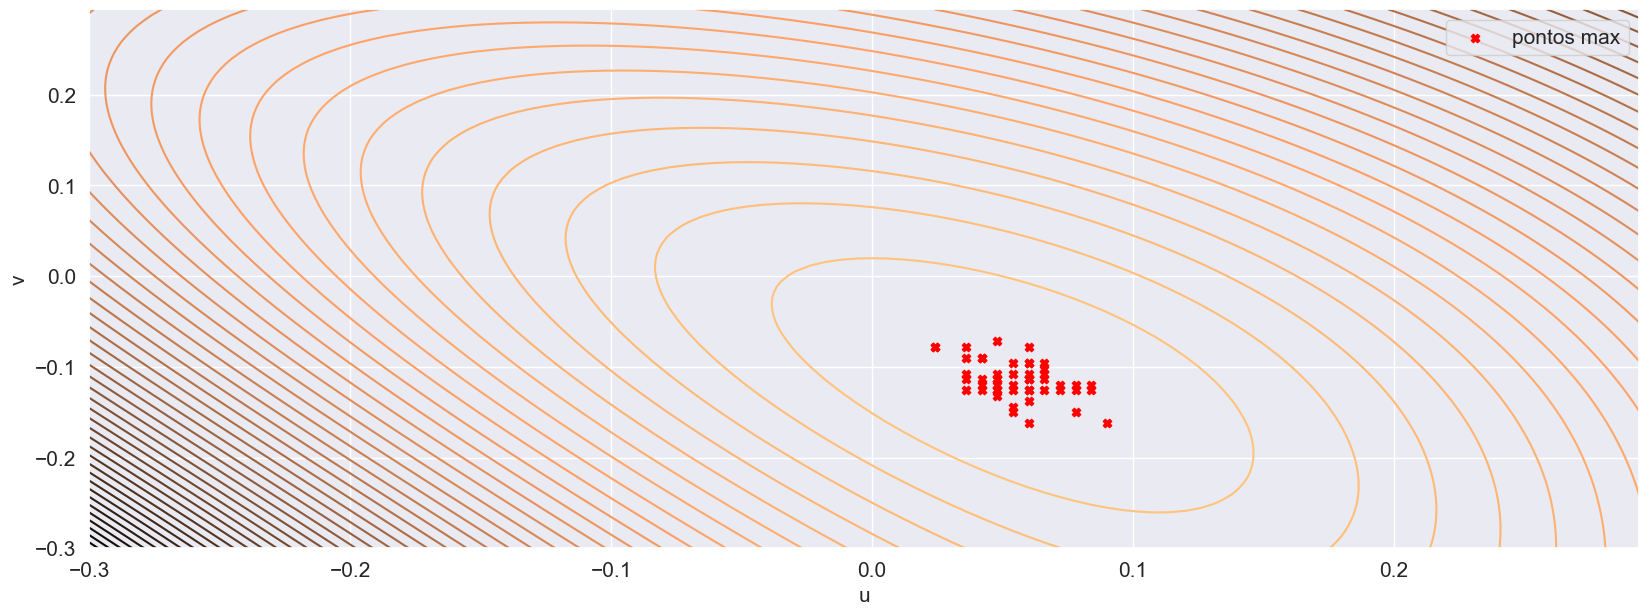

In [ ]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


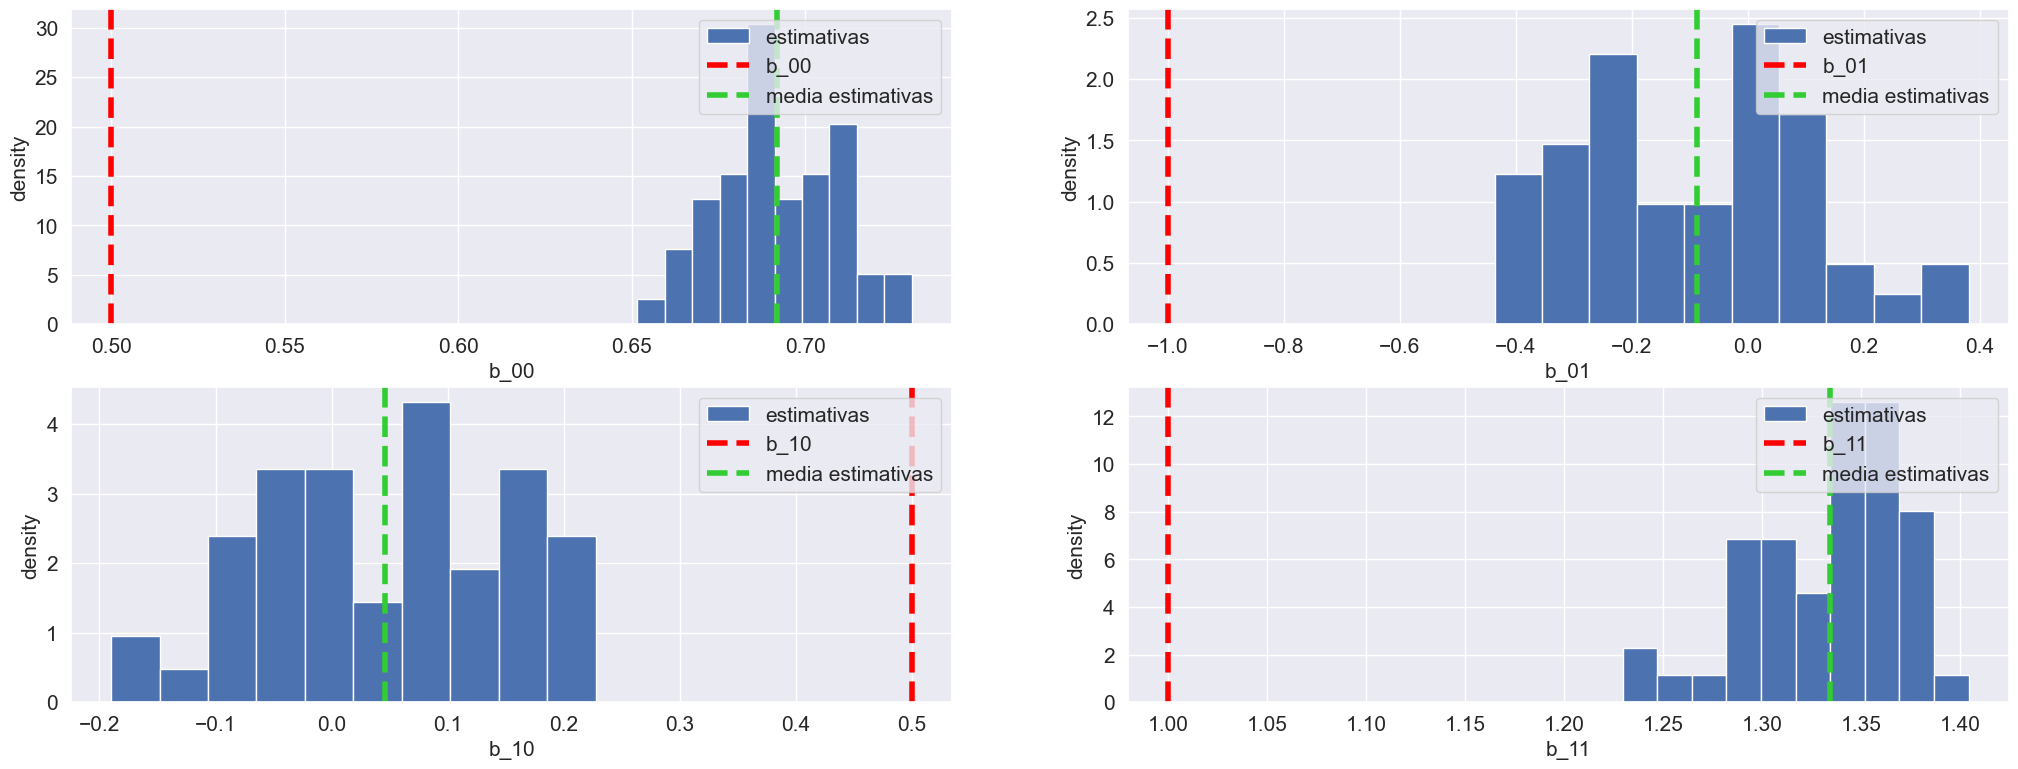

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.69
Max error: 1.0
Min error: 0.45
####################################################################################################


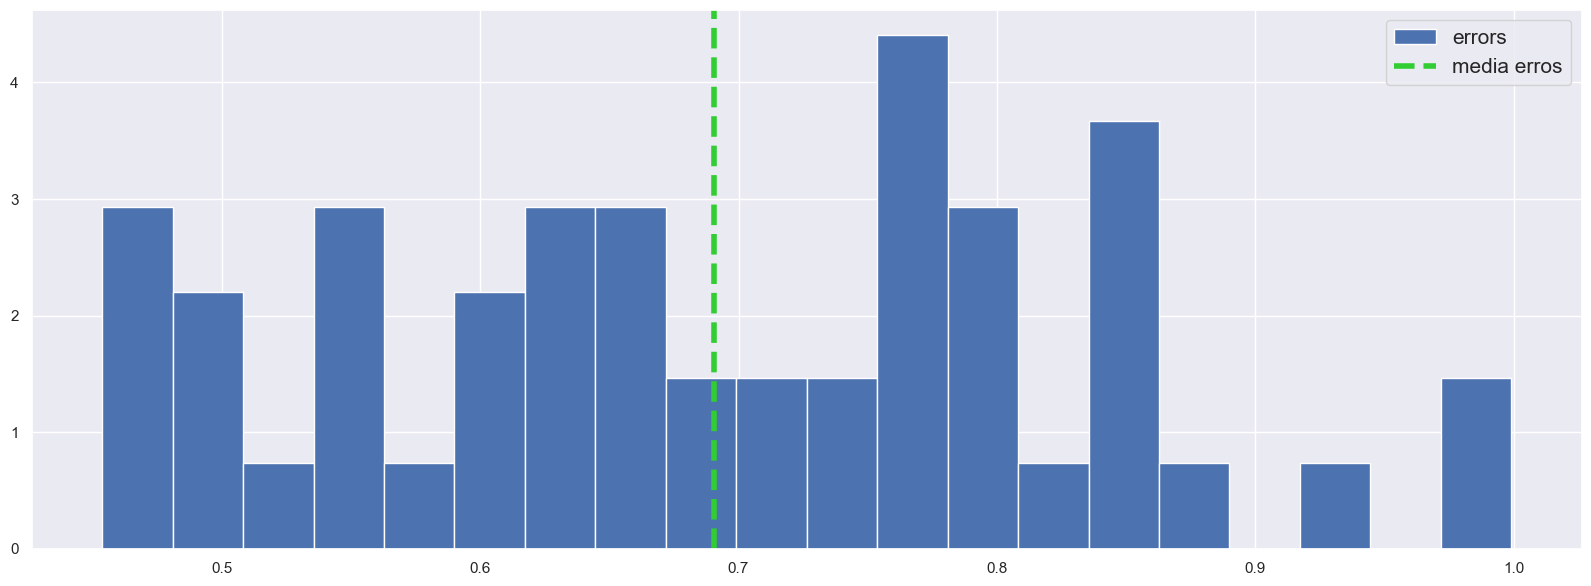

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


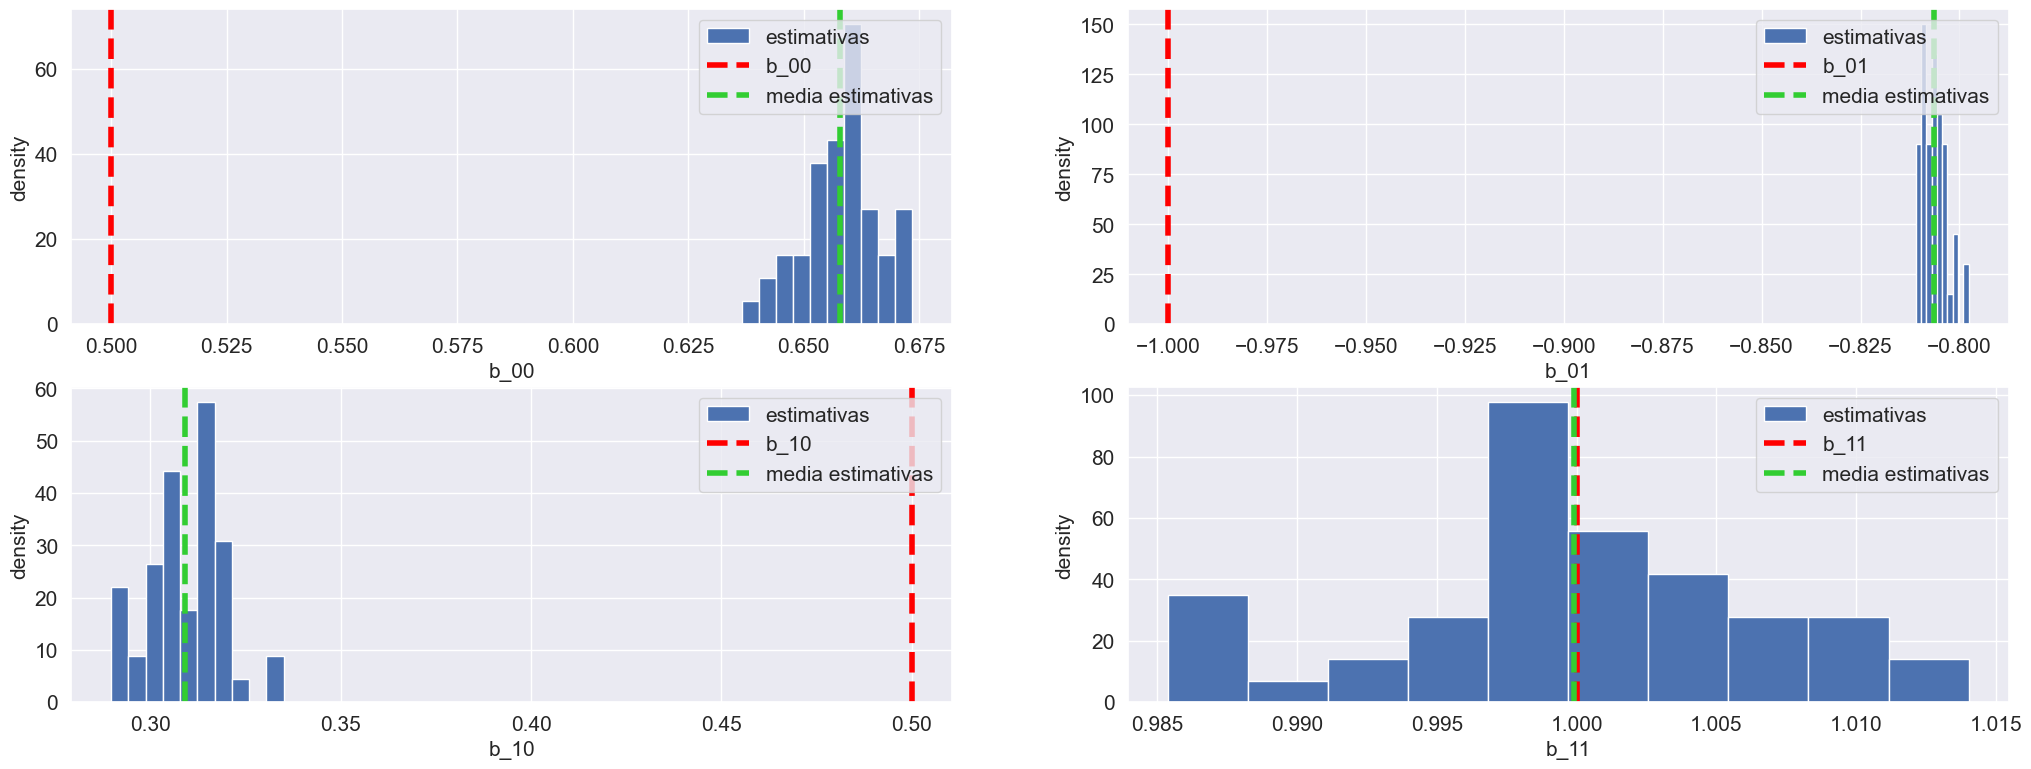

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.2
Max error: 0.21
Min error: 0.19
####################################################################################################


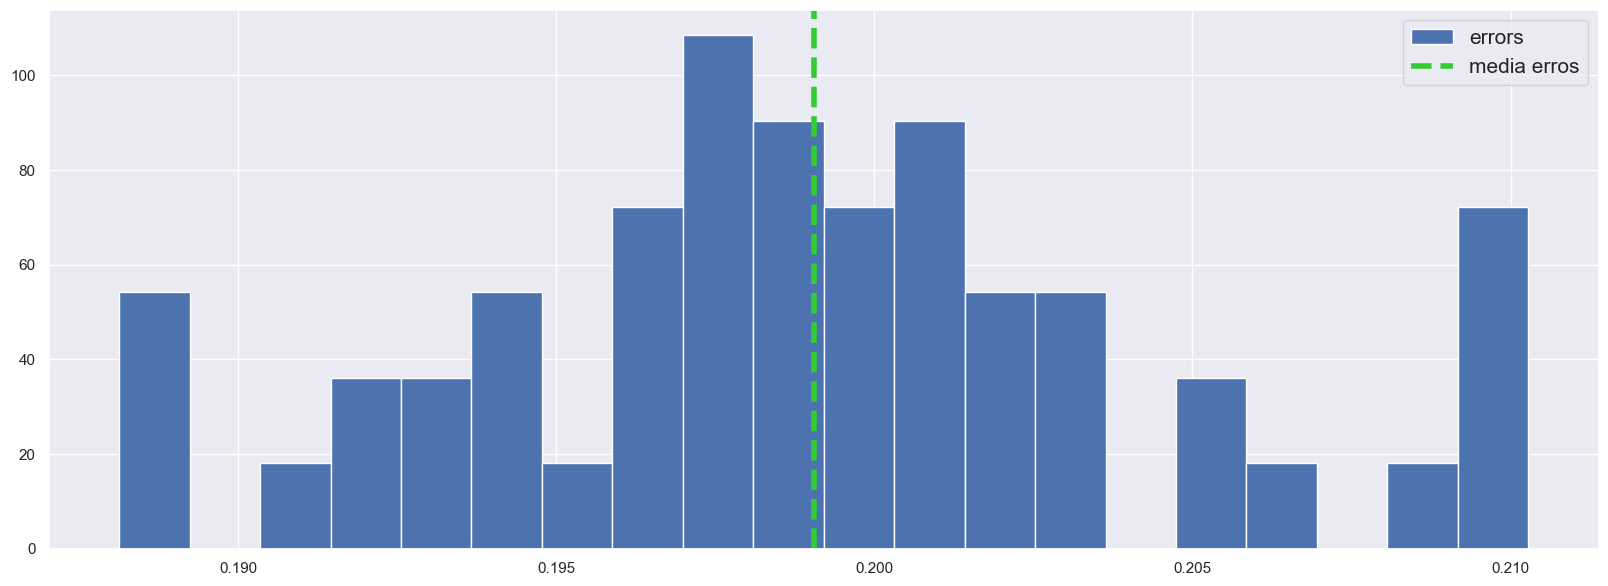

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## v.

In [ ]:
test_case='v'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


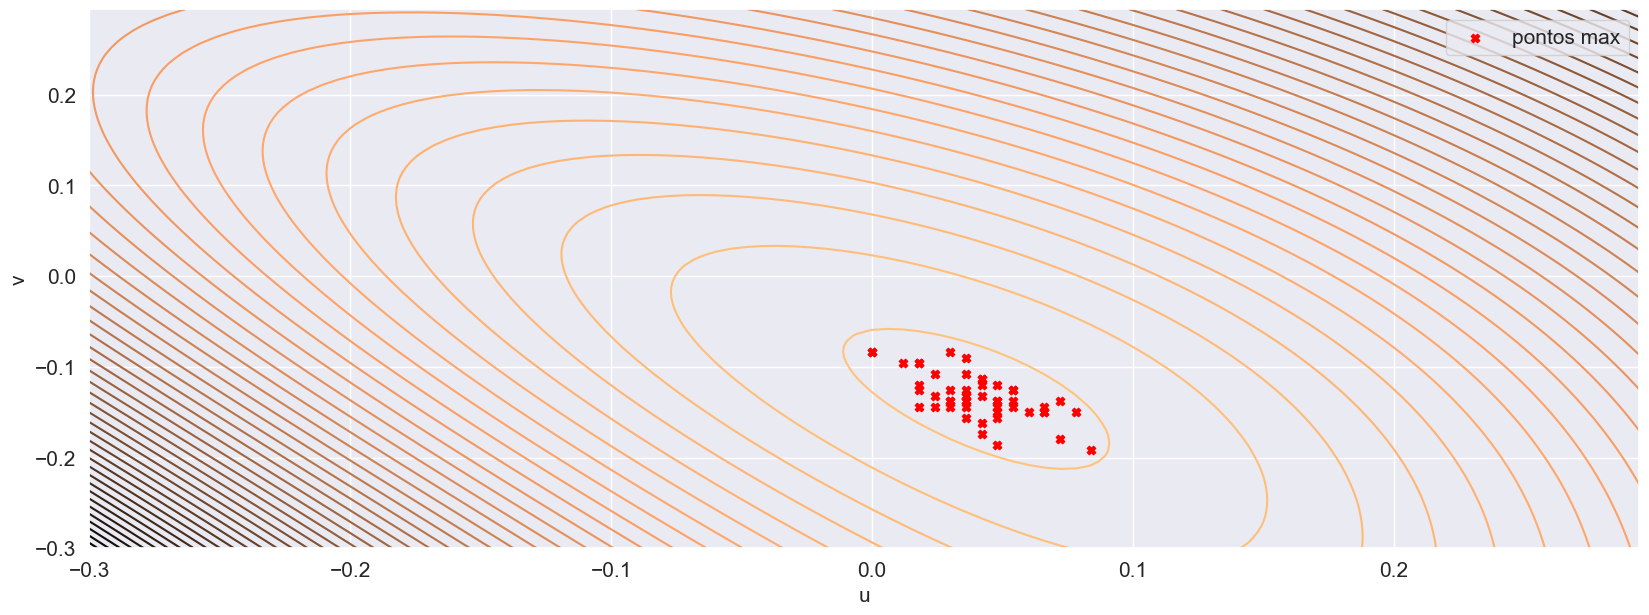

In [ ]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


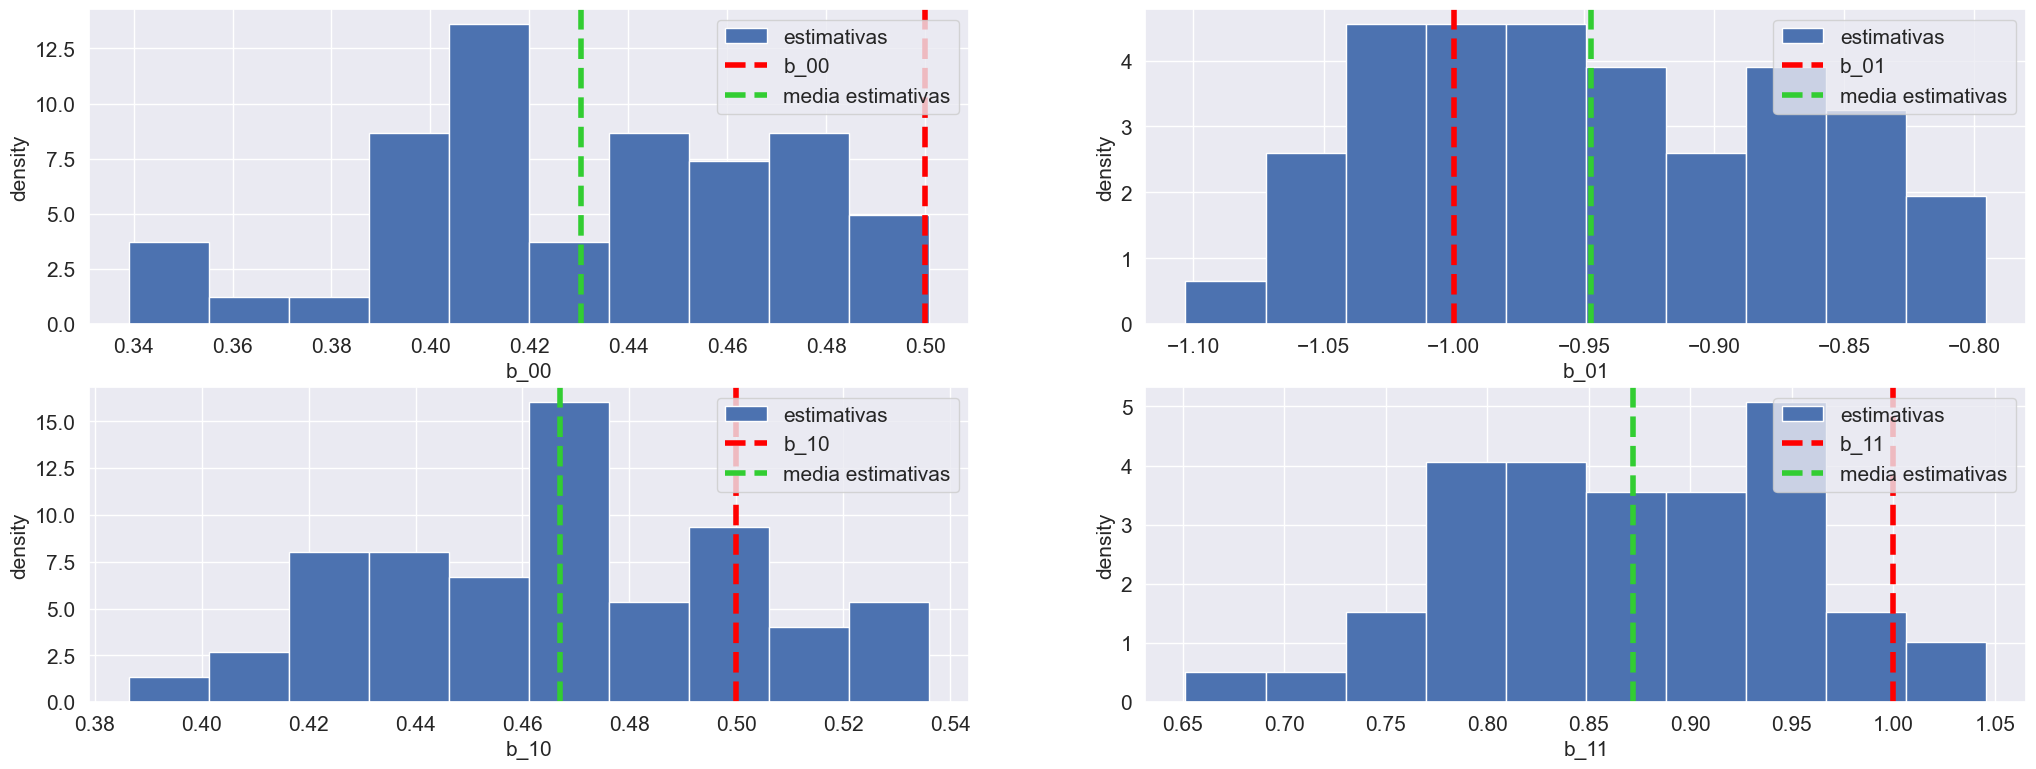

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.12
Max error: 0.25
Min error: 0.06
####################################################################################################


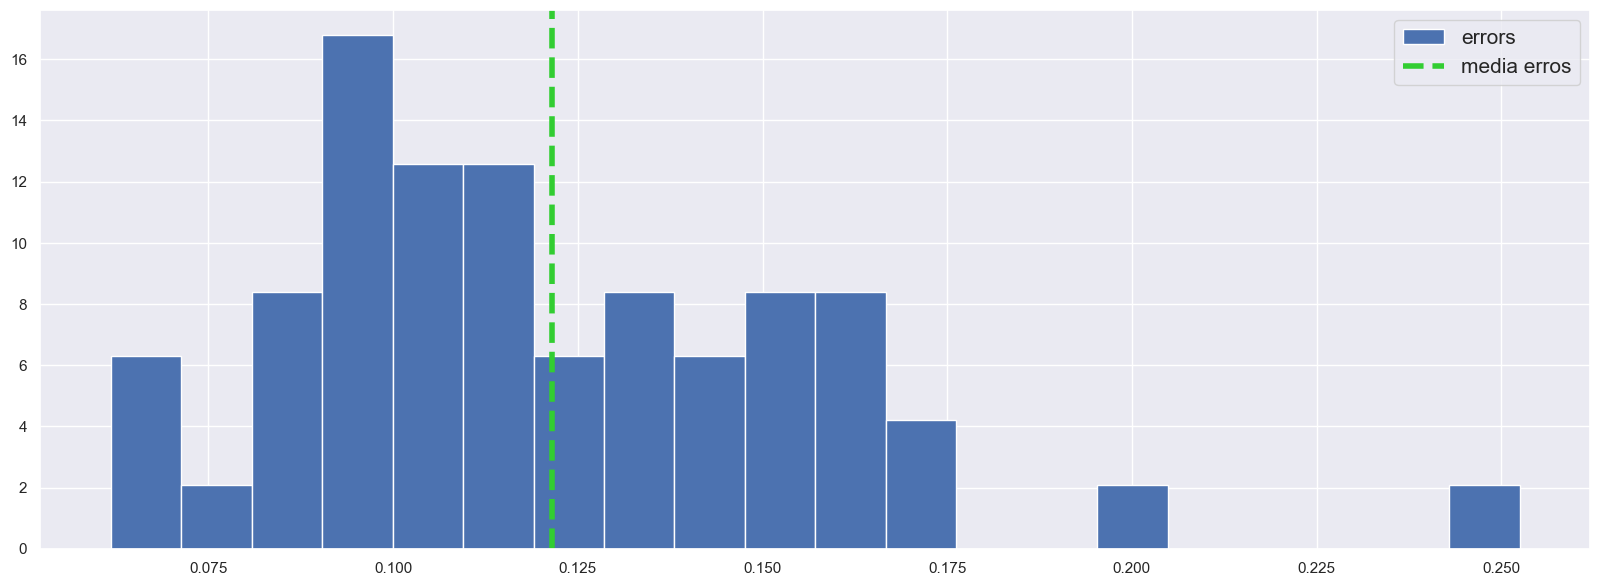

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


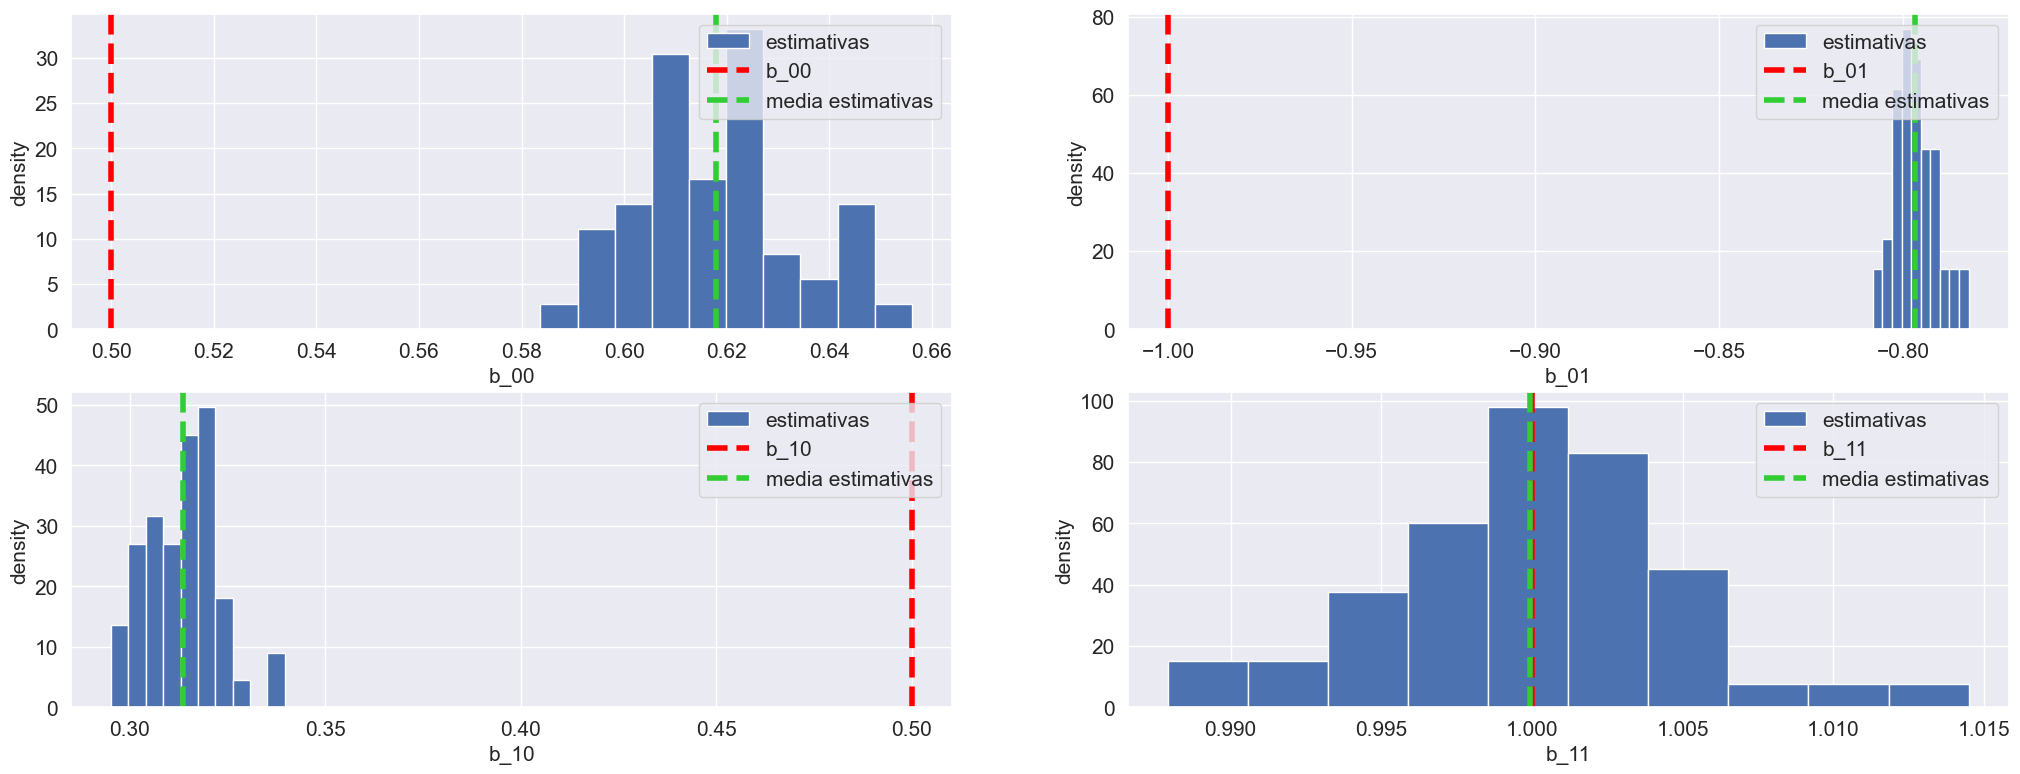

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.19
Max error: 0.2
Min error: 0.18
####################################################################################################


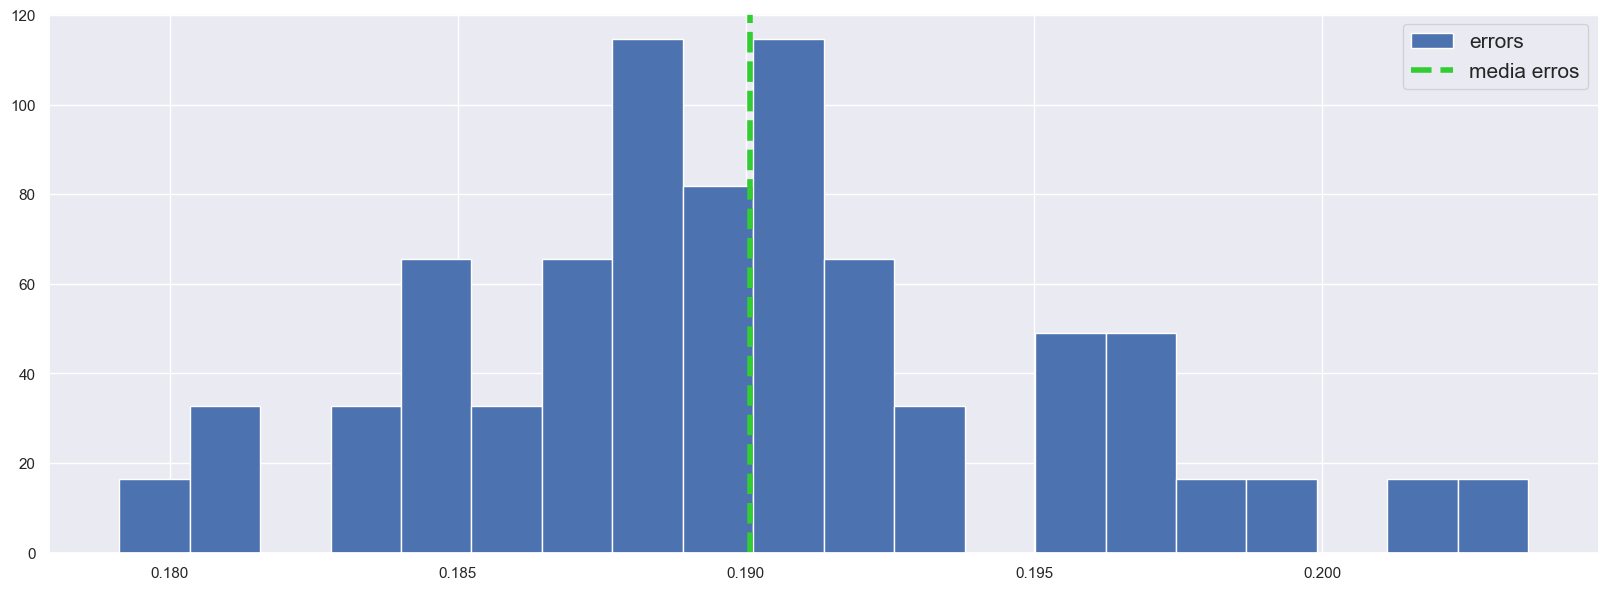

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## vii.

In [ ]:
test_case='vii'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


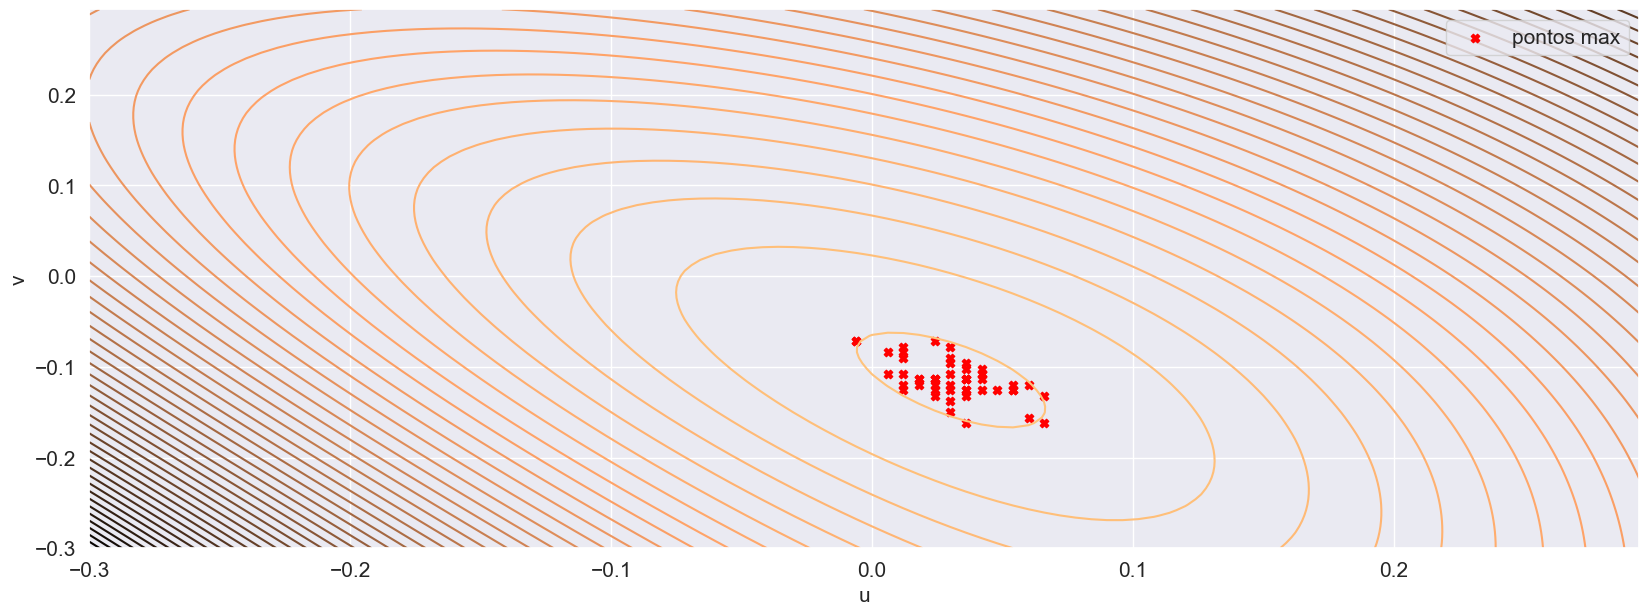

In [ ]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


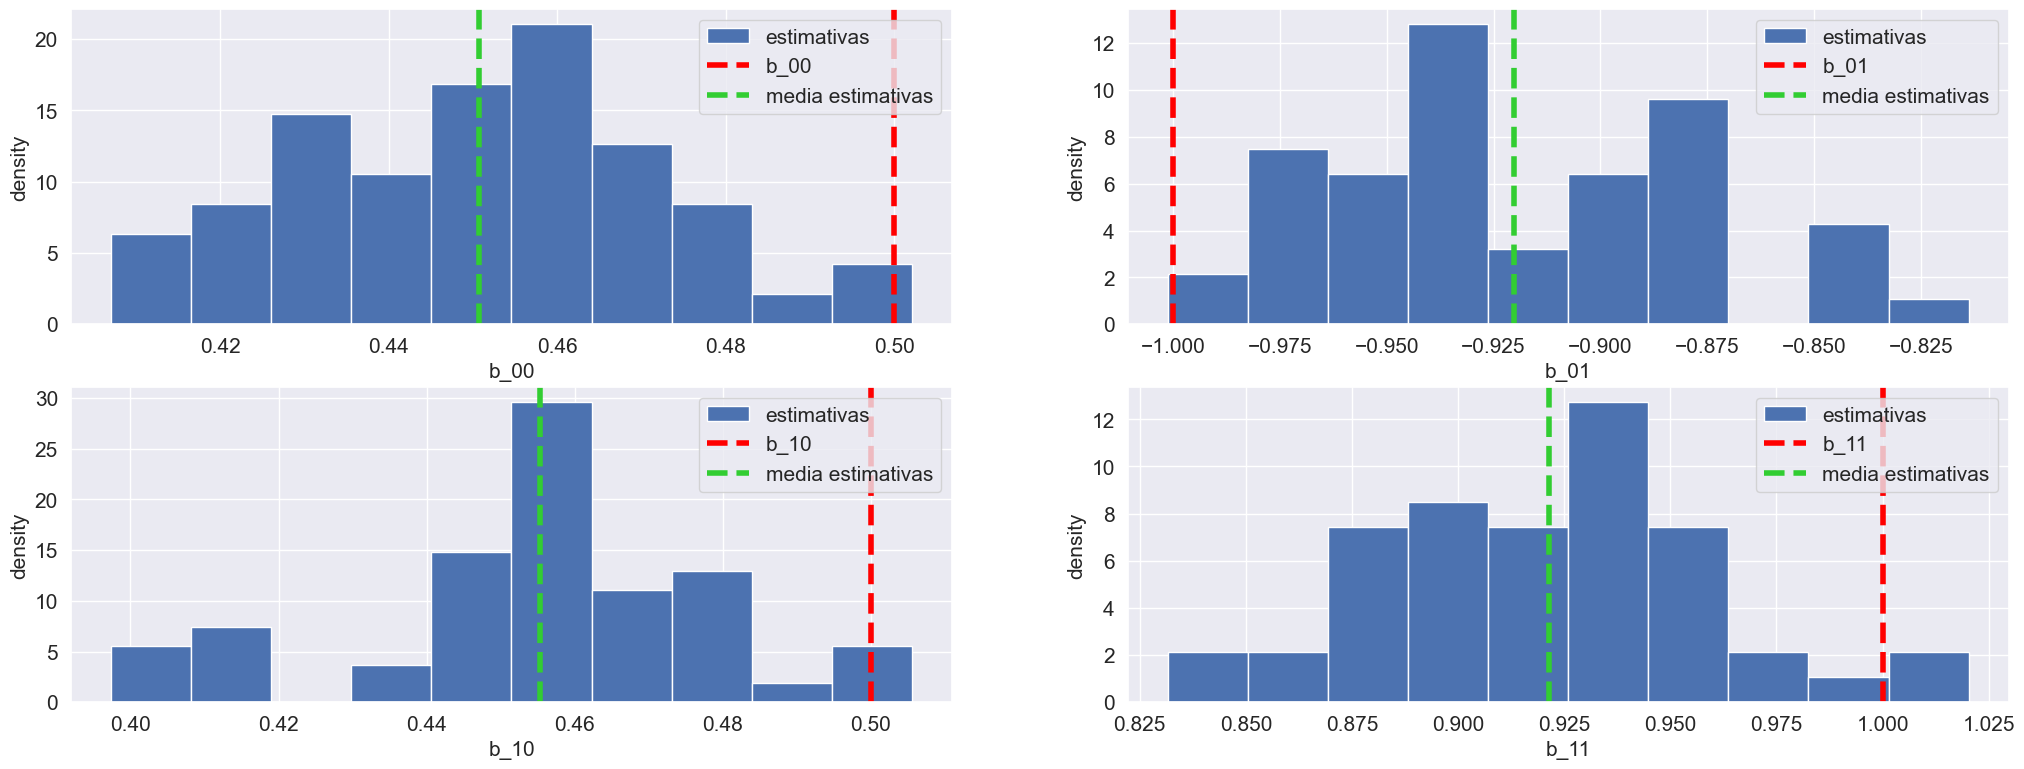

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.09
Max error: 0.14
Min error: 0.05
####################################################################################################


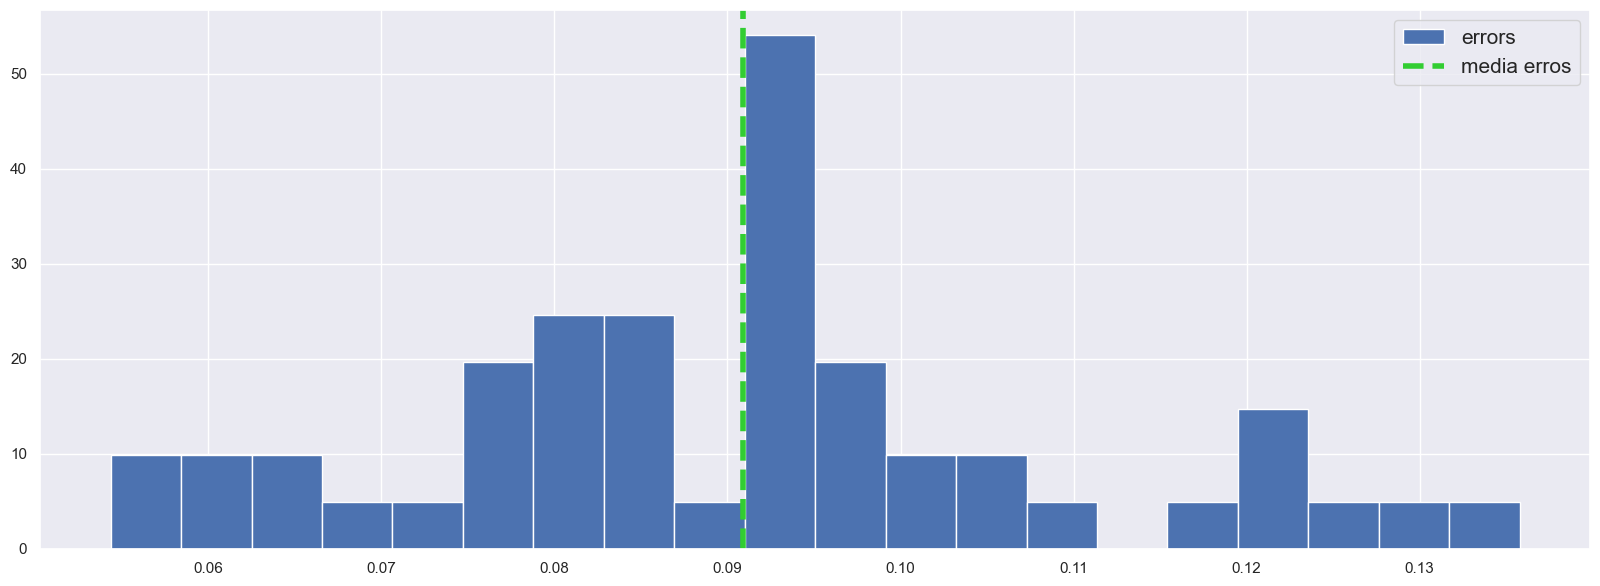

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


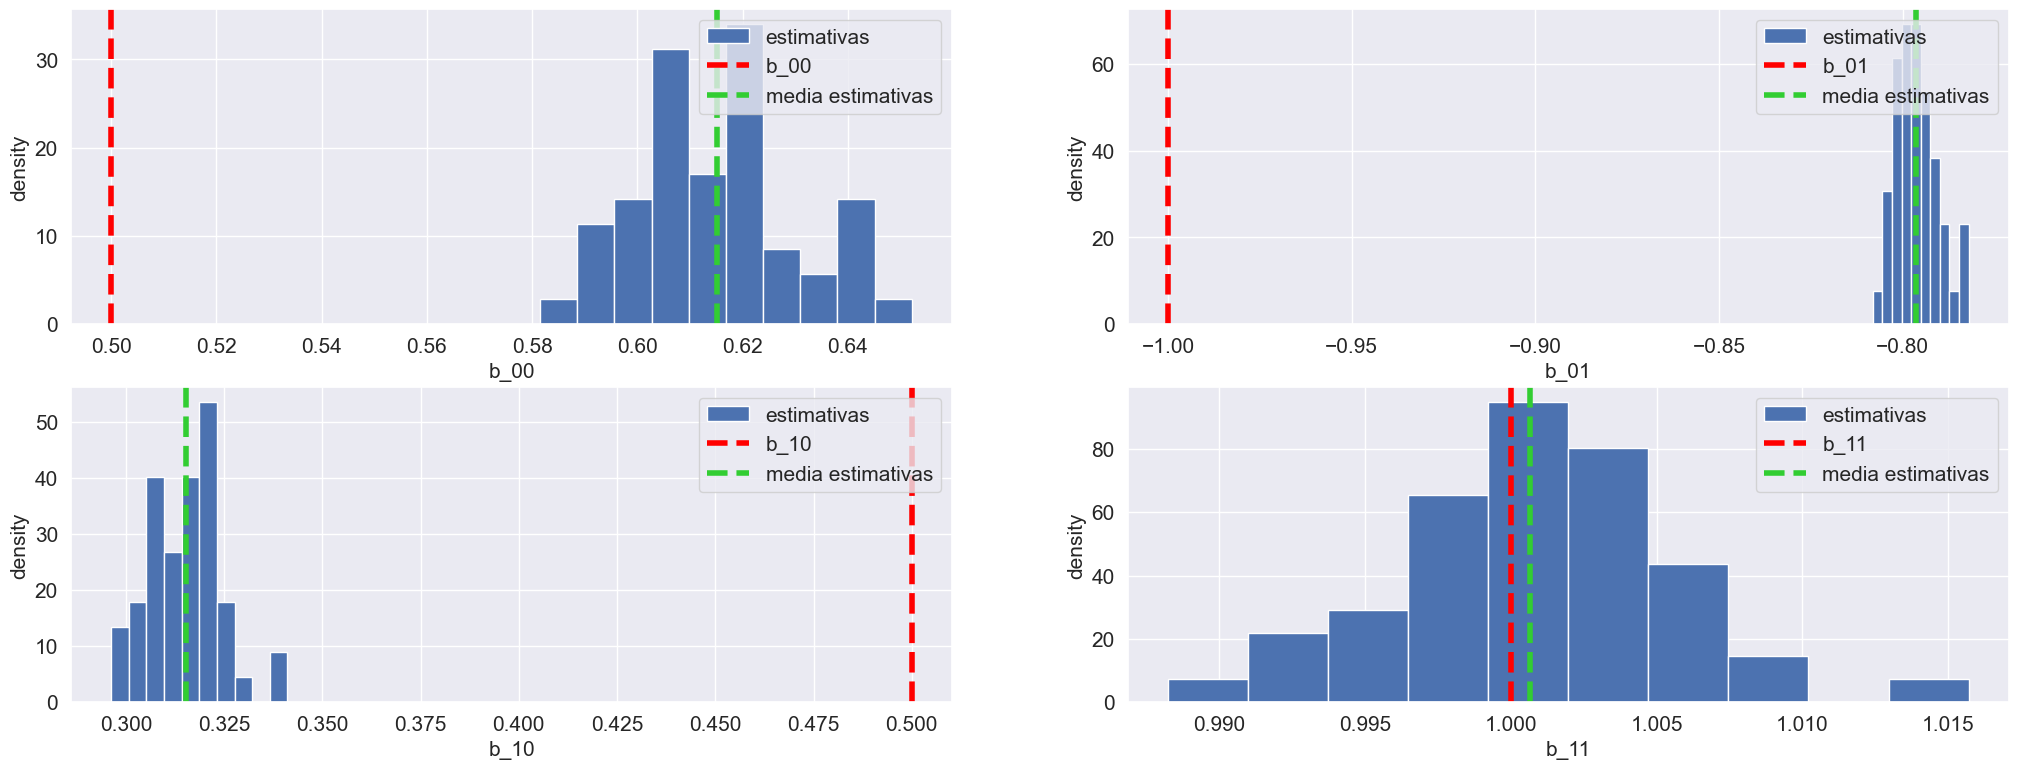

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.19
Max error: 0.2
Min error: 0.18
####################################################################################################


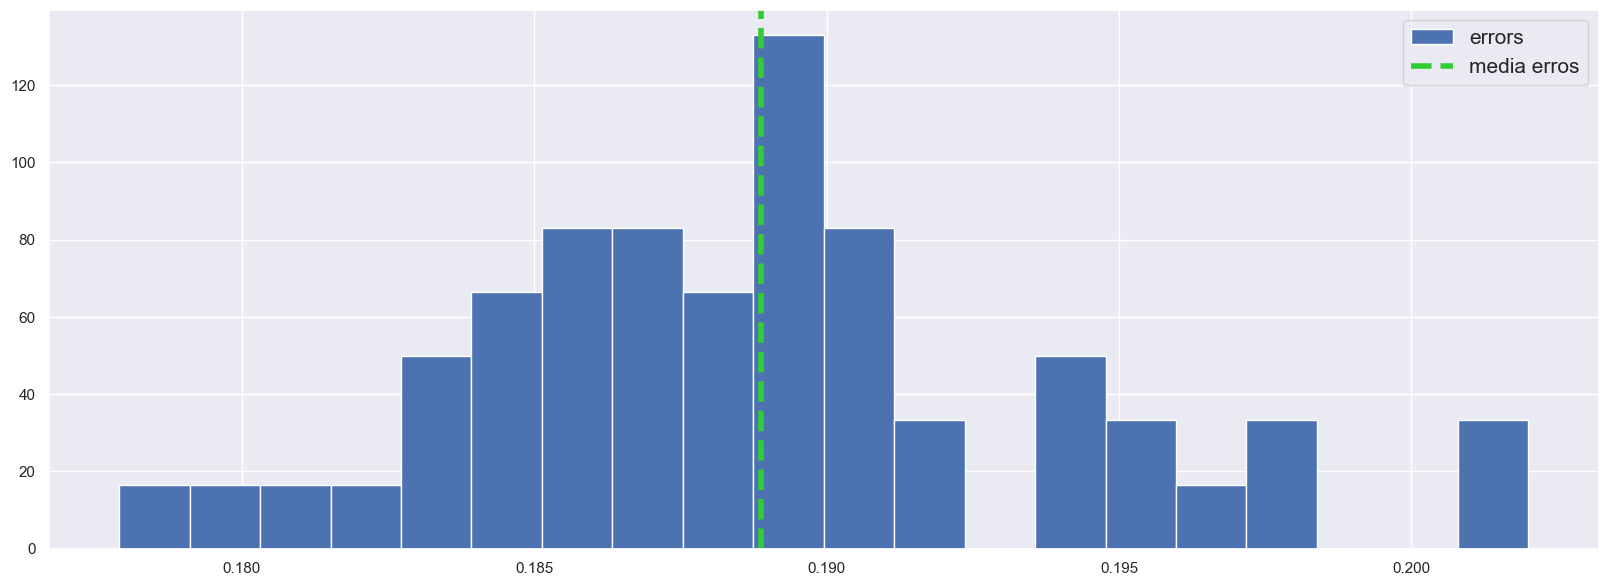

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## viii.

In [ ]:
test_case='viii'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


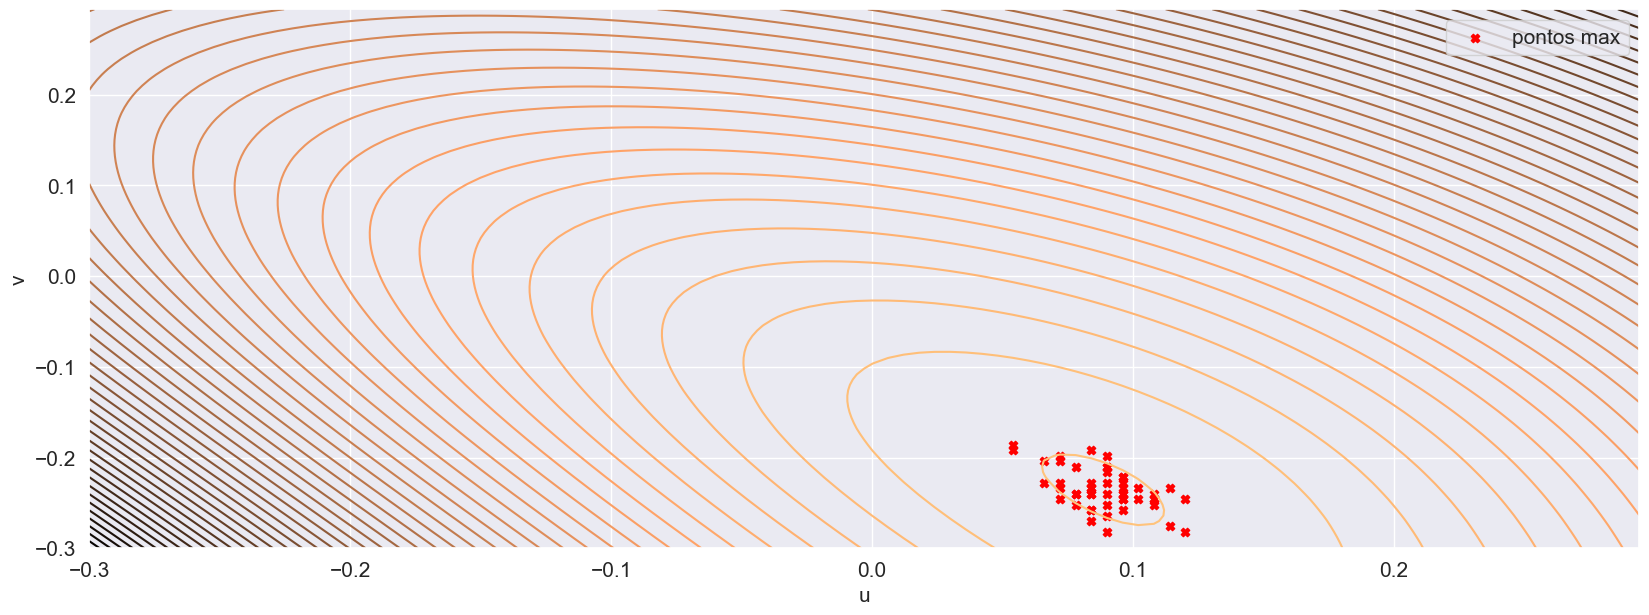

In [ ]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


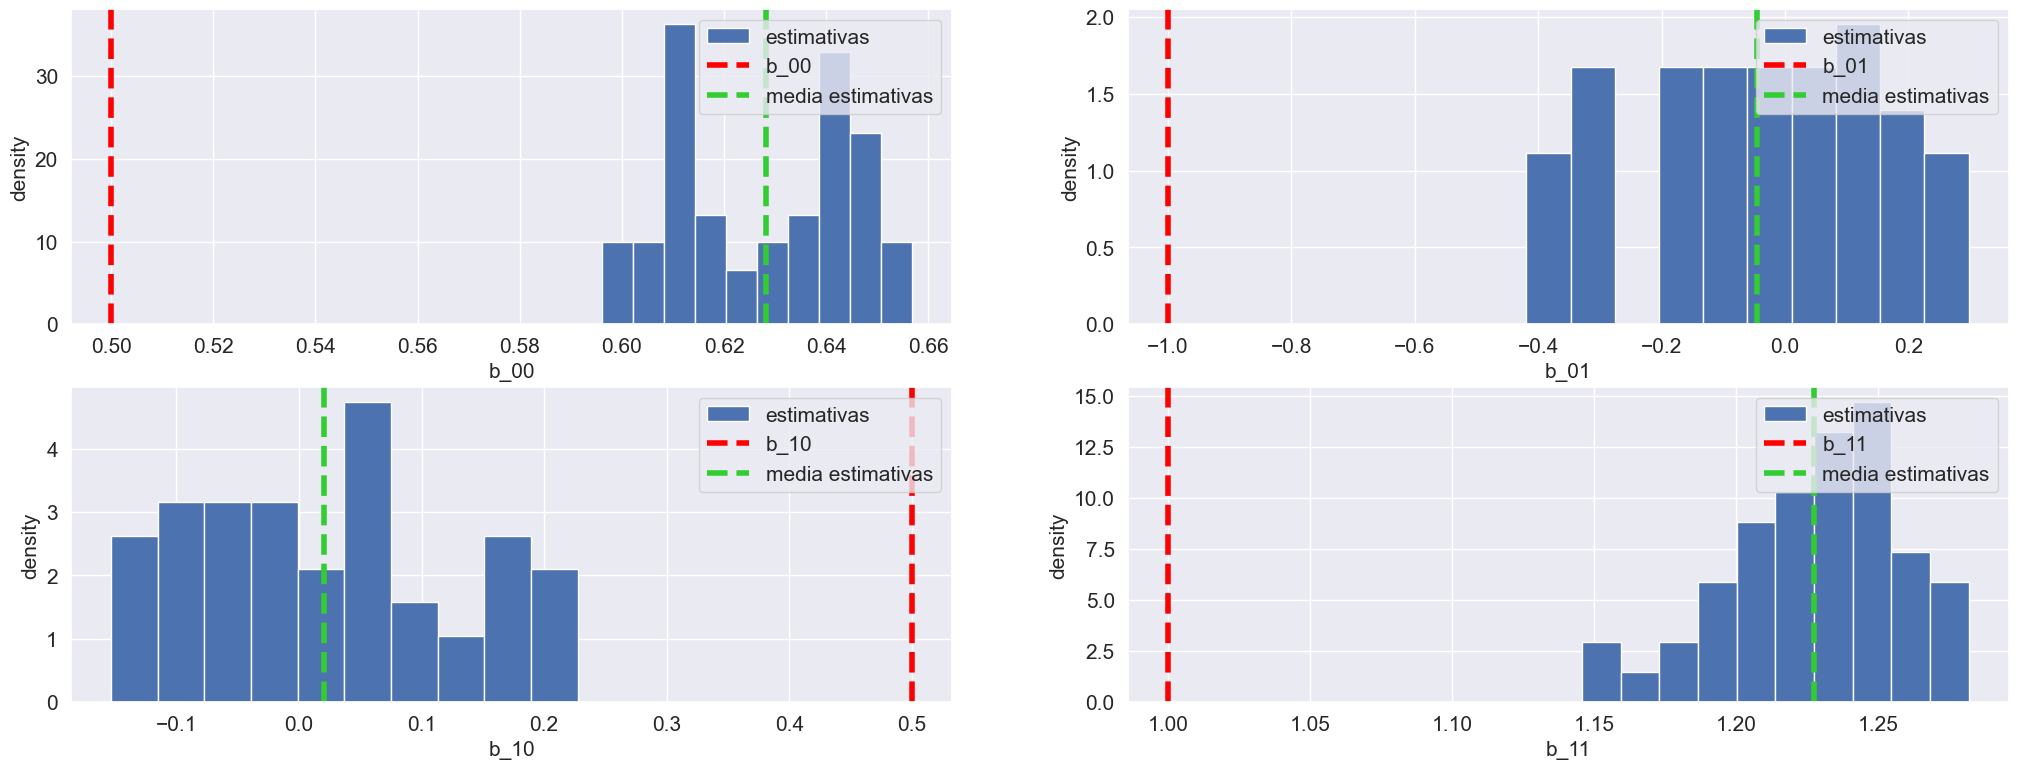

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.7
Max error: 0.93
Min error: 0.43
####################################################################################################


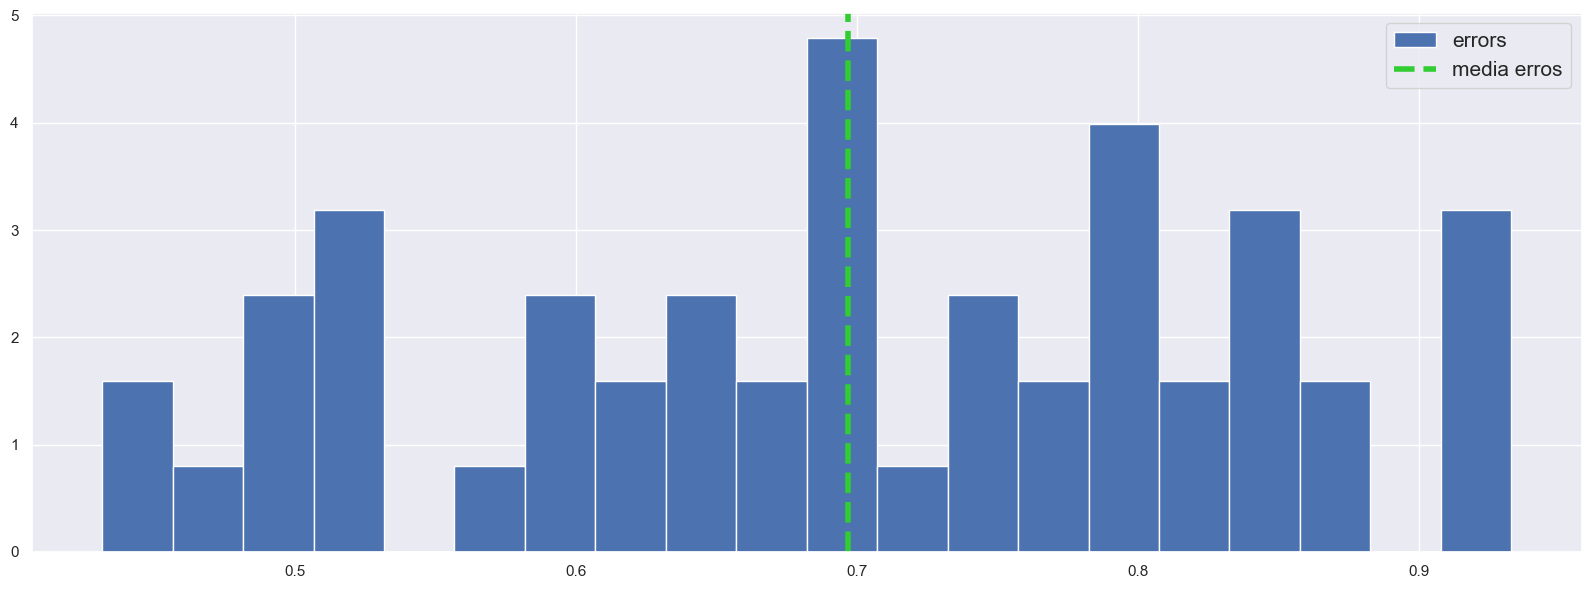

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


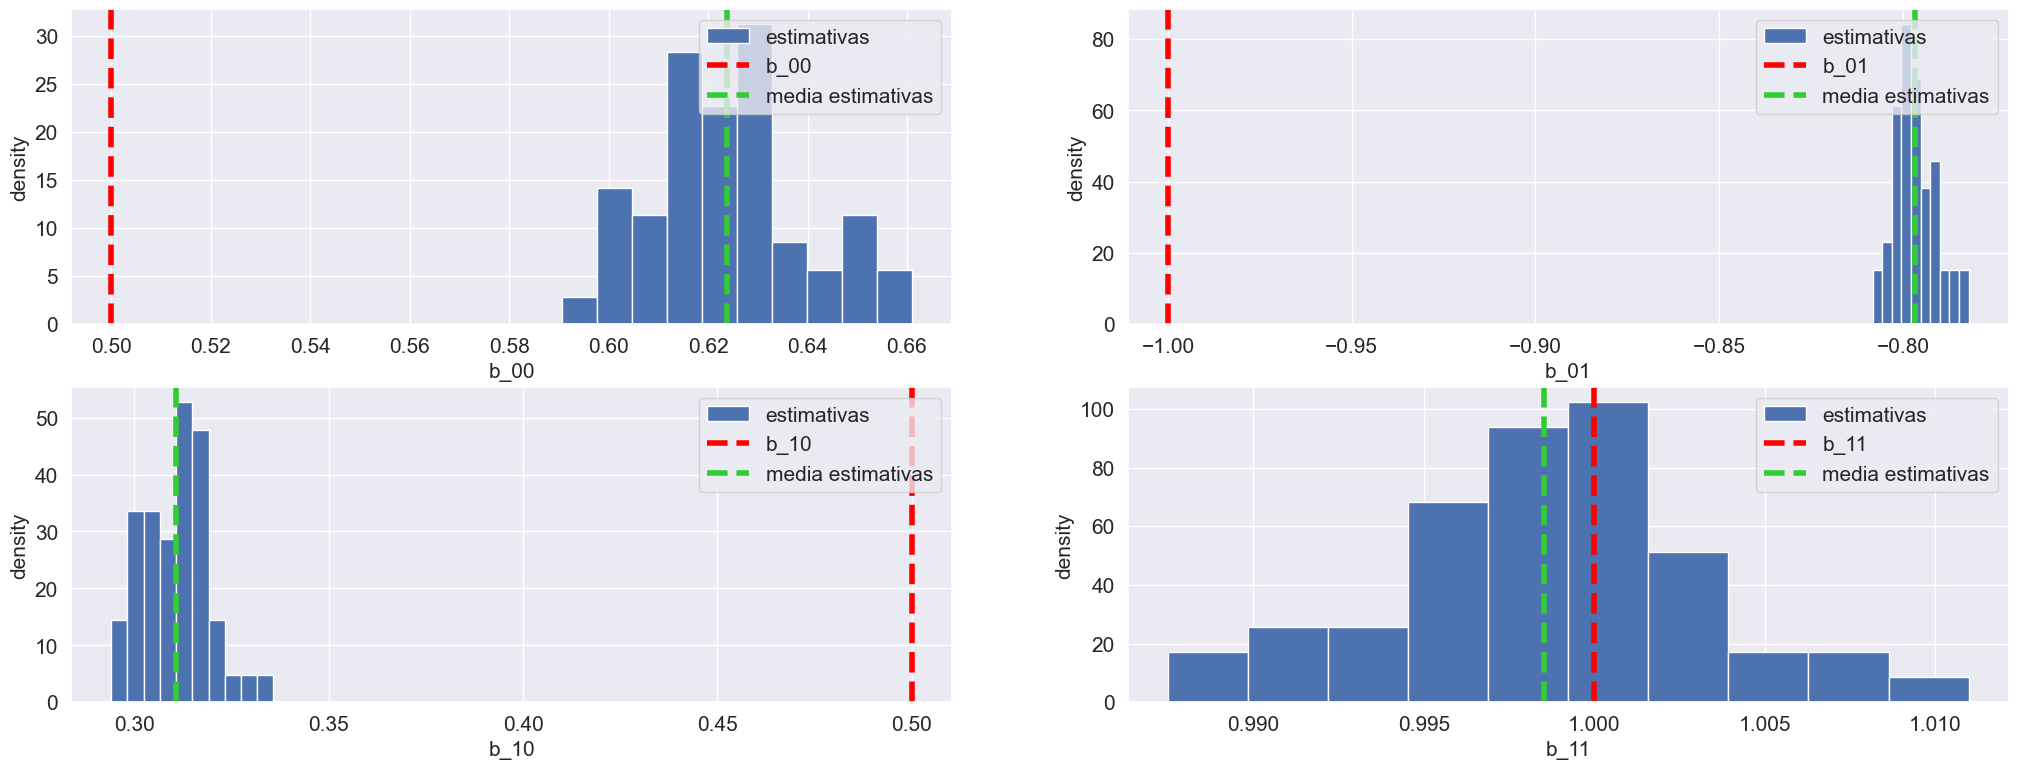

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.19
Max error: 0.21
Min error: 0.18
####################################################################################################


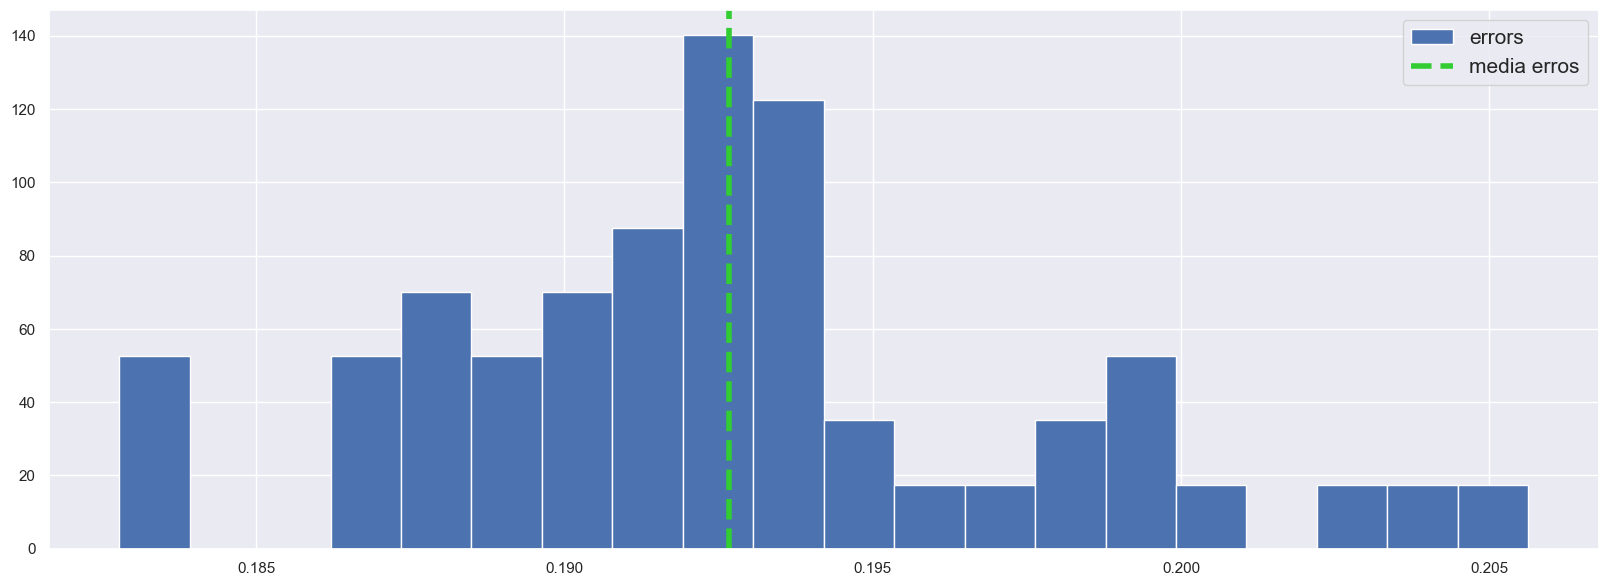

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## ix.

In [ ]:
test_case='ix'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


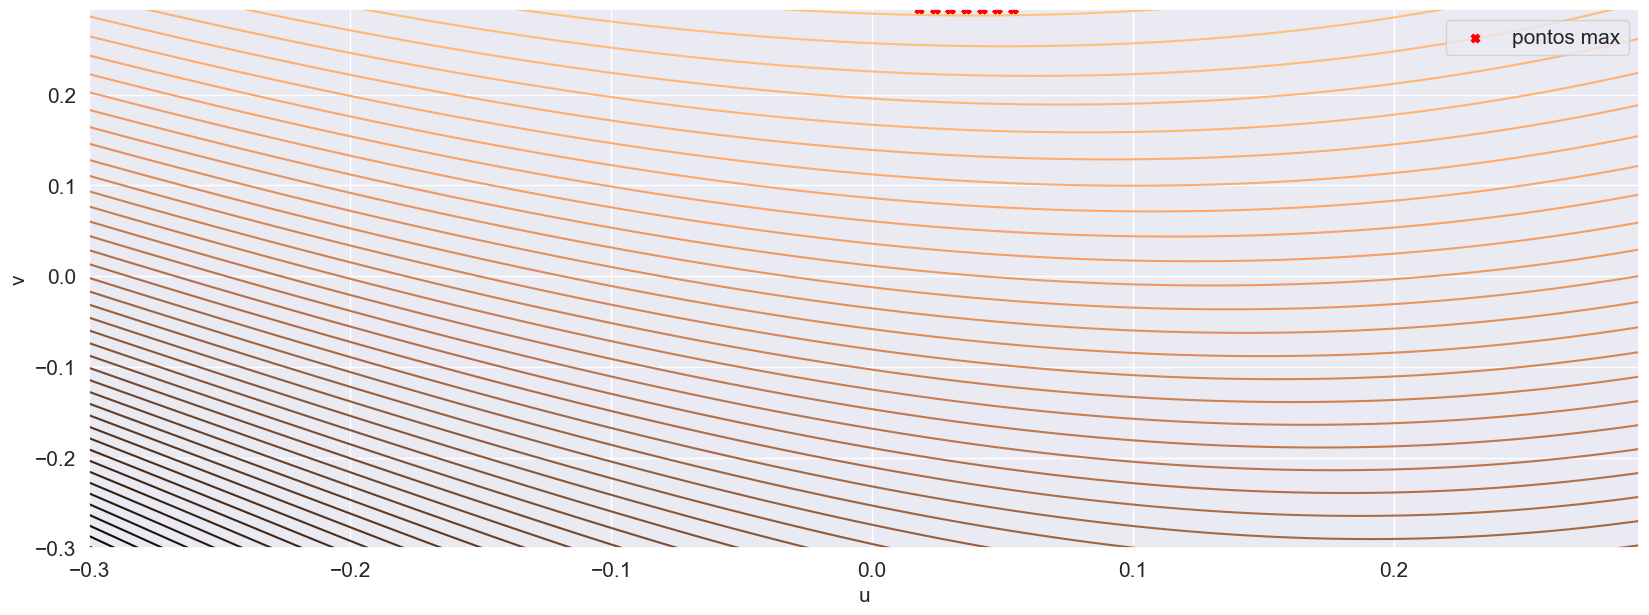

In [ ]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


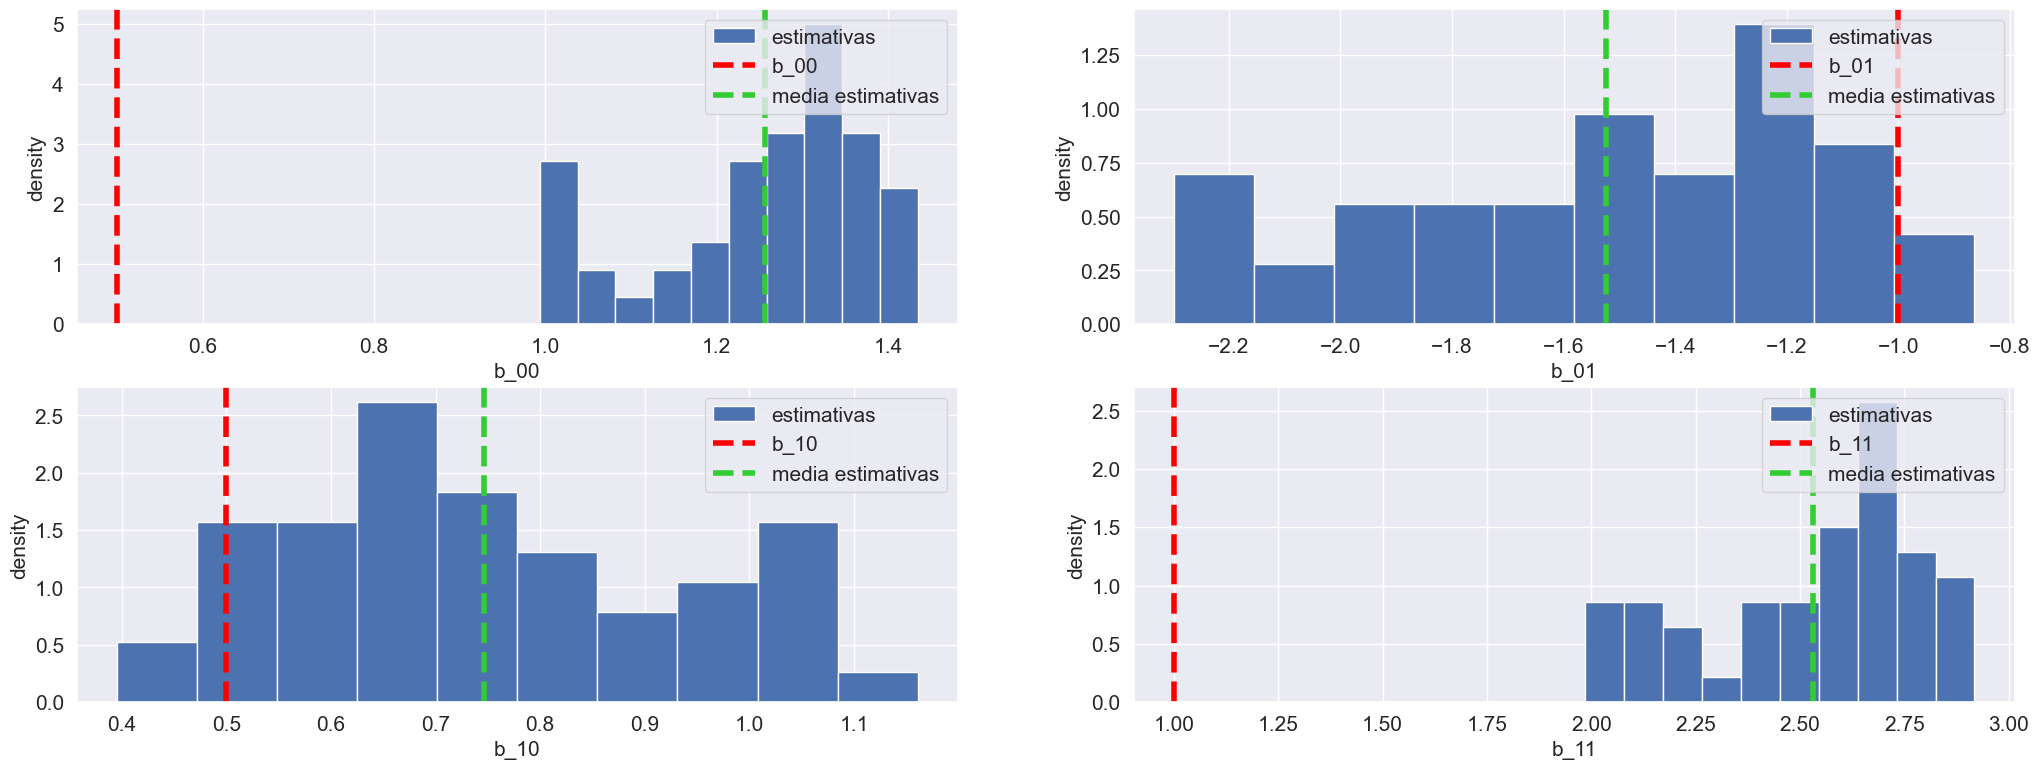

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 1.18
Max error: 1.35
Min error: 1.05
####################################################################################################


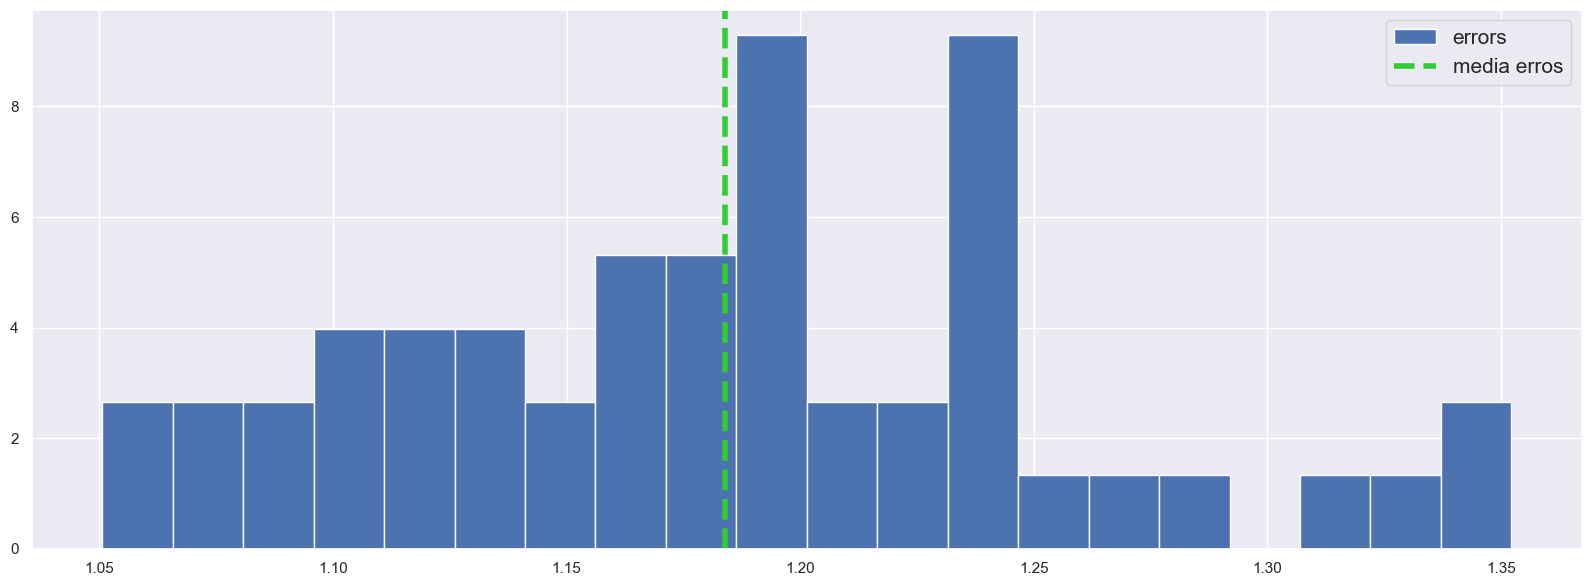

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


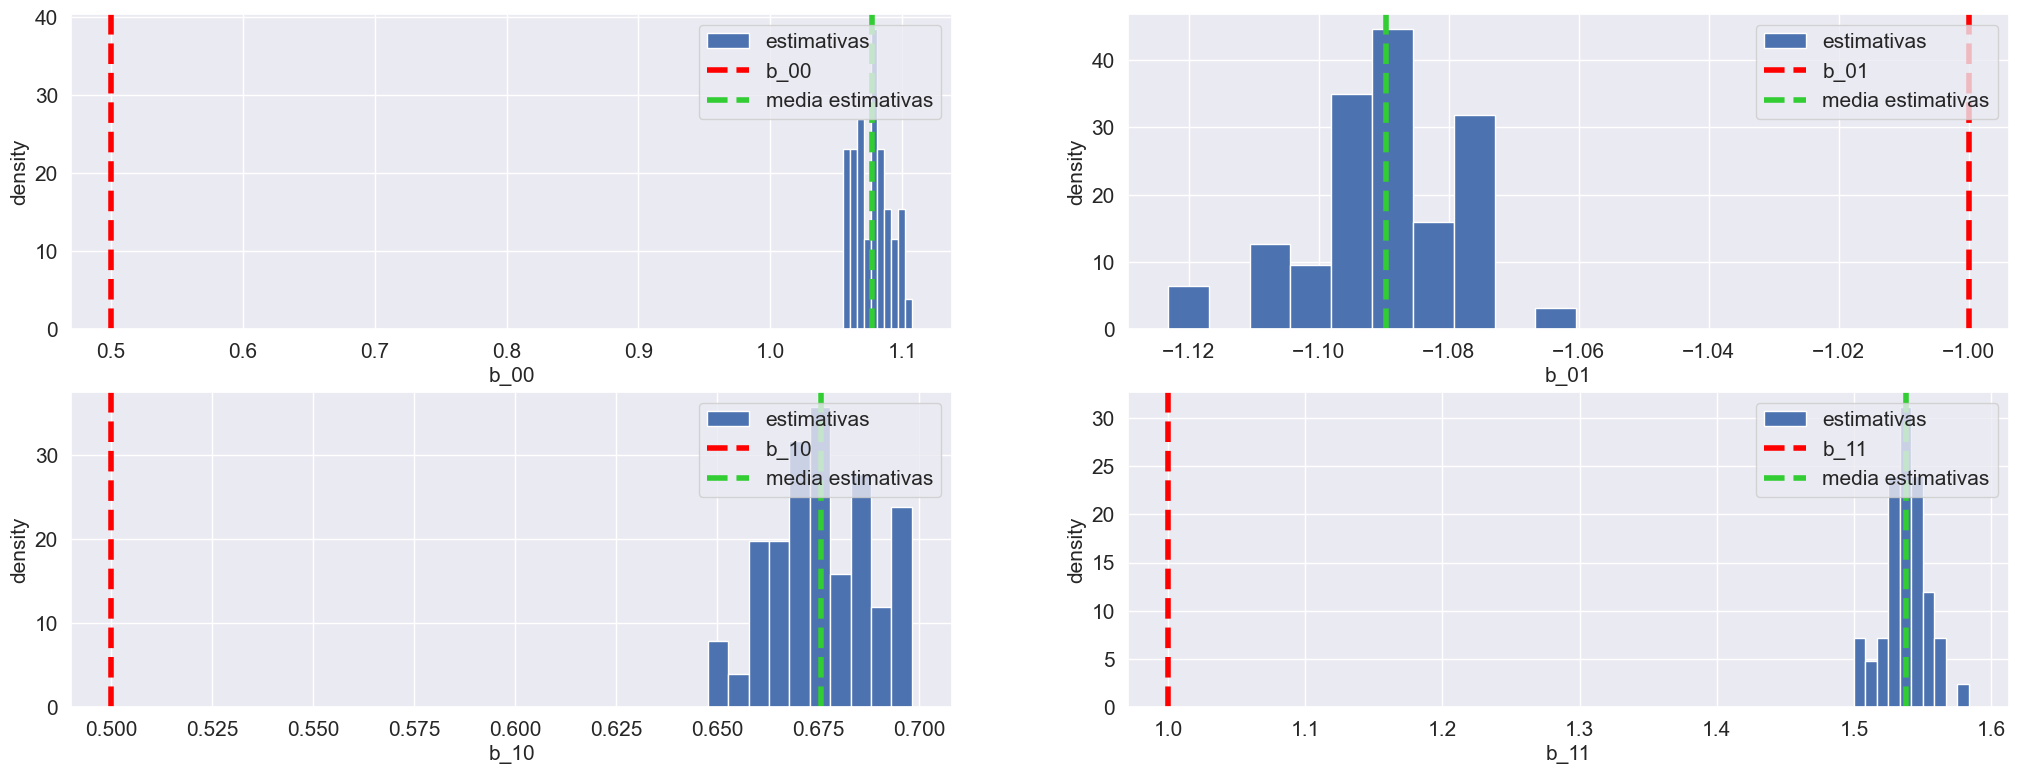

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.51
Max error: 0.54
Min error: 0.49
####################################################################################################


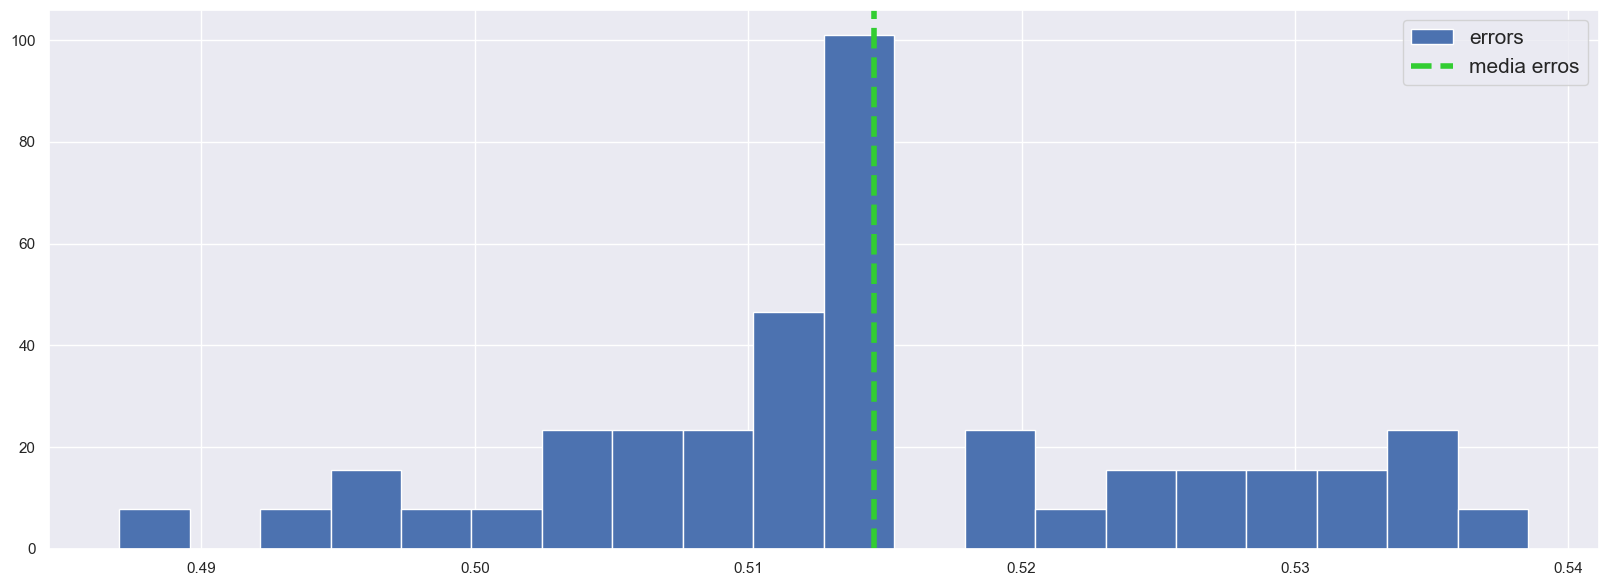

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## x.

In [ ]:
test_case='x'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


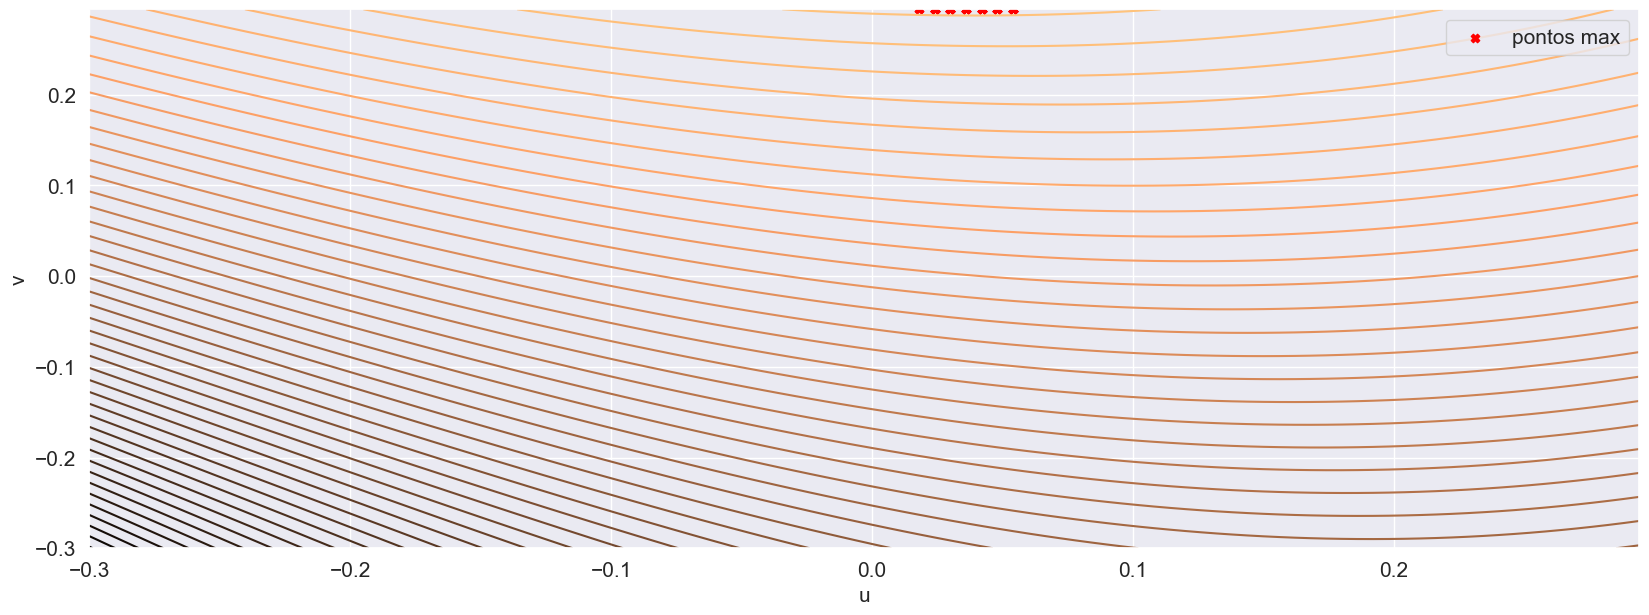

In [ ]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


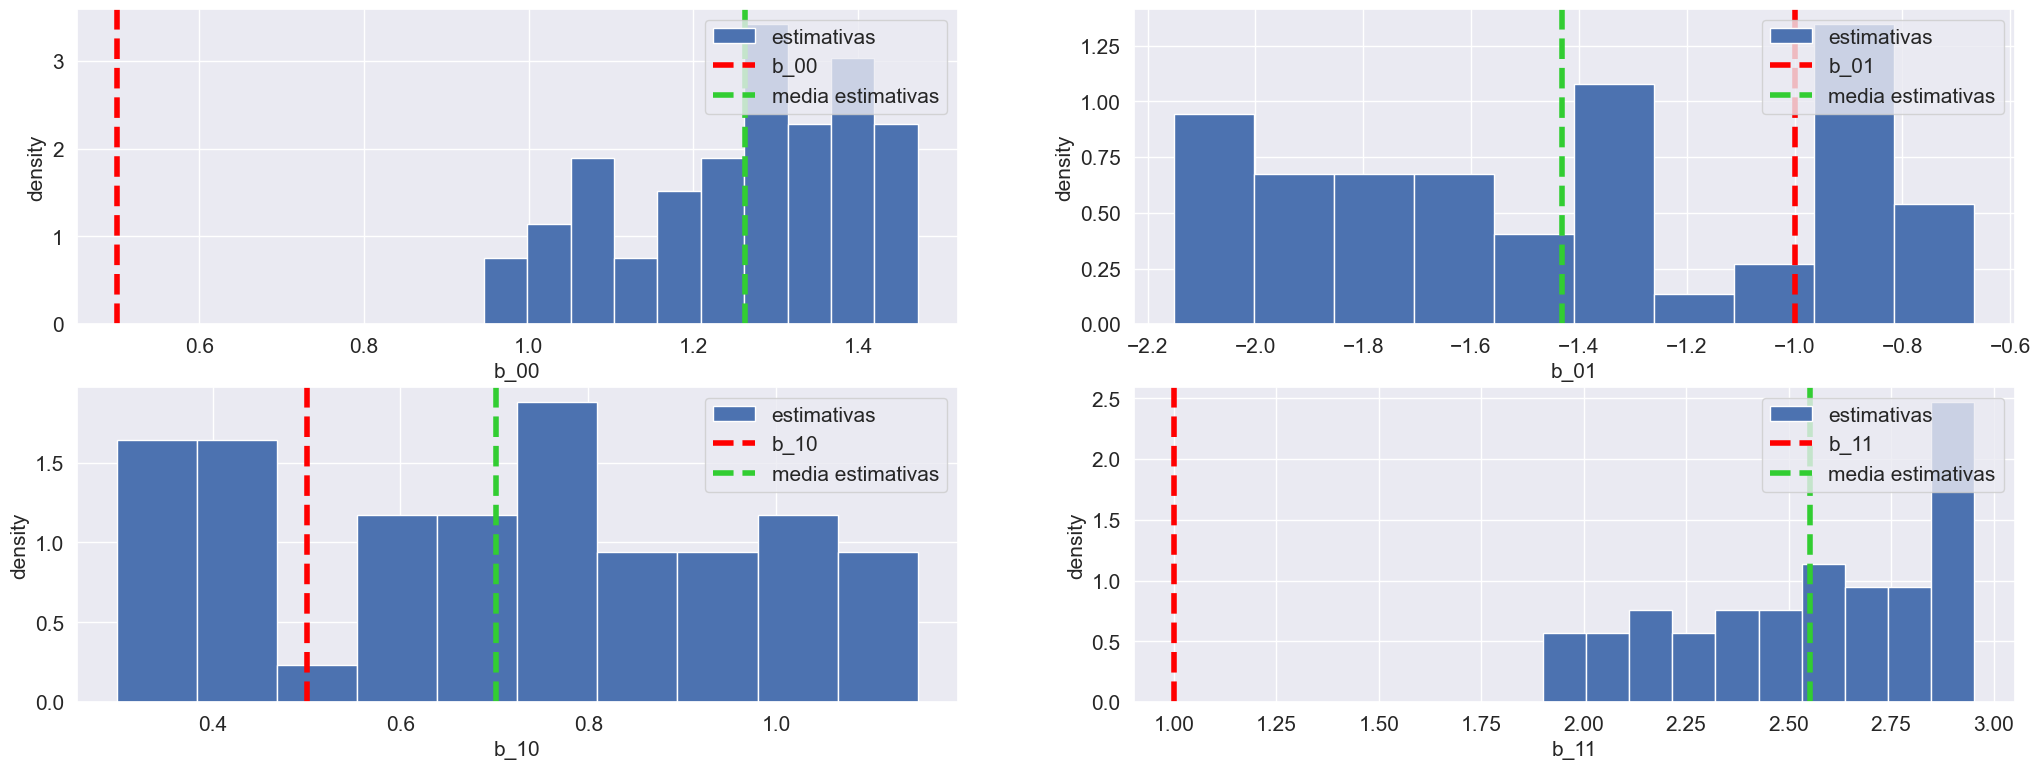

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 1.19
Max error: 1.38
Min error: 0.99
####################################################################################################


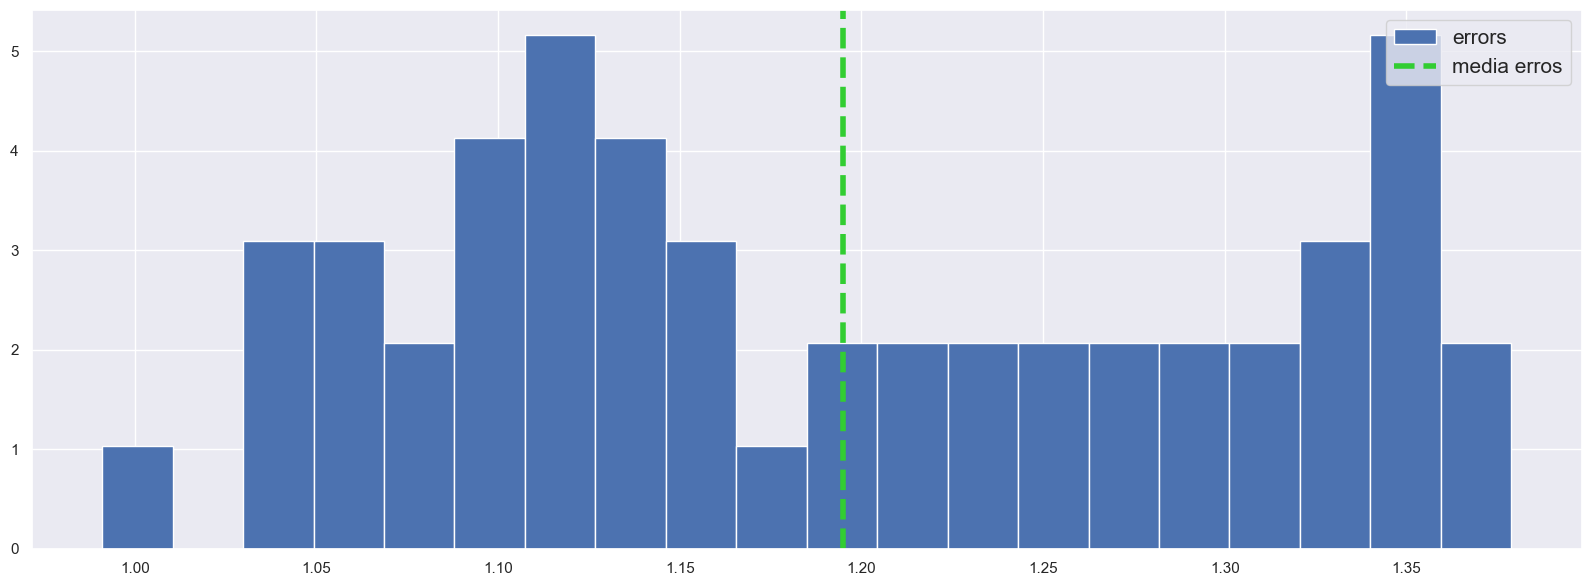

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


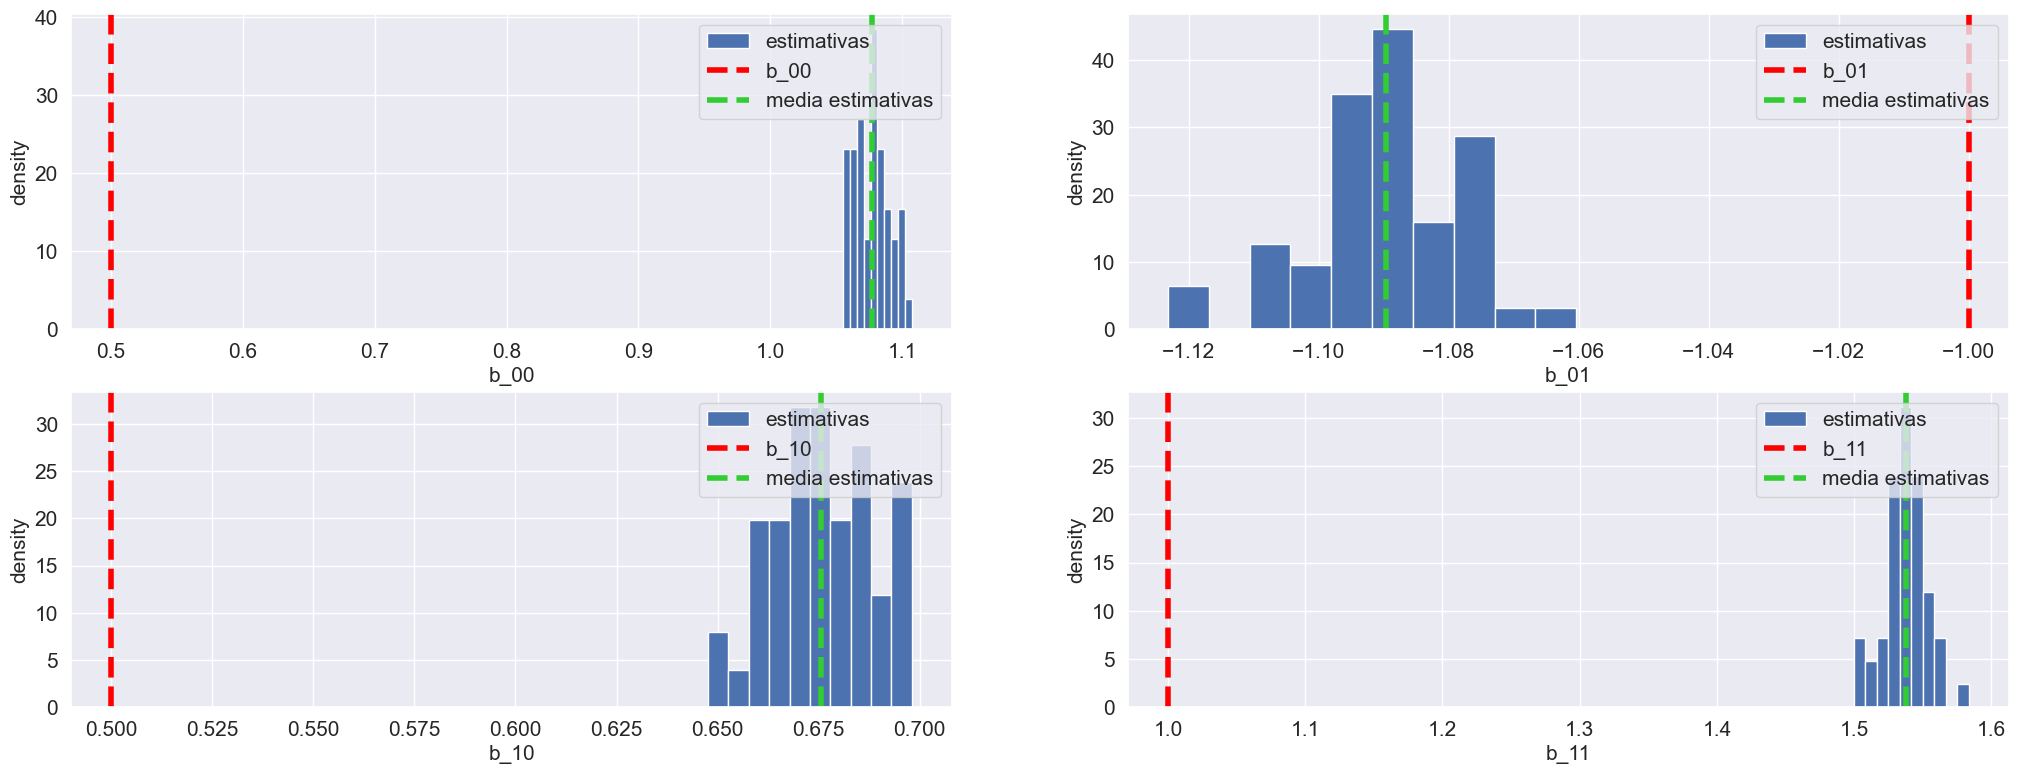

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.51
Max error: 0.54
Min error: 0.49
####################################################################################################


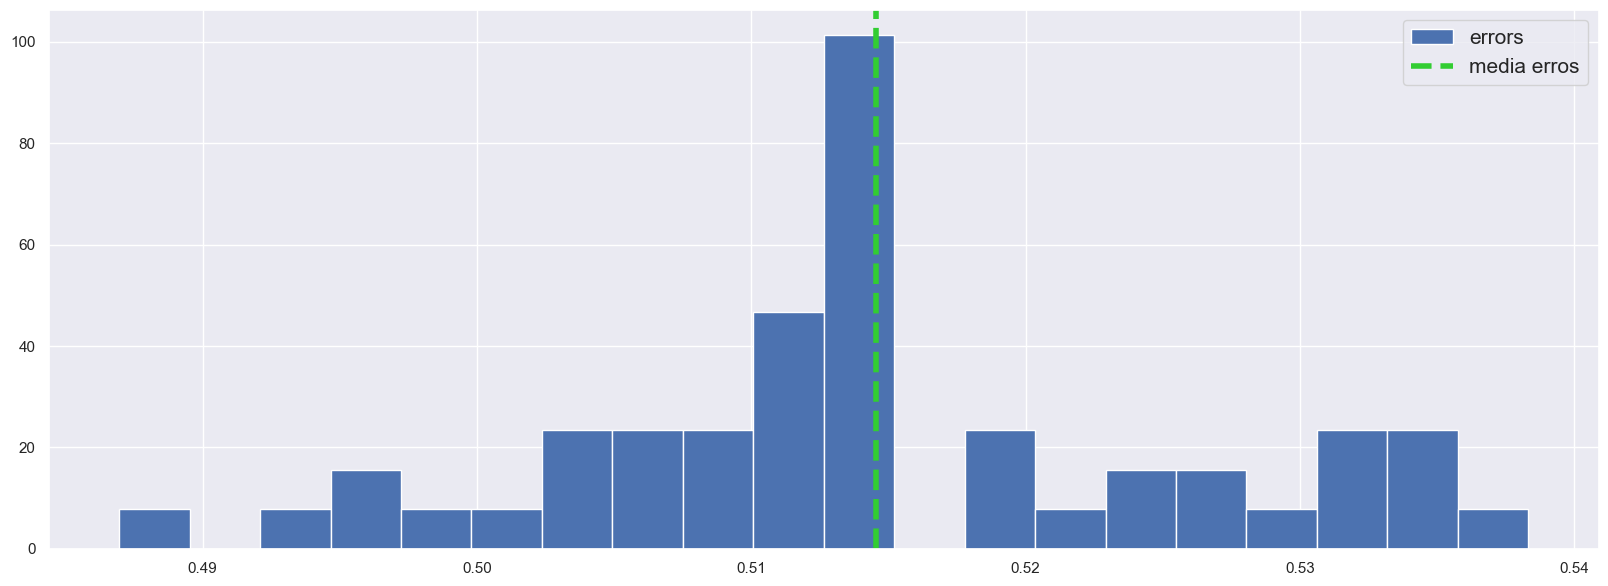

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## xi.

In [ ]:
test_case='xi'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


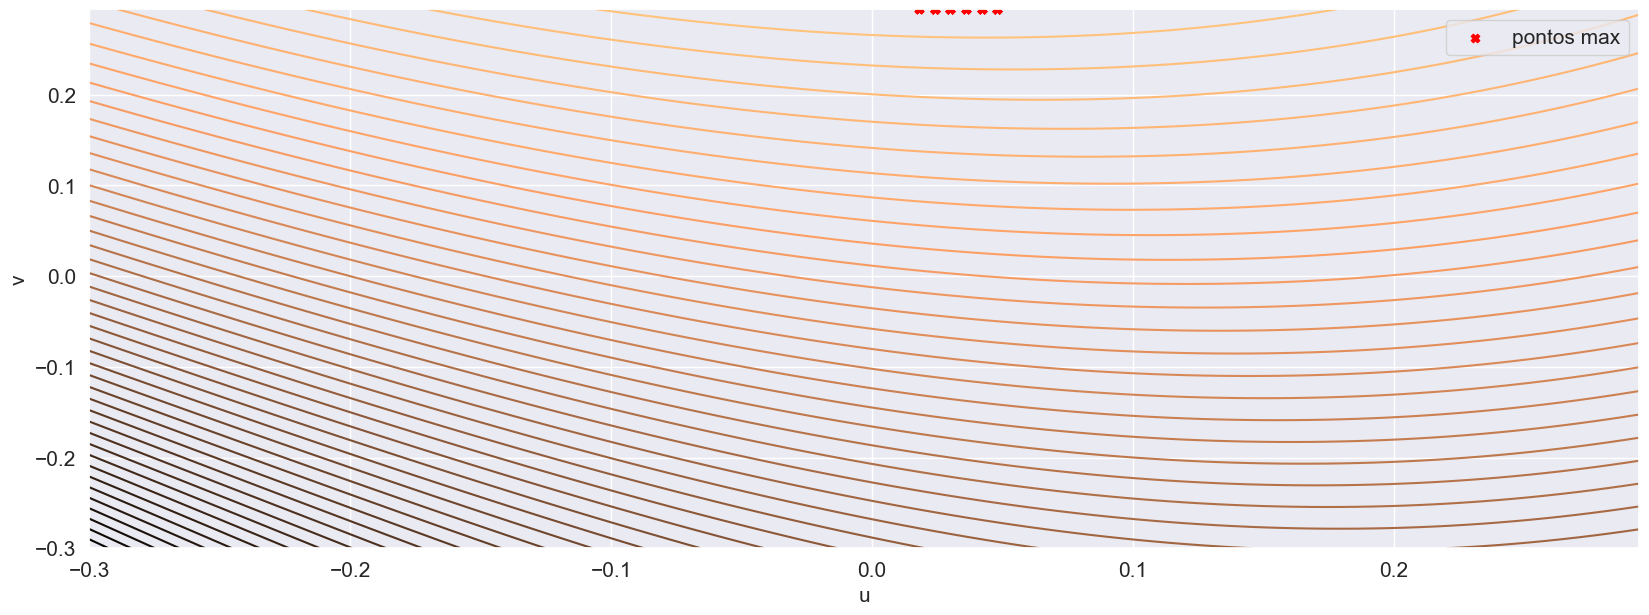

In [ ]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


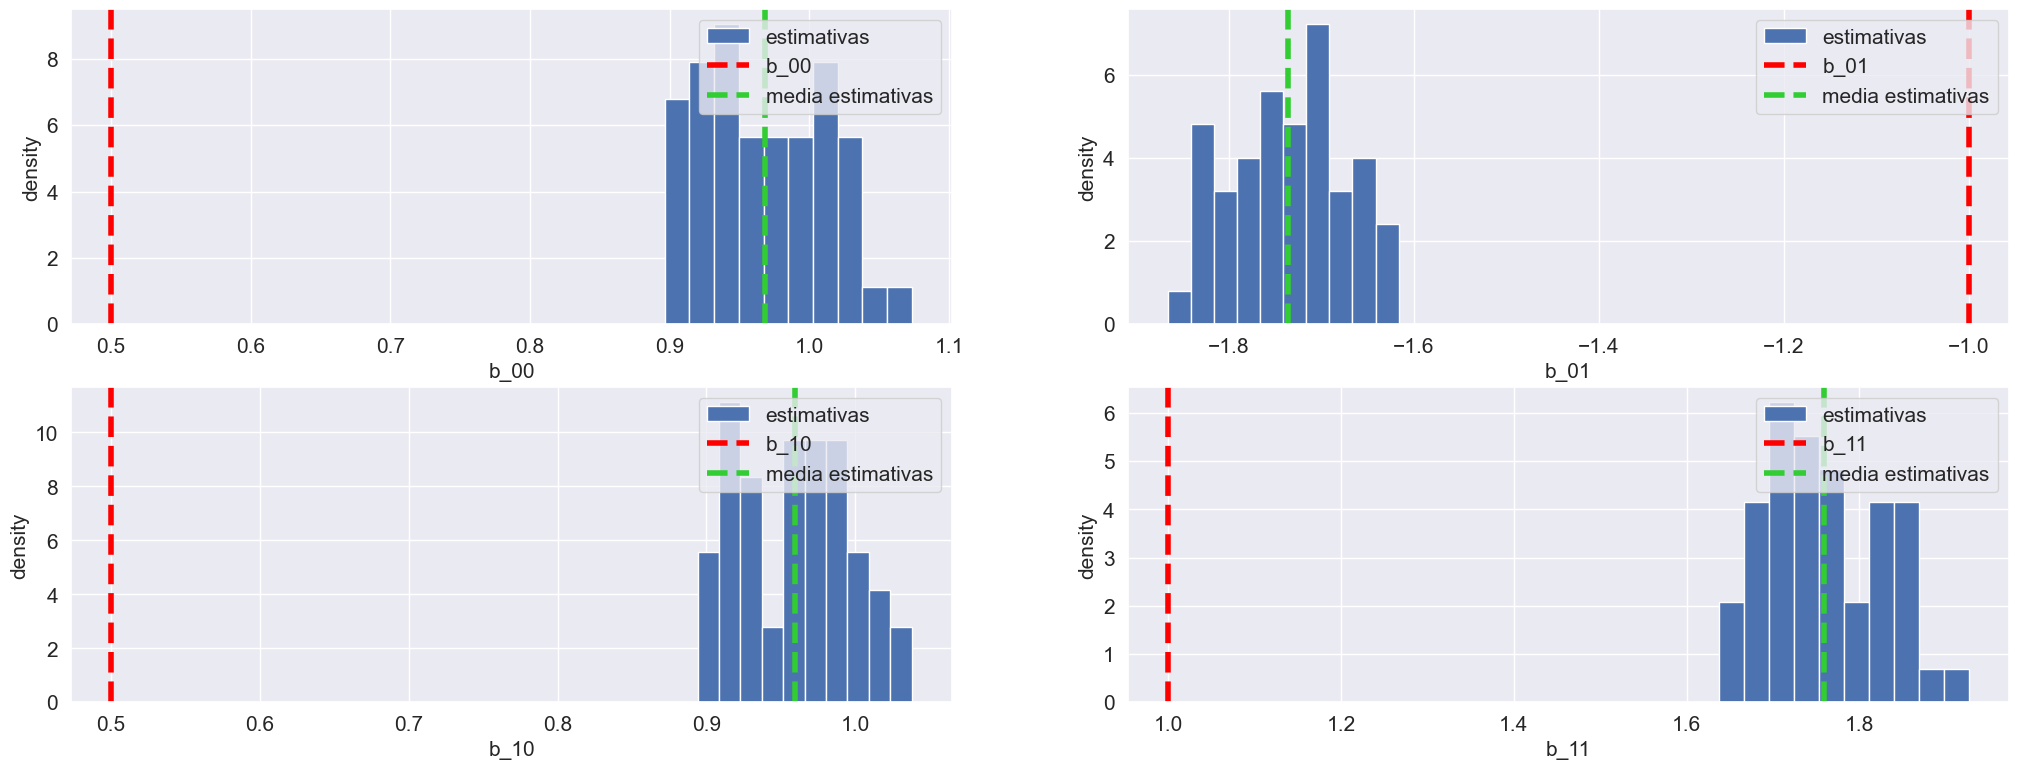

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.79
Max error: 0.85
Min error: 0.74
####################################################################################################


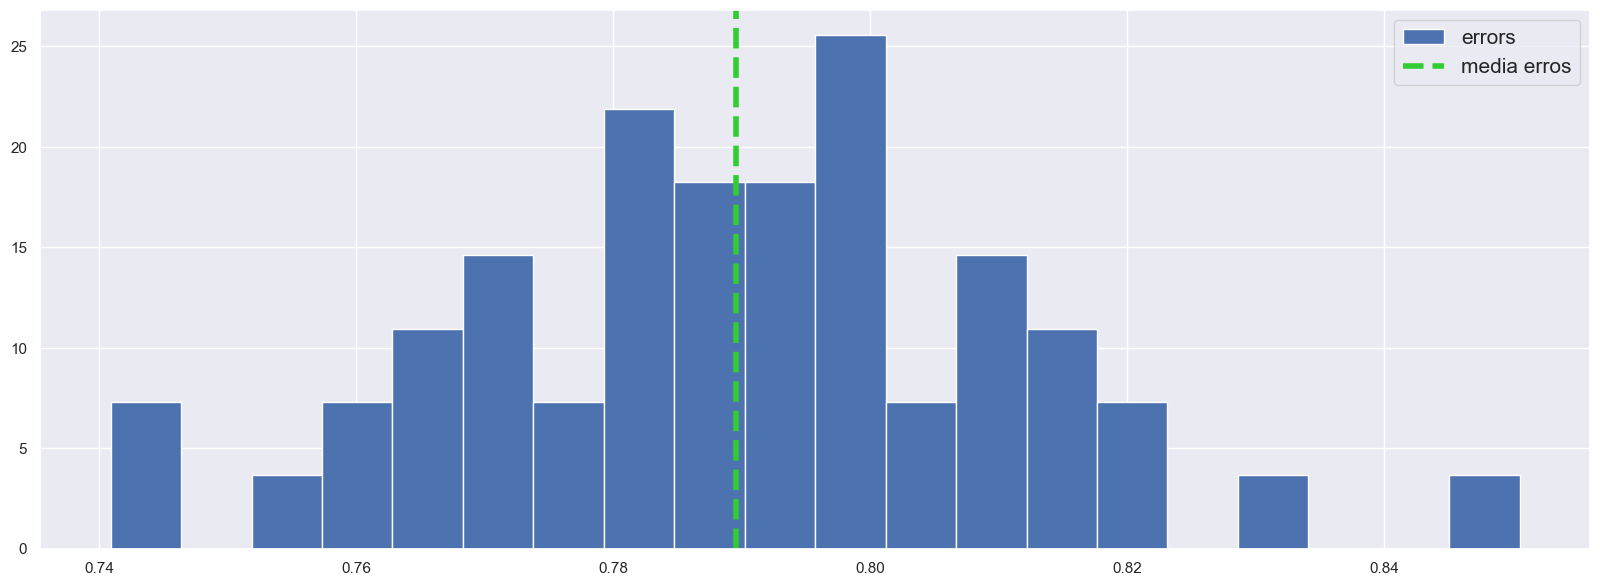

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


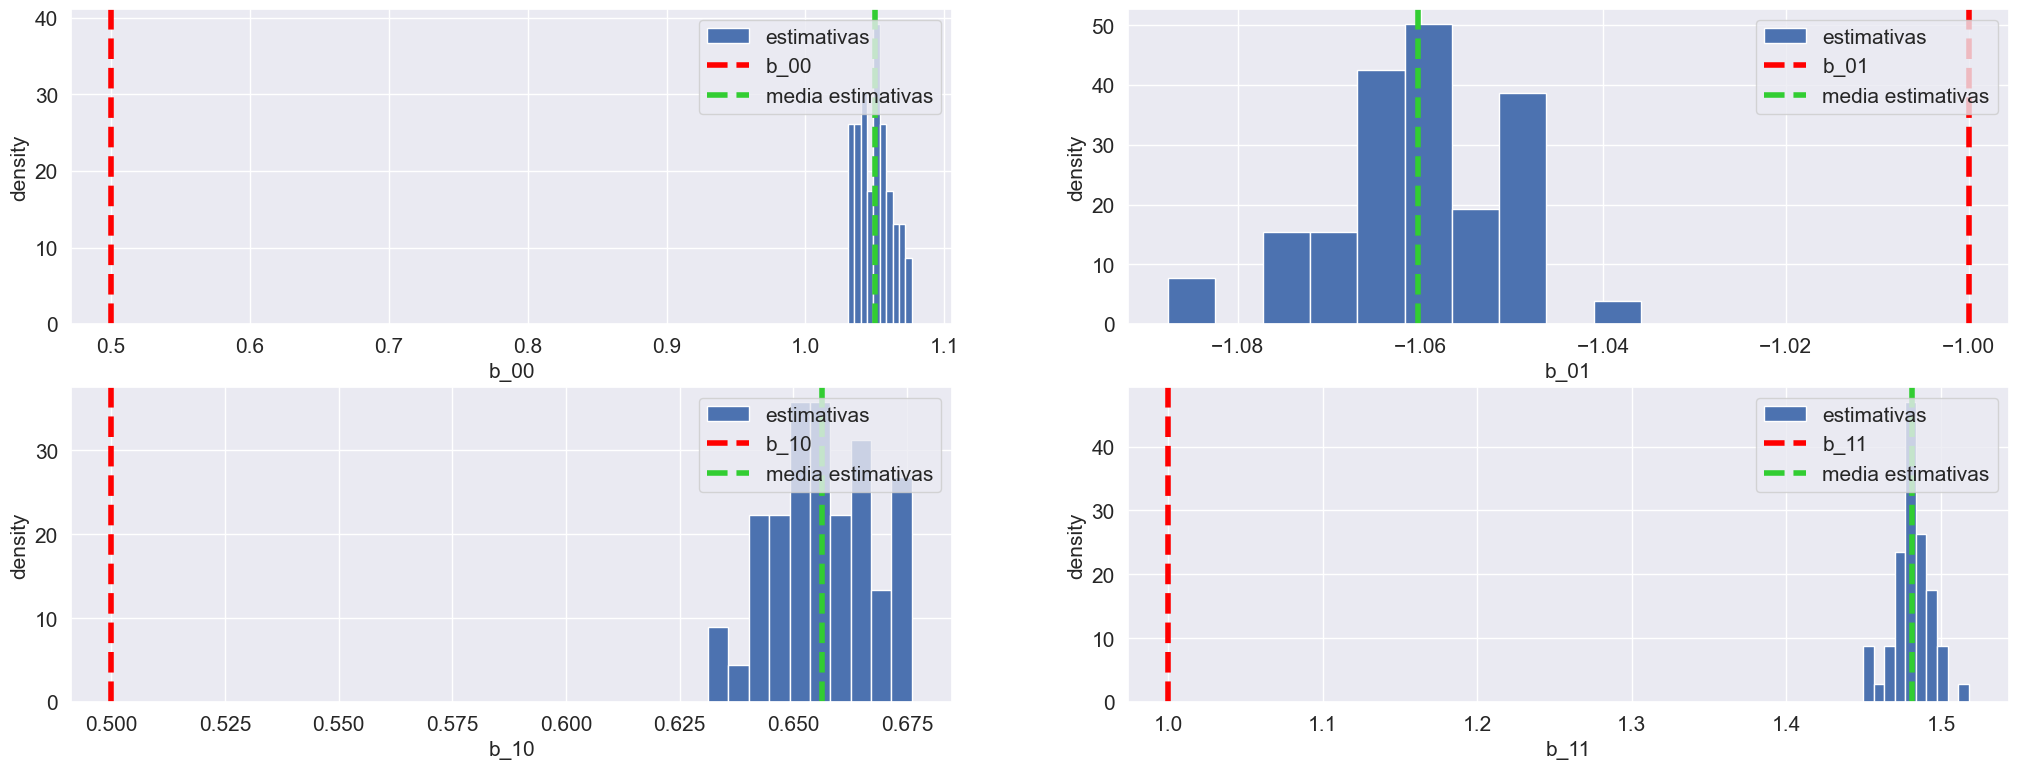

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.47
Max error: 0.49
Min error: 0.45
####################################################################################################


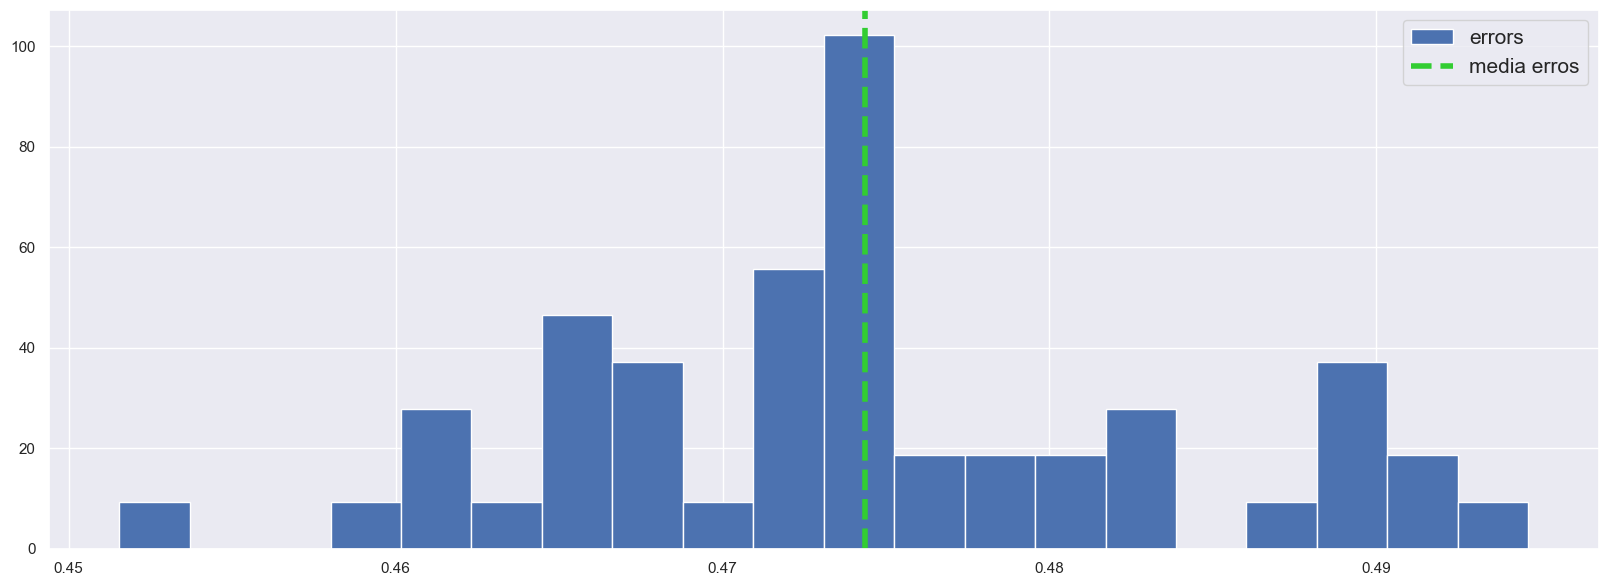

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## xii.

In [ ]:
test_case='xii'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


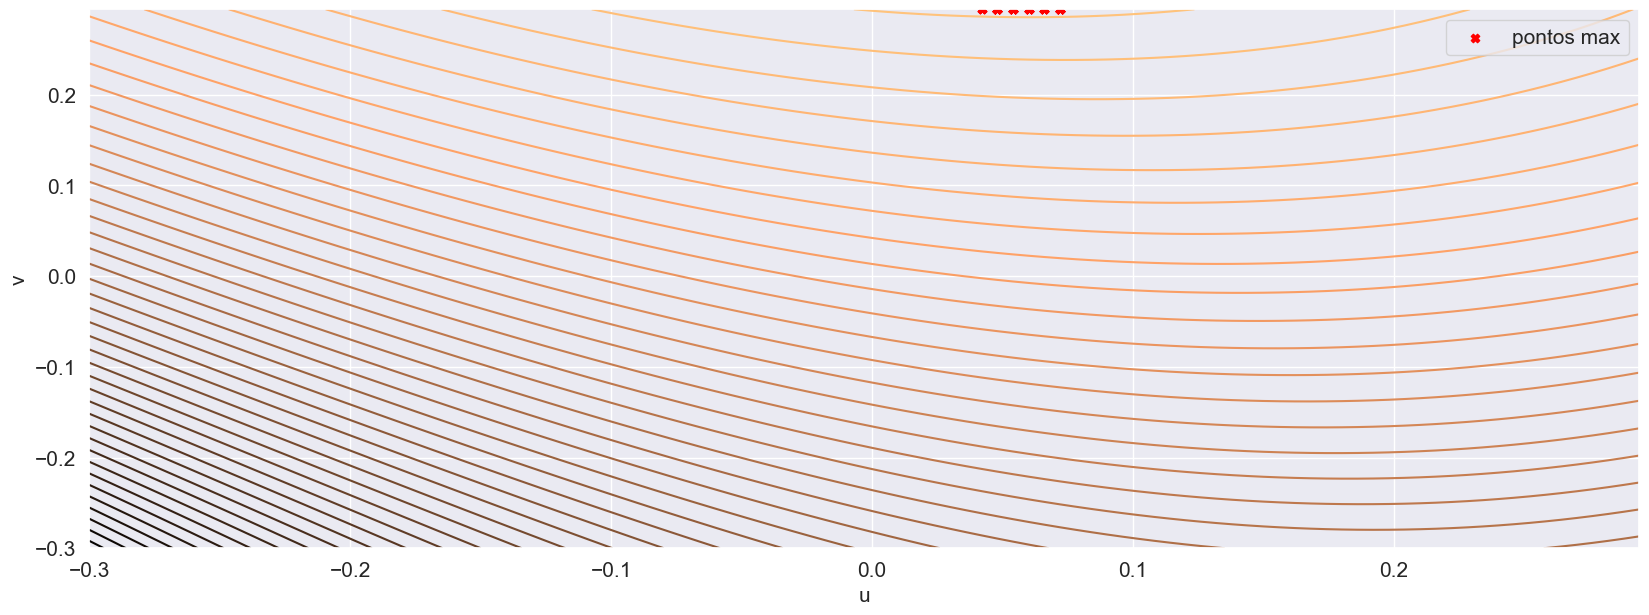

In [ ]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


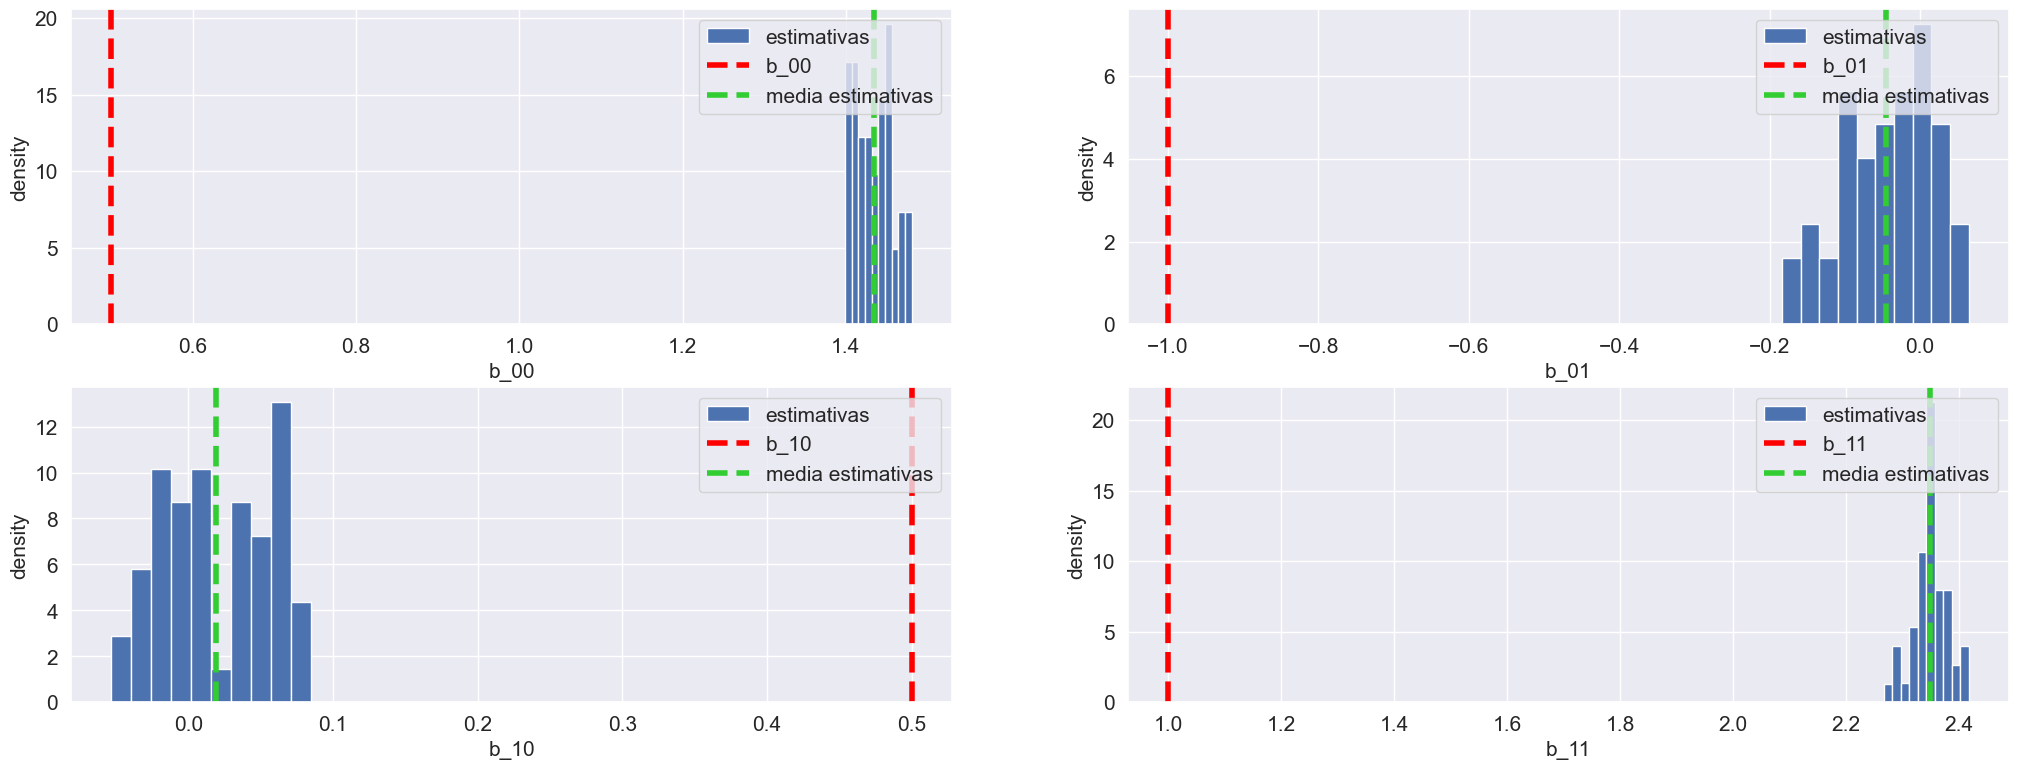

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 1.24
Max error: 1.29
Min error: 1.18
####################################################################################################


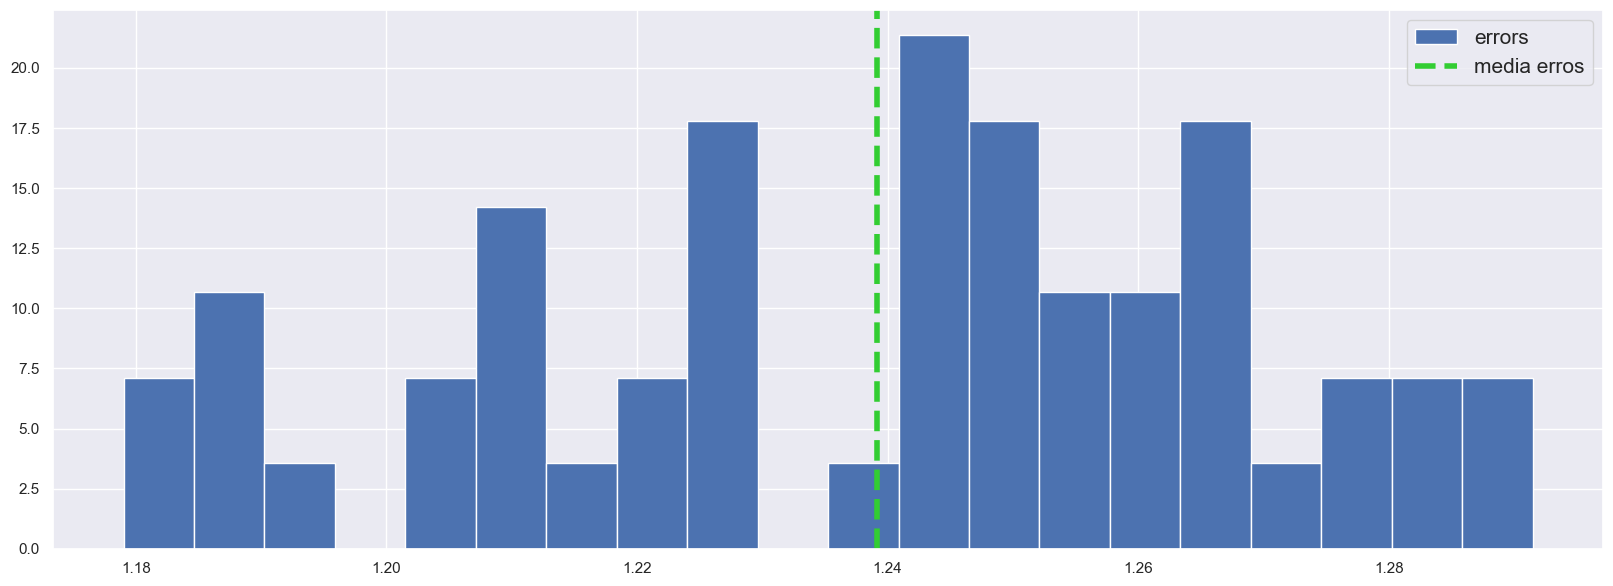

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


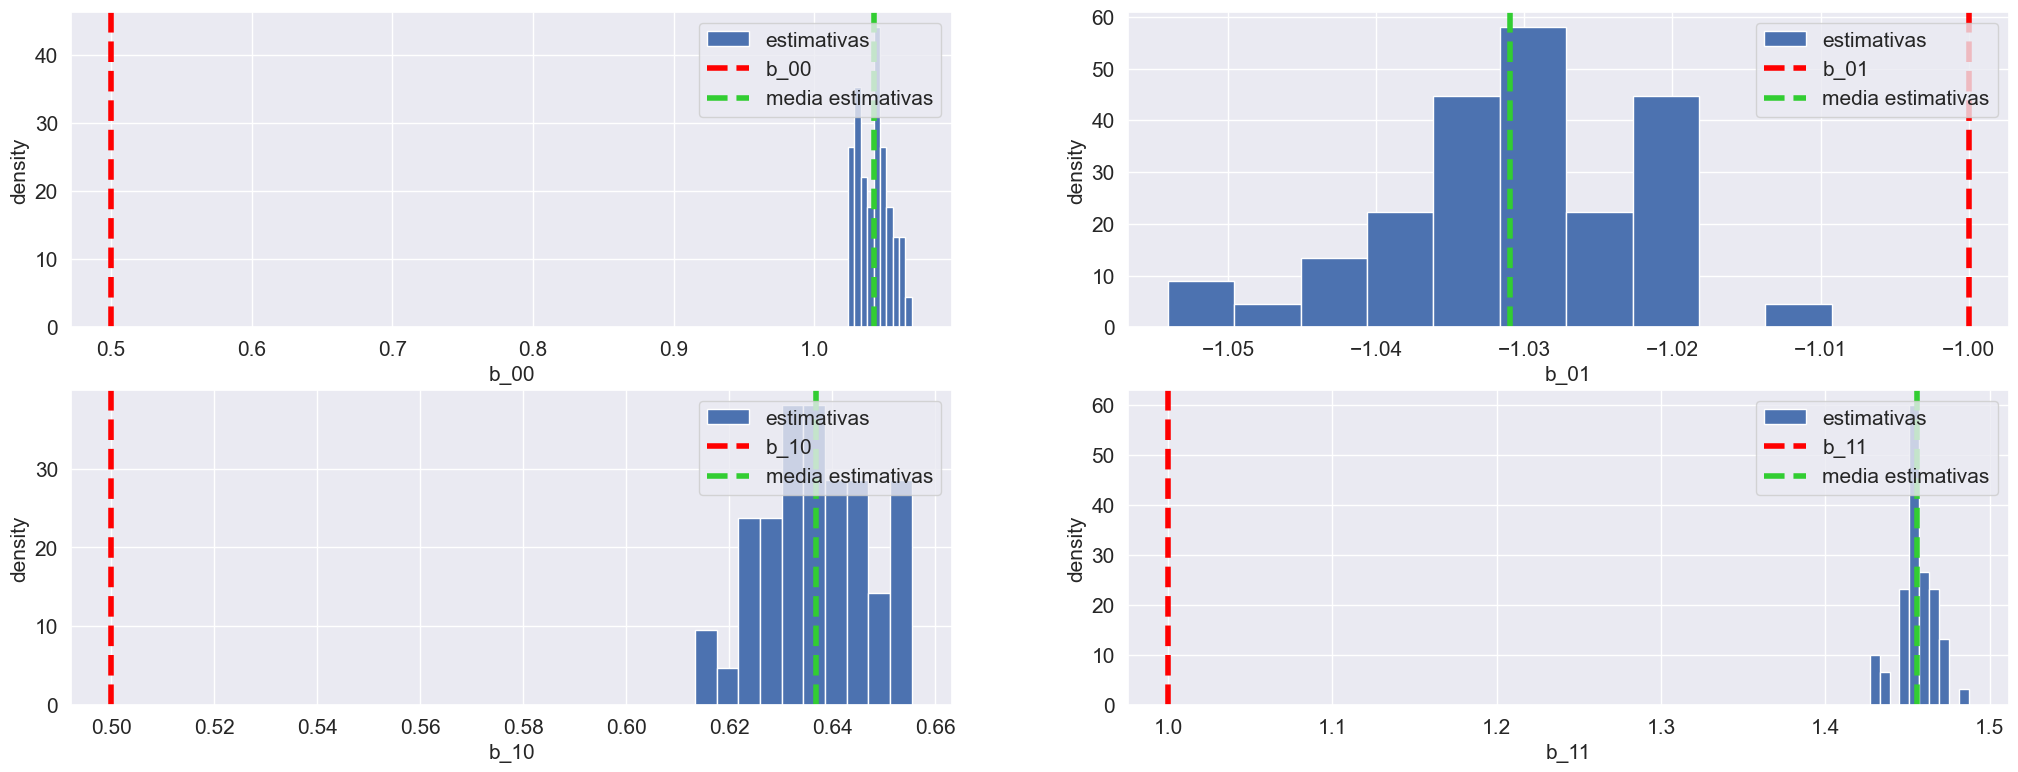

In [ ]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.46
Max error: 0.48
Min error: 0.44
####################################################################################################


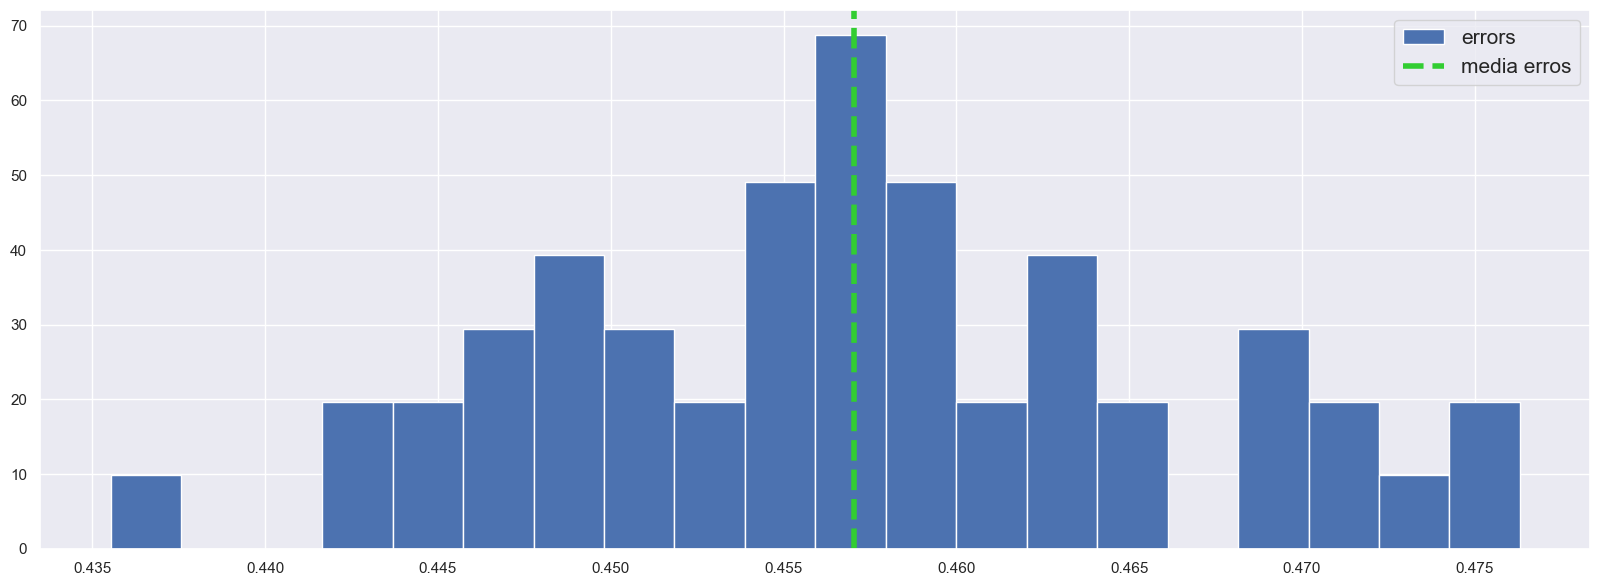

In [ ]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)